# Analyse des données orbitales d’Oxia Planum

## Étude géologique et implications pour l’exploration de Rosalind Franklin

### Question de recherche

Que peuvent révéler les données orbitales disponibles sur l’histoire
géologique et l’environnement d’Oxia Planum, et quelles caractéristiques
du terrain sont pertinentes pour l’exploration par le rover Rosalind Franklin ?

In [2]:
# Analyse des données orbitales d’Oxia Planum

## Étude géologique et implications pour l’exploration de Rosalind Franklin

### Question de recherche

Que peuvent révéler les données orbitales disponibles sur l’histoire
géologique et l’environnement d’Oxia Planum, et quelles caractéristiques
du terrain sont pertinentes pour l’exploration par le rover Rosalind Franklin ?


SyntaxError: invalid character '’' (U+2019) (2418017658.py, line 7)

# Analyse des données orbitales d’Oxia Planum

## Étude géologique et implications pour l’exploration de Rosalind Franklin

### Question de recherche

Que peuvent révéler les données orbitales disponibles sur l’histoire
géologique et l’environnement d’Oxia Planum, et quelles caractéristiques
du terrain sont pertinentes pour l’exploration par le rover Rosalind Franklin ?

## Objectifs du projet

Ce projet a pour objectif d’utiliser des données obtenues par observation
orbitale afin d’étudier différentes caractéristiques d’Oxia Planum.

Les principaux objectifs sont :

1. Étudier la topographie de la région à partir d’un modèle numérique de terrain.
2. Identifier et mesurer certaines caractéristiques du relief, notamment
   l’altitude, la pente et les variations du terrain.
3. Mettre ces observations en relation avec le contexte géologique d’Oxia Planum.
4. Examiner certaines contraintes que le relief peut représenter pour la
   mobilité et l’exploration d’un rover.
5. Relier les résultats scientifiques aux contraintes d’ingénierie de la mission
   Rosalind Franklin.
6. Évaluer les limites des données utilisées et l’incertitude des résultats.
   

## Données utilisées

Les données principales utilisées dans ce projet proviennent de l’archive
Planetary Science Archive (PSA) de l’Agence spatiale européenne (ESA).

Trois produits seront utilisés principalement :

- **CTX DEM, 20 m/pixel** : modèle numérique de terrain utilisé pour étudier
  l’altitude et la topographie d’Oxia Planum.
- **CTX ORI, 6 m/pixel** : image orthorectifiée utilisée pour observer le
  contexte morphologique et comparer les structures visibles avec la topographie.
- **CaSSIS sRGB, environ 4 m/pixel** : mosaïque en couleur obtenue par la caméra
  CaSSIS du Trace Gas Orbiter, utilisée pour observer les caractéristiques
  de surface avec une résolution plus élevée.

Le modèle numérique de terrain est particulièrement important pour l’analyse
quantitative, car chaque pixel contient une information d’altitude. Il pourra
être utilisé pour calculer ou visualiser des caractéristiques comme les
variations d’altitude et la pente.

Les images CTX et CaSSIS seront utilisées en complément du modèle de terrain.
Elles permettent de replacer les mesures topographiques dans leur contexte
visuel et géologique.

Les données ne seront pas considérées comme une représentation parfaite du
terrain. Leur résolution spatiale, leur méthode de production et les
incertitudes associées doivent être prises en compte lors de l’interprétation
des résultats.

## Produits de données principaux

| Produit | Résolution | Utilisation principale |
|---|---:|---|
| CTX DEM | 20 m/pixel | Altitude, pente et analyse topographique |
| CTX ORI | 6 m/pixel | Observation du relief et contexte morphologique |
| CaSSIS sRGB | ~4 m/pixel | Observation détaillée de la surface |

Les données proviennent de l’archive Planetary Science Archive (PSA) de
l’Agence spatiale européenne.

Les trois produits ne jouent pas le même rôle. Le DEM permet des mesures
quantitatives de la topographie, tandis que les images CTX et CaSSIS permettent
d’observer les structures de surface et de replacer les résultats
topographiques dans leur contexte.

Dans la suite du projet, les données originales seront conservées séparément
des données traitées. Les fichiers originaux ne seront pas modifiés.

In [3]:
from pathlib import Path

dossier_telechargements = Path.home() / "Downloads"

for fichier in dossier_telechargements.glob("*.tif"):
    print(fichier.name)

CTX_OXIA_DEM_20m.tif
CTX_OXIA_ORI_6m.tif


In [4]:
import rasterio
from pathlib import Path

chemin_dem = Path.home() / "Downloads" / "CTX_OXIA_DEM_20m.tif"

with rasterio.open(chemin_dem) as dem:
    print("Largeur :", dem.width, "pixels")
    print("Hauteur :", dem.height, "pixels")
    print("Nombre de bandes :", dem.count)
    print("Type de données :", dem.dtypes[0])
    print("Résolution :", dem.res)
    print("CRS :", dem.crs)
    print("Valeur NoData :", dem.nodata)

Largeur : 5935 pixels
Hauteur : 6018 pixels
Nombre de bandes : 1
Type de données : float32
Résolution : (20.234118238599976, 20.234118238599997)
CRS : PROJCS["Equirectangular_Mars_Oxia_Planum",GEOGCS["GCS_Mars_2000",DATUM["D_Mars_2000",SPHEROID["Mars_2000_IAU_IAG",3396190,169.894447223612]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",335.45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Valeur NoData : -3.4028230607370965e+38


In [5]:
import rasterio
import numpy as np
from pathlib import Path

chemin_dem = Path.home() / "Downloads" / "CTX_OXIA_DEM_20m.tif"

with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)

print("Nombre de pixels valides :", altitude.count())
print("Altitude minimale :", altitude.min(), "m")
print("Altitude maximale :", altitude.max(), "m")
print("Altitude moyenne :", altitude.mean(), "m")
print("Altitude médiane :", np.ma.median(altitude), "m")
print("Écart-type :", altitude.std(), "m")

Nombre de pixels valides : 21274732
Altitude minimale : -3239.9937 m
Altitude maximale : -2403.8706 m
Altitude moyenne : -2980.738430171529 m
Altitude médiane : -3018.2026 m
Écart-type : 124.28915638645282 m


## Première visualisation de la topographie

Le modèle numérique de terrain contient une valeur d'altitude pour chaque
pixel valide. Une première étape consiste à visualiser spatialement ces
valeurs afin d'observer la répartition des altitudes dans la région étudiée.

Cette représentation permet de passer d'une série de valeurs numériques à
une carte de la topographie d'Oxia Planum.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(altitude, cmap="terrain")

plt.colorbar(label="Altitude (m)")
plt.title("Topographie d'Oxia Planum")
plt.xlabel("Position horizontale (pixels)")
plt.ylabel("Position verticale (pixels)")

plt.show()

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(altitude, cmap="terrain")

plt.colorbar(label="Altitude (m)")
plt.title("Topographie d'Oxia Planum")
plt.xlabel("Position horizontale (pixels)")
plt.ylabel("Position verticale (pixels)")

plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(altitude, cmap="terrain")

plt.colorbar(label="Altitude (m)")
plt.title("Topographie d'Oxia Planum")
plt.xlabel("Position horizontale (pixels)")
plt.ylabel("Position verticale (pixels)")

plt.show()

NameError: name 'altitude' is not defined

<Figure size 1000x800 with 0 Axes>

In [2]:
print(type(altitude))
print(altitude.shape)

NameError: name 'altitude' is not defined

In [3]:
import rasterio
from pathlib import Path

chemin_dem = Path.home() / "Downloads" / "CTX_OXIA_DEM_20m.tif"

with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)

In [4]:
print(type(altitude))
print(altitude.shape)

<class 'numpy.ma.MaskedArray'>
(6018, 5935)


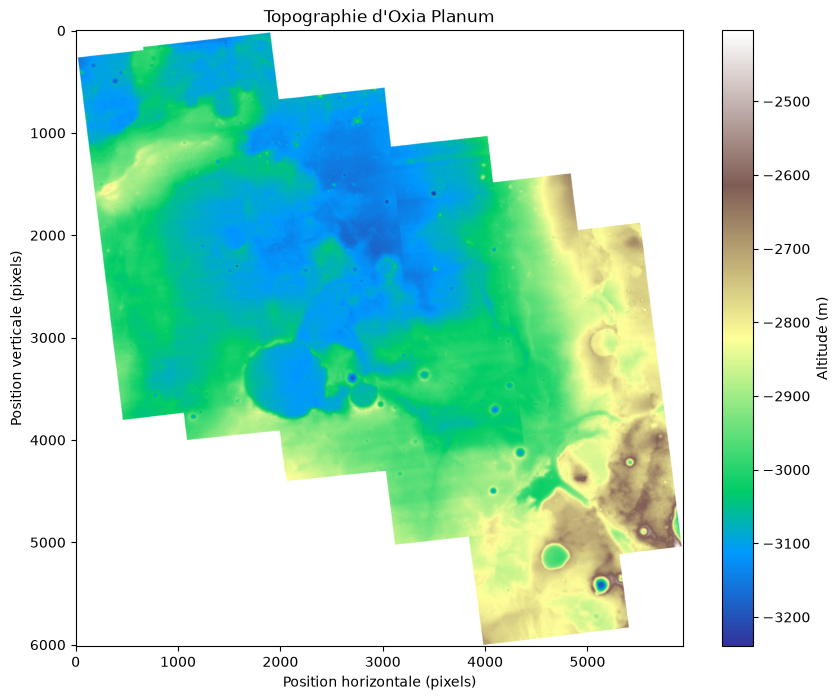

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(altitude, cmap="terrain")

plt.colorbar(label="Altitude (m)")
plt.title("Topographie d'Oxia Planum")
plt.xlabel("Position horizontale (pixels)")
plt.ylabel("Position verticale (pixels)")

plt.show()




## Carte topographique géoréférencée

La première visualisation permettait d'observer la distribution des altitudes,
mais ses axes étaient exprimés en pixels.

Le modèle numérique de terrain possède cependant des informations de
géoréférencement permettant de relier chaque pixel à une position dans le
système de coordonnées utilisé pour Oxia Planum.

Cette représentation utilise donc les coordonnées spatiales du DEM plutôt que
les indices des pixels.








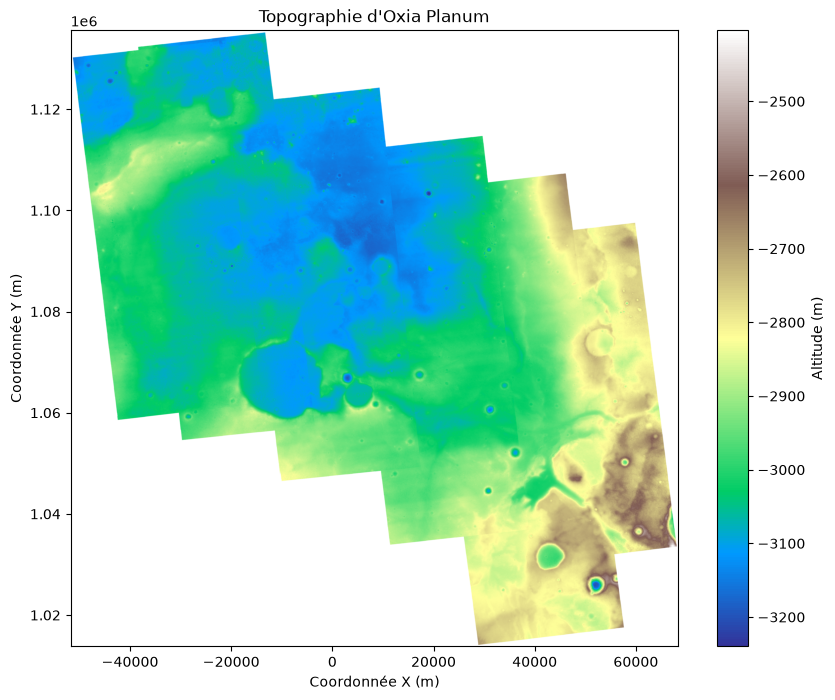

In [6]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent

chemin_dem = Path.home() / "Downloads" / "CTX_OXIA_DEM_20m.tif"

with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)
    emprise = plotting_extent(dem)

plt.figure(figsize=(10, 8))

plt.imshow(
    altitude,
    extent=emprise,
    cmap="terrain"
)

plt.colorbar(label="Altitude (m)")
plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("Topographie d'Oxia Planum")

plt.show()

## Calcul de la pente

La pente décrit la variation de l'altitude par rapport à la distance horizontale.

À partir du modèle numérique de terrain, la pente est calculée en étudiant
les variations d'altitude entre les pixels voisins et en tenant compte de
la résolution spatiale du DEM.

Le résultat est exprimé en degrés :

- 0° correspond à une surface horizontale ;
- une valeur plus élevée correspond à une surface plus inclinée.

Cette information sera utilisée plus tard pour étudier les contraintes
potentielles liées à la mobilité du rover.

In [7]:
import numpy as np
import rasterio

chemin_dem = Path.home() / "Downloads" / "CTX_OXIA_DEM_20m.tif"

with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)
    resolution_x, resolution_y = dem.res

# Calcul des variations d'altitude
gradient_y, gradient_x = np.gradient(
    altitude.filled(np.nan),
    resolution_y,
    resolution_x
)

# Calcul de la pente
pente = np.degrees(
    np.arctan(
        np.sqrt(gradient_x**2 + gradient_y**2)
    )
)

pente = np.ma.masked_invalid(pente)

print("Pente minimale :", pente.min(), "°")
print("Pente maximale :", pente.max(), "°")
print("Pente moyenne :", pente.mean(), "°")
print("Pente médiane :", np.ma.median(pente), "°")

Pente minimale : 0.0 °
Pente maximale : 65.96161 °
Pente moyenne : 2.6652313145423796 °
Pente médiane : 1.9694737 °


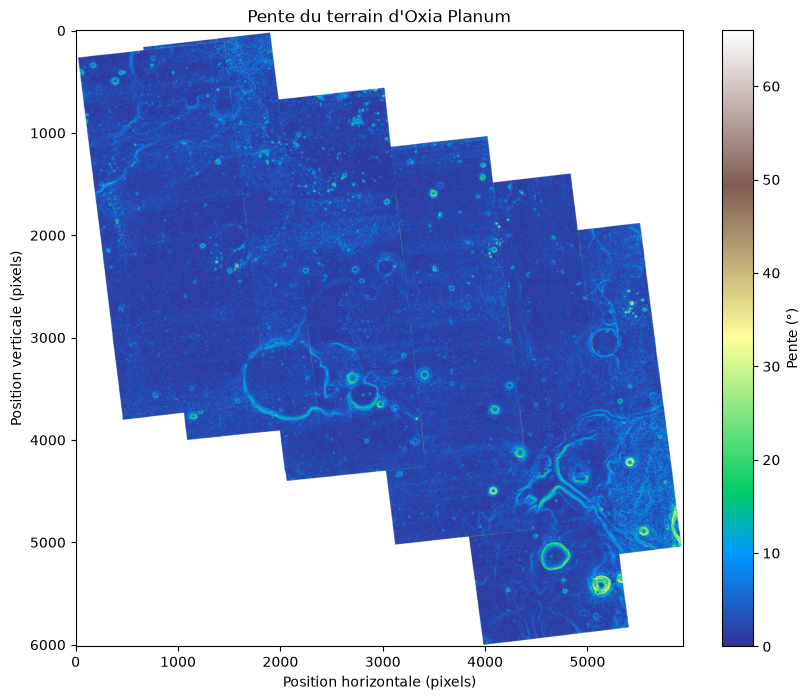

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(pente, cmap="terrain")

plt.colorbar(label="Pente (°)")
plt.title("Pente du terrain d'Oxia Planum")
plt.xlabel("Position horizontale (pixels)")
plt.ylabel("Position verticale (pixels)")

plt.show()

In [9]:
# Résumé statistique de la pente

valeurs_pente = pente.compressed()

print("Nombre de pixels analysés :", len(valeurs_pente))
print("Pente minimale :", np.min(valeurs_pente), "°")
print("Pente maximale :", np.max(valeurs_pente), "°")
print("Pente moyenne :", np.mean(valeurs_pente), "°")
print("Pente médiane :", np.median(valeurs_pente), "°")

print("\nPourcentage de pixels selon la pente :")

for limite in [1, 2, 5, 10, 15, 20, 30, 45, 60]:
    pourcentage = np.mean(valeurs_pente >= limite) * 100
    print(f"Pente ≥ {limite:2d}° : {pourcentage:.3f} %")

Nombre de pixels analysés : 21251928
Pente minimale : 0.0 °
Pente maximale : 65.96161 °
Pente moyenne : 2.6652315 °
Pente médiane : 1.9694737 °

Pourcentage de pixels selon la pente :
Pente ≥  1° : 80.899 %
Pente ≥  2° : 49.143 %
Pente ≥  5° : 10.311 %
Pente ≥ 10° : 2.281 %
Pente ≥ 15° : 0.859 %
Pente ≥ 20° : 0.389 %
Pente ≥ 30° : 0.068 %
Pente ≥ 45° : 0.003 %
Pente ≥ 60° : 0.000 %


In [10]:
# Surface représentée par un pixel du DEM
surface_pixel_m2 = resolution_x * resolution_y

print("Surface d'un pixel :", surface_pixel_m2, "m²")
print()

for limite in [10, 20, 30, 45, 60]:
    masque = valeurs_pente >= limite
    nombre = np.count_nonzero(masque)
    surface_km2 = nombre * surface_pixel_m2 / 1_000_000

    print(
        f"Pente ≥ {limite:2d}° : "
        f"{nombre:,} pixels | "
        f"{surface_km2:.4f} km²"
    )

Surface d'un pixel : 409.41954089364464 m²

Pente ≥ 10° : 484,722 pixels | 198.4547 km²
Pente ≥ 20° : 82,734 pixels | 33.8729 km²
Pente ≥ 30° : 14,355 pixels | 5.8772 km²
Pente ≥ 45° : 625 pixels | 0.2559 km²
Pente ≥ 60° : 8 pixels | 0.0033 km²


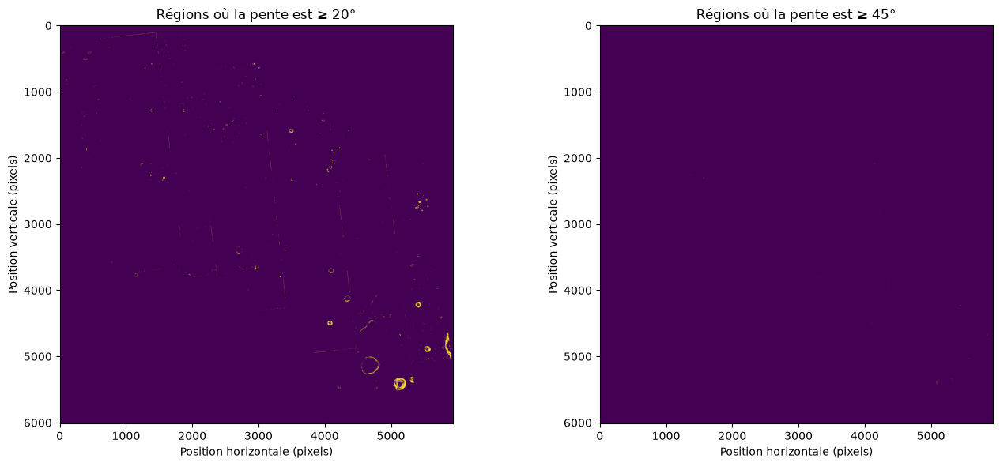

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# On transforme la pente en tableau classique
pente_array = pente.filled(np.nan)

# Création des masques
pente_20 = pente_array >= 20
pente_45 = pente_array >= 45

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(pente_20)
axes[0].set_title("Régions où la pente est ≥ 20°")
axes[0].set_xlabel("Position horizontale (pixels)")
axes[0].set_ylabel("Position verticale (pixels)")

axes[1].imshow(pente_45)
axes[1].set_title("Régions où la pente est ≥ 45°")
axes[1].set_xlabel("Position horizontale (pixels)")
axes[1].set_ylabel("Position verticale (pixels)")

plt.tight_layout()
plt.show()

In [12]:
print("=== Analyse de la distribution des pentes ===")
print()

print(f"Nombre total de pixels analysés : {len(valeurs_pente):,}")
print(f"Surface représentée par un pixel : {surface_pixel_m2:.2f} m²")
print()

for limite in [10, 20, 30, 45, 60]:
    masque = valeurs_pente >= limite
    nombre = np.count_nonzero(masque)
    surface_km2 = nombre * surface_pixel_m2 / 1_000_000
    pourcentage = nombre / len(valeurs_pente) * 100

    print(
        f"Pente ≥ {limite}° : "
        f"{nombre:,} pixels | "
        f"{surface_km2:.4f} km² | "
        f"{pourcentage:.4f} % des pixels"
    )
    

=== Analyse de la distribution des pentes ===

Nombre total de pixels analysés : 21,251,928
Surface représentée par un pixel : 409.42 m²

Pente ≥ 10° : 484,722 pixels | 198.4547 km² | 2.2808 % des pixels
Pente ≥ 20° : 82,734 pixels | 33.8729 km² | 0.3893 % des pixels
Pente ≥ 30° : 14,355 pixels | 5.8772 km² | 0.0675 % des pixels
Pente ≥ 45° : 625 pixels | 0.2559 km² | 0.0029 % des pixels
Pente ≥ 60° : 8 pixels | 0.0033 km² | 0.0000 % des pixels


In [13]:





# Localisation des pentes les plus fortes

pente_array = pente.filled(np.nan)

for limite in [20, 45, 60]:
    lignes, colonnes = np.where(pente_array >= limite)

    print(f"\n=== Pente ≥ {limite}° ===")
    print(f"Nombre de pixels : {len(lignes)}")

    if len(lignes) > 0:
        print("Premiers pixels trouvés :")

        for ligne, colonne in zip(lignes[:10], colonnes[:10]):
            x, y = dem.xy(ligne, colonne)
            valeur = pente_array[ligne, colonne]

            print(
                f"Pixel ({ligne}, {colonne}) | "
                f"Coordonnées : X = {x:.2f} m, Y = {y:.2f} m | "
                f"Pente = {valeur:.2f}°"
            )


=== Pente ≥ 20° ===
Nombre de pixels : 82734
Premiers pixels trouvés :
Pixel (84, 1535) | Coordonnées : X = -20669.06 m, Y = 1133848.22 m | Pente = 20.64°
Pixel (85, 1535) | Coordonnées : X = -20669.06 m, Y = 1133827.98 m | Pente = 20.70°
Pixel (85, 1536) | Coordonnées : X = -20648.83 m, Y = 1133827.98 m | Pente = 20.73°
Pixel (86, 1536) | Coordonnées : X = -20648.83 m, Y = 1133807.75 m | Pente = 20.90°
Pixel (96, 1560) | Coordonnées : X = -20163.21 m, Y = 1133605.41 m | Pente = 20.69°
Pixel (98, 1528) | Coordonnées : X = -20810.70 m, Y = 1133564.94 m | Pente = 21.42°
Pixel (98, 1529) | Coordonnées : X = -20790.47 m, Y = 1133564.94 m | Pente = 20.84°
Pixel (99, 1527) | Coordonnées : X = -20830.93 m, Y = 1133544.70 m | Pente = 20.88°
Pixel (103, 1439) | Coordonnées : X = -22611.54 m, Y = 1133463.77 m | Pente = 20.29°
Pixel (103, 1440) | Coordonnées : X = -22591.30 m, Y = 1133463.77 m | Pente = 22.07°

=== Pente ≥ 45° ===
Nombre de pixels : 625
Premiers pixels trouvés :
Pixel (113, 1353

In [14]:
import rasterio
import numpy as np

# Localisation du pixel de pente maximale
ligne_max, colonne_max = np.unravel_index(
    np.nanargmax(pente_array),
    pente_array.shape
)

with rasterio.open(chemin_dem) as dem:
    # Coordonnées du pixel de pente maximale
    x_max, y_max = dem.xy(ligne_max, colonne_max)

    # Petite fenêtre autour du pixel
    rayon = 5

    ligne_min = max(0, ligne_max - rayon)
    ligne_max_f = min(dem.height, ligne_max + rayon + 1)
    colonne_min = max(0, colonne_max - rayon)
    colonne_max_f = min(dem.width, colonne_max + rayon + 1)

    altitude_locale = dem.read(
        1,
        window=rasterio.windows.Window(
            colonne_min,
            ligne_min,
            colonne_max_f - colonne_min,
            ligne_max_f - ligne_min
        ),
        masked=True
    )

pente_locale = pente_array[
    ligne_min:ligne_max_f,
    colonne_min:colonne_max_f
]

print("=== Pixel de pente maximale ===")
print(f"Position pixel : ({ligne_max}, {colonne_max})")
print(f"Coordonnées X : {x_max:.2f} m")
print(f"Coordonnées Y : {y_max:.2f} m")
print(f"Pente maximale : {pente_array[ligne_max, colonne_max]:.2f}°")

print("\n=== Terrain autour du pixel ===")
print(f"Altitude minimale locale : {np.nanmin(altitude_locale):.2f} m")
print(f"Altitude maximale locale : {np.nanmax(altitude_locale):.2f} m")
print(f"Variation locale d'altitude : "
      f"{np.nanmax(altitude_locale) - np.nanmin(altitude_locale):.2f} m")

print(f"Pente minimale locale : {np.nanmin(pente_locale):.2f}°")
print(f"Pente maximale locale : {np.nanmax(pente_locale):.2f}°")
print(f"Pente moyenne locale : {np.nanmean(pente_locale):.2f}°")

=== Pixel de pente maximale ===
Position pixel : (4230, 5447)
Coordonnées X : 58486.81 m
Coordonnées Y : 1049957.56 m
Pente maximale : 65.96°

=== Terrain autour du pixel ===
Altitude minimale locale : -2822.09 m
Altitude maximale locale : -2633.79 m
Variation locale d'altitude : 188.29 m
Pente minimale locale : 5.71°
Pente maximale locale : 65.96°
Pente moyenne locale : 35.46°


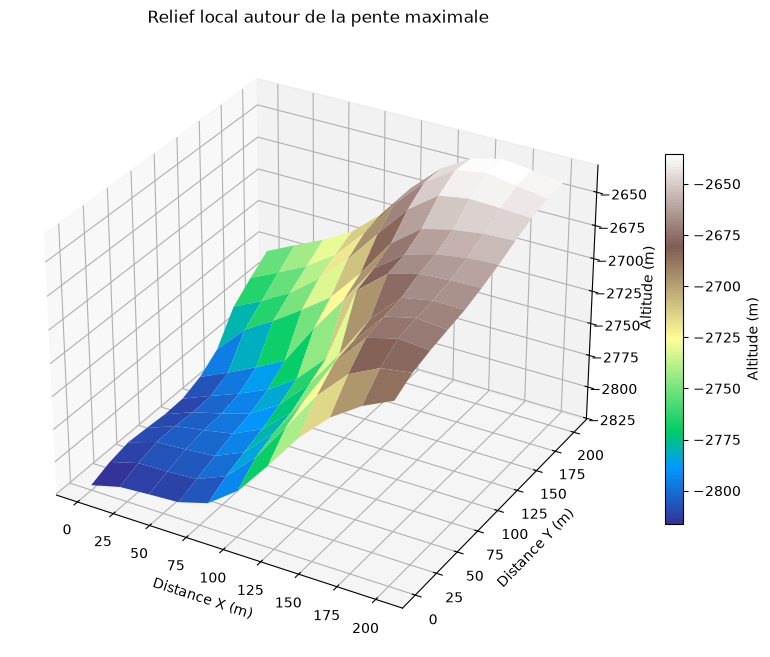

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import rasterio
import numpy as np

with rasterio.open(chemin_dem) as dem:
    rayon = 5

    ligne_min = max(0, ligne_max - rayon)
    ligne_max_f = min(dem.height, ligne_max + rayon + 1)
    colonne_min = max(0, colonne_max - rayon)
    colonne_max_f = min(dem.width, colonne_max + rayon + 1)

    fenetre = rasterio.windows.Window(
        colonne_min,
        ligne_min,
        colonne_max_f - colonne_min,
        ligne_max_f - ligne_min
    )

    altitude_locale = dem.read(1, window=fenetre, masked=True)

# Coordonnées locales en mètres
x = np.arange(altitude_locale.shape[1]) * resolution_x
y = np.arange(altitude_locale.shape[0]) * resolution_y

X, Y = np.meshgrid(x, y)

# Conversion en tableau avec NaN pour les valeurs masquées
Z = altitude_locale.filled(np.nan)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="terrain",
    linewidth=0,
    antialiased=True
)

ax.set_title("Relief local autour de la pente maximale")
ax.set_xlabel("Distance X (m)")
ax.set_ylabel("Distance Y (m)")
ax.set_zlabel("Altitude (m)")

fig.colorbar(surface, ax=ax, label="Altitude (m)", shrink=0.6)

plt.show()

In [16]:
print("=== Analyse du relief local autour de la pente maximale ===")
print()

print(f"Coordonnée X du point de pente maximale : {x_max:.2f} m")
print(f"Coordonnée Y du point de pente maximale : {y_max:.2f} m")
print()

print(f"Altitude minimale : {np.nanmin(altitude_locale):.2f} m")
print(f"Altitude maximale : {np.nanmax(altitude_locale):.2f} m")
print(
    f"Variation totale d'altitude : "
    f"{np.nanmax(altitude_locale) - np.nanmin(altitude_locale):.2f} m"
)
print()

print(f"Pente minimale : {np.nanmin(pente_locale):.2f}°")
print(f"Pente maximale : {np.nanmax(pente_locale):.2f}°")
print(f"Pente moyenne : {np.nanmean(pente_locale):.2f}°")
print(f"Pente médiane : {np.nanmedian(pente_locale):.2f}°")
print()

print(
    f"Dimensions de la fenêtre : "
    f"{altitude_locale.shape[1]} × {altitude_locale.shape[0]} pixels"
)

largeur = altitude_locale.shape[1] * resolution_x
hauteur = altitude_locale.shape[0] * resolution_y

print(f"Largeur approximative : {largeur:.2f} m")
print(f"Hauteur approximative : {hauteur:.2f} m")

=== Analyse du relief local autour de la pente maximale ===

Coordonnée X du point de pente maximale : 58486.81 m
Coordonnée Y du point de pente maximale : 1049957.56 m

Altitude minimale : -2822.09 m
Altitude maximale : -2633.79 m
Variation totale d'altitude : 188.29 m

Pente minimale : 5.71°
Pente maximale : 65.96°
Pente moyenne : 35.46°
Pente médiane : 37.36°

Dimensions de la fenêtre : 11 × 11 pixels
Largeur approximative : 222.58 m
Hauteur approximative : 222.58 m


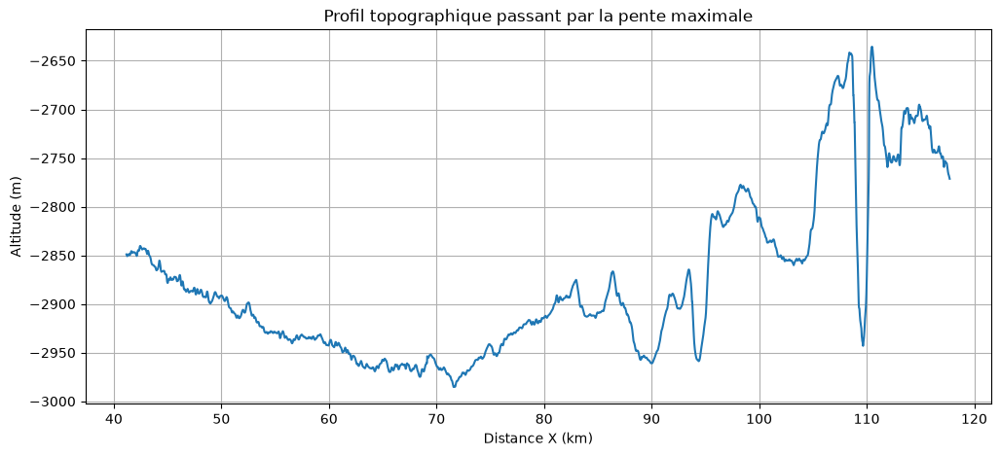

In [17]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

with rasterio.open(chemin_dem) as dem:
    # Ligne horizontale passant par le pixel de pente maximale
    ligne = ligne_max
    profil = dem.read(
        1,
        window=rasterio.windows.Window(
            0,
            ligne,
            dem.width,
            1
        )
    )[0]

# Coordonnées horizontales en mètres
distances = np.arange(len(profil)) * resolution_x

# Masquer les valeurs NoData
profil = np.where(
    profil <= -3e38,
    np.nan,
    profil
)

# Graphique du profil topographique
plt.figure(figsize=(12, 5))

plt.plot(distances / 1000, profil)

plt.xlabel("Distance X (km)")
plt.ylabel("Altitude (m)")
plt.title("Profil topographique passant par la pente maximale")
plt.grid(True)

plt.show()

In [18]:
import numpy as np
import rasterio

with rasterio.open(chemin_dem) as dem:
    ligne = ligne_max
    
    profil = dem.read(
        1,
        window=rasterio.windows.Window(
            0, ligne, dem.width, 1
        )
    )[0]

profil = np.where(
    profil <= -3e38,
    np.nan,
    profil
)

distances = np.arange(len(profil)) * resolution_x / 1000

print("Distance (km) | Altitude (m)")
print("-" * 30)

for distance, altitude_point in zip(distances, profil):
    if not np.isnan(altitude_point):
        print(f"{distance:10.3f} | {altitude_point:10.2f}")

Distance (km) | Altitude (m)
------------------------------
    41.176 |   -2848.96
    41.197 |   -2849.54
    41.217 |   -2850.40
    41.237 |   -2850.80
    41.257 |   -2850.74
    41.278 |   -2850.33
    41.298 |   -2849.92
    41.318 |   -2849.67
    41.338 |   -2849.51
    41.359 |   -2849.52
    41.379 |   -2849.55
    41.399 |   -2849.23
    41.419 |   -2848.48
    41.439 |   -2849.67
    41.460 |   -2849.51
    41.480 |   -2849.52
    41.500 |   -2849.55
    41.520 |   -2849.23
    41.541 |   -2848.48
    41.561 |   -2847.55
    41.581 |   -2846.62
    41.601 |   -2845.97
    41.622 |   -2845.74
    41.642 |   -2845.74
    41.662 |   -2845.92
    41.682 |   -2846.39
    41.703 |   -2846.97
    41.723 |   -2847.30
    41.743 |   -2847.31
    41.763 |   -2847.18
    41.783 |   -2847.04
    41.804 |   -2846.85
    41.824 |   -2846.70
    41.844 |   -2846.70
    41.864 |   -2846.78
    41.885 |   -2846.87
    41.905 |   -2846.95
    41.925 |   -2847.00
    41.945 |   -2846.96
    

In [19]:
print("Distance (km) | Altitude (m)")
print("-" * 30)

pas = 100

for i in range(0, len(profil), pas):
    if not np.isnan(profil[i]):
        print(f"{distances[i]:10.2f} | {profil[i]:10.2f}")

Distance (km) | Altitude (m)
------------------------------
     42.49 |   -2840.79
     44.52 |   -2866.44
     46.54 |   -2885.02
     48.56 |   -2893.19
     50.59 |   -2896.00
     52.61 |   -2900.13
     54.63 |   -2928.35
     56.66 |   -2938.56
     58.68 |   -2936.71
     60.70 |   -2941.78
     62.73 |   -2962.88
     64.75 |   -2961.67
     66.77 |   -2961.58
     68.80 |   -2969.36
     70.82 |   -2967.91
     72.84 |   -2968.78
     74.87 |   -2941.48
     76.89 |   -2930.62
     78.91 |   -2919.85
     80.94 |   -2900.58
     82.96 |   -2875.39
     84.98 |   -2908.69
     87.01 |   -2892.60
     89.03 |   -2956.81
     91.05 |   -2922.27
     93.08 |   -2888.47
     95.10 |   -2899.99
     97.12 |   -2815.39
     99.15 |   -2788.28
    101.17 |   -2836.36
    103.19 |   -2859.62
    105.22 |   -2789.55
    107.24 |   -2667.09
    109.26 |   -2899.79
    111.29 |   -2705.36
    113.31 |   -2718.14
    115.33 |   -2710.93
    117.36 |   -2754.71


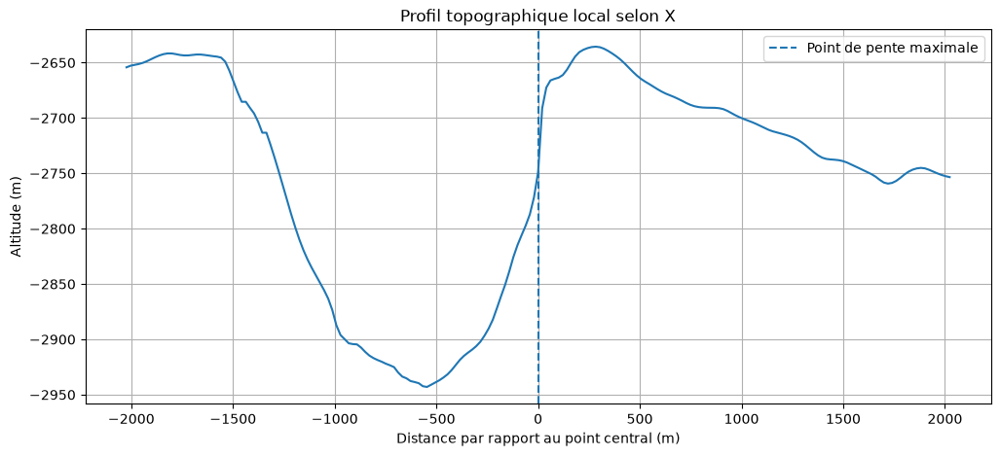

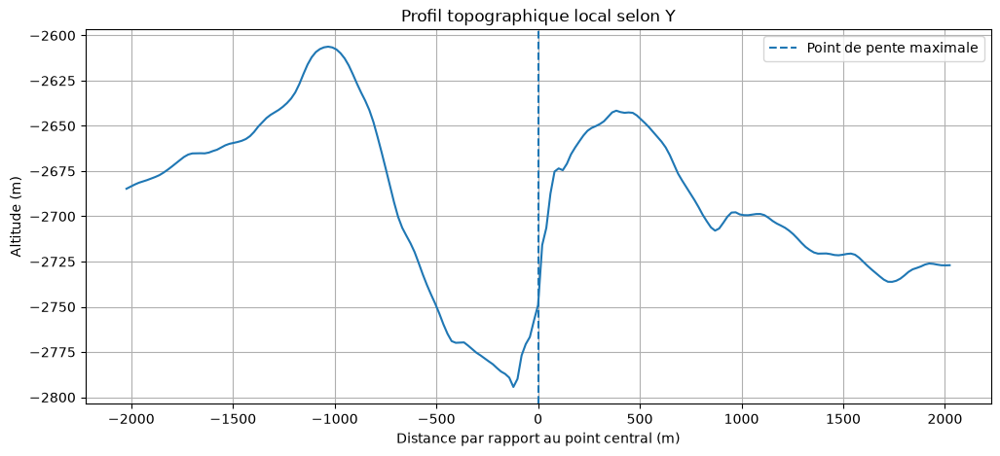

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# Nombre de pixels de chaque côté du point étudié
rayon_profil = 100

with rasterio.open(chemin_dem) as dem:
    # Profil horizontal : variation selon X
    ligne = ligne_max
    col_min = max(0, colonne_max - rayon_profil)
    col_max = min(dem.width, colonne_max + rayon_profil + 1)

    profil_x = dem.read(
        1,
        window=rasterio.windows.Window(
            col_min,
            ligne,
            col_max - col_min,
            1
        )
    )[0]

    # Profil vertical : variation selon Y
    col = colonne_max
    row_min = max(0, ligne_max - rayon_profil)
    row_max = min(dem.height, ligne_max + rayon_profil + 1)

    profil_y = dem.read(
        1,
        window=rasterio.windows.Window(
            col,
            row_min,
            1,
            row_max - row_min
        )
    )[:, 0]

profil_x = np.where(profil_x <= -3e38, np.nan, profil_x)
profil_y = np.where(profil_y <= -3e38, np.nan, profil_y)

distance_x = (
    np.arange(len(profil_x)) - (colonne_max - col_min)
) * resolution_x

distance_y = (
    np.arange(len(profil_y)) - (ligne_max - row_min)
) * resolution_y

fig = plt.figure(figsize=(12, 5))
plt.plot(distance_x, profil_x)
plt.axvline(0, linestyle="--", label="Point de pente maximale")
plt.xlabel("Distance par rapport au point central (m)")
plt.ylabel("Altitude (m)")
plt.title("Profil topographique local selon X")
plt.legend()
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(12, 5))
plt.plot(distance_y, profil_y)
plt.axvline(0, linestyle="--", label="Point de pente maximale")
plt.xlabel("Distance par rapport au point central (m)")
plt.ylabel("Altitude (m)")
plt.title("Profil topographique local selon Y")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
print("=== Profil local selon X ===")
print("Distance (m) | Altitude (m)")
print("-" * 30)

for i in range(0, len(profil_x), 10):
    if not np.isnan(profil_x[i]):
        print(f"{distance_x[i]:11.1f} | {profil_x[i]:11.2f}")

print("\n=== Profil local selon Y ===")
print("Distance (m) | Altitude (m)")
print("-" * 30)

for i in range(0, len(profil_y), 10):
    if not np.isnan(profil_y[i]):
        print(f"{distance_y[i]:11.1f} | {profil_y[i]:11.2f}")

=== Profil local selon X ===
Distance (m) | Altitude (m)
------------------------------
    -2023.4 |    -2654.18
    -1821.1 |    -2641.60
    -1618.7 |    -2643.57
    -1416.4 |    -2690.77
    -1214.0 |    -2786.74
    -1011.7 |    -2873.44
     -809.4 |    -2916.93
     -607.0 |    -2938.58
     -404.7 |    -2923.10
     -202.3 |    -2871.79
        0.0 |    -2749.07
      202.3 |    -2640.49
      404.7 |    -2647.13
      607.0 |    -2676.06
      809.4 |    -2690.50
     1011.7 |    -2700.91
     1214.0 |    -2715.06
     1416.4 |    -2736.93
     1618.7 |    -2748.95
     1821.1 |    -2748.48
     2023.4 |    -2753.42

=== Profil local selon Y ===
Distance (m) | Altitude (m)
------------------------------
    -2023.4 |    -2684.76
    -1821.1 |    -2674.27
    -1618.7 |    -2664.79
    -1416.4 |    -2655.71
    -1214.0 |    -2634.90
    -1011.7 |    -2606.65
     -809.4 |    -2647.90
     -607.0 |    -2719.79
     -404.7 |    -2769.92
     -202.3 |    -2783.85
        0.0 |    

In [22]:
import rasterio
from pathlib import Path

chemin_ori = Path.home() / "Downloads" / "CTX_OXIA_ORI_6m.tif"

with rasterio.open(chemin_ori) as ori:
    print("Largeur :", ori.width, "pixels")
    print("Hauteur :", ori.height, "pixels")
    print("Nombre de bandes :", ori.count)
    print("Type de données :", ori.dtypes[0])
    print("Résolution :", ori.res)
    print("CRS :", ori.crs)
    print("Valeur NoData :", ori.nodata)
    print("Emprise :", ori.bounds)

Largeur : 19682 pixels
Hauteur : 19990 pixels
Nombre de bandes : 1
Type de données : uint8
Résolution : (6.071097939799994, 6.071158607700002)
CRS : PROJCS["Equirectangular_Mars_Oxia_Planum",GEOGCS["GCS_Mars_2000",DATUM["D_Mars_2000",SPHEROID["Mars_2000_IAU_IAG",3396190,169.894447223612]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",335.45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Valeur NoData : 0.0
Emprise : BoundingBox(left=-51359.24311932433, bottom=1013944.9294798933, right=68132.10653181915, top=1135307.3900478163)


In [23]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

# Zone autour du point de pente maximale
demi_largeur = 2000  # mètres

x_centre = x_max
y_centre = y_max

with rasterio.open(chemin_ori) as ori:
    fenetre = from_bounds(
        x_centre - demi_largeur,
        y_centre - demi_largeur,
        x_centre + demi_largeur,
        y_centre + demi_largeur,
        transform=ori.transform
    )

    image_locale = ori.read(1, window=fenetre)

    emprise_locale = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

plt.figure(figsize=(10, 10))

plt.imshow(
    image_locale,
    extent=[
        emprise_locale.left,
        emprise_locale.right,
        emprise_locale.bottom,
        emprise_locale.top
    ],
    cmap="gray"
)

plt.scatter(
    x_centre,
    y_centre,
    marker="+",
    s=150
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("Image CTX autour de la pente maximale")
plt.show()

AttributeError: 'tuple' object has no attribute 'left'

<Figure size 1000x1000 with 0 Axes>

In [24]:
import rasterio
from rasterio.windows import from_bounds

demi_largeur = 2000

with rasterio.open(chemin_ori) as ori:
    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        transform=ori.transform
    )

    print("Fenêtre :", fenetre)
    print("Largeur :", fenetre.width)
    print("Hauteur :", fenetre.height)
    print("Point X :", x_max)
    print("Point Y :", y_max)
    print("Emprise ORI :", ori.bounds)

Fenêtre : Window(col_off=np.float64(17763.846503877794), row_off=np.float64(13728.817343426037), width=np.float64(658.8594089015423), height=np.float64(658.8528250483905))
Largeur : 658.8594089015423
Hauteur : 658.8528250483905
Point X : 58486.808793291464
Point Y : 1049957.5624597343
Emprise ORI : BoundingBox(left=-51359.24311932433, bottom=1013944.9294798933, right=68132.10653181915, top=1135307.3900478163)


Taille de l'image extraite : (659, 659)
Valeur minimale : 7
Valeur maximale : 254


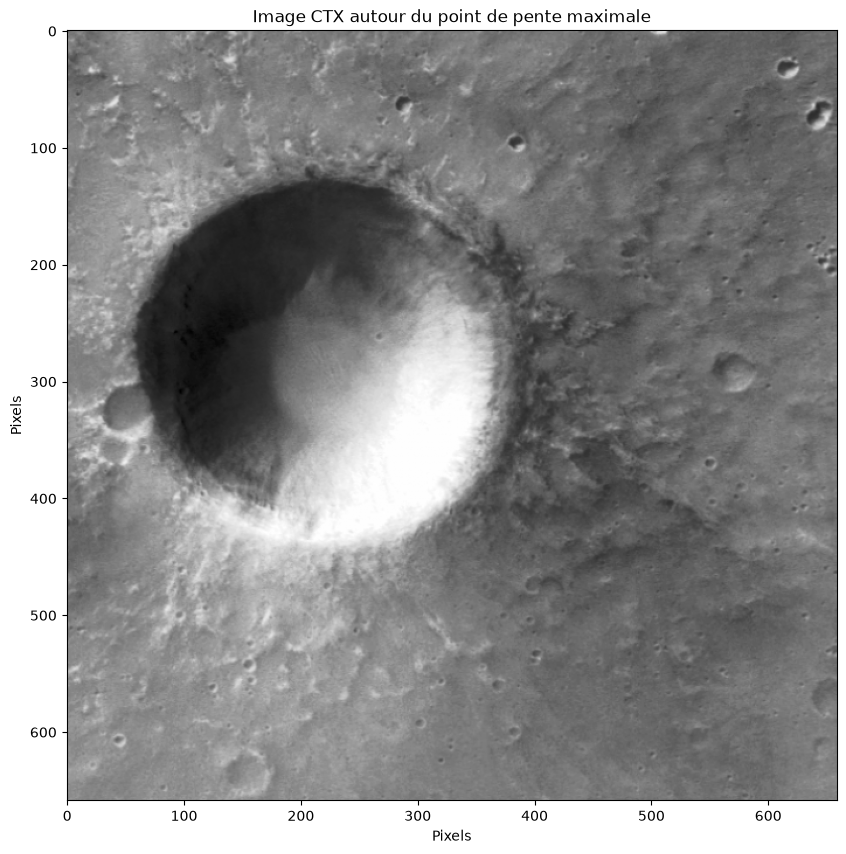

In [25]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

demi_largeur = 2000

with rasterio.open(chemin_ori) as ori:
    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    image_locale = ori.read(1, window=fenetre)

    print("Taille de l'image extraite :", image_locale.shape)
    print("Valeur minimale :", image_locale.min())
    print("Valeur maximale :", image_locale.max())

plt.figure(figsize=(10, 10))
plt.imshow(image_locale, cmap="gray")
plt.title("Image CTX autour du point de pente maximale")
plt.xlabel("Pixels")
plt.ylabel("Pixels")
plt.show()

In [26]:
import numpy as np

valeurs = image_locale.astype(float)

print("=== Analyse numérique de l'image CTX ===")
print()
print(f"Nombre total de pixels : {valeurs.size:,}")
print(f"Valeur minimale : {np.min(valeurs):.1f}")
print(f"Valeur maximale : {np.max(valeurs):.1f}")
print(f"Valeur moyenne : {np.mean(valeurs):.2f}")
print(f"Valeur médiane : {np.median(valeurs):.2f}")
print(f"Écart-type : {np.std(valeurs):.2f}")

=== Analyse numérique de l'image CTX ===

Nombre total de pixels : 434,281
Valeur minimale : 7.0
Valeur maximale : 254.0
Valeur moyenne : 124.10
Valeur médiane : 119.00
Écart-type : 41.34


In [27]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

demi_largeur = 2000

with rasterio.open(chemin_ori) as ori:
    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    image_locale = ori.read(1, window=fenetre)

    emprise = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

plt.figure(figsize=(10, 10))

plt.imshow(
    image_locale,
    cmap="gray",
    extent=[
        emprise.left,
        emprise.right,
        emprise.bottom,
        emprise.top
    ]
)

plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=200,
    linewidths=2,
    label="Point de pente maximale"
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("CTX : localisation de la pente maximale du DEM")
plt.legend()
plt.show()

AttributeError: 'tuple' object has no attribute 'left'

<Figure size 1000x1000 with 0 Axes>

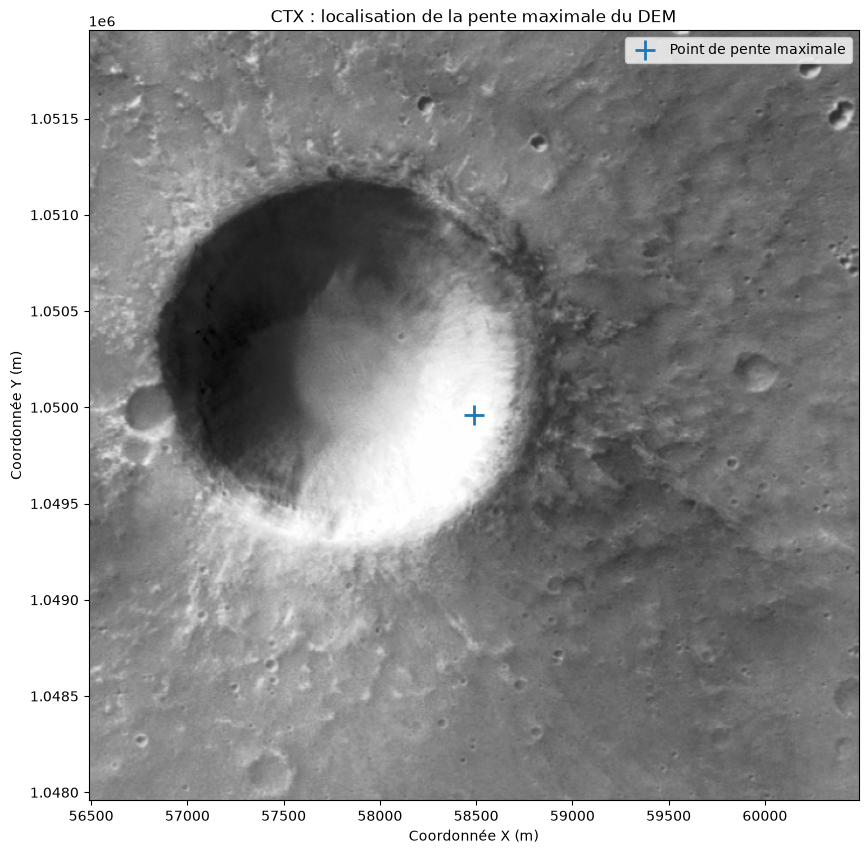

In [28]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

demi_largeur = 2000

with rasterio.open(chemin_ori) as ori:
    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    image_locale = ori.read(1, window=fenetre)

    left, bottom, right, top = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

plt.figure(figsize=(10, 10))

plt.imshow(
    image_locale,
    cmap="gray",
    extent=[left, right, bottom, top]
)

plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=200,
    linewidths=2,
    label="Point de pente maximale"
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("CTX : localisation de la pente maximale du DEM")
plt.legend()
plt.show()

In [29]:
# Analyse de la position du maximum de pente dans les deux profils

pente_array = pente.filled(np.nan)

# Pente le long du profil X
pente_x = pente_array[ligne_max, 
                      max(0, colonne_max - rayon_profil):
                      min(pente_array.shape[1], colonne_max + rayon_profil + 1)]

# Pente le long du profil Y
pente_y = pente_array[
    max(0, ligne_max - rayon_profil):
    min(pente_array.shape[0], ligne_max + rayon_profil + 1),
    colonne_max
]

print("=== PROFIL X : zone du maximum de pente ===")

indices_x = np.argsort(np.nan_to_num(pente_x, nan=-1))[-10:]
indices_x = np.sort(indices_x)

for i in indices_x:
    print(
        f"Distance : {distance_x[i]:8.1f} m | "
        f"Altitude : {profil_x[i]:9.2f} m | "
        f"Pente : {pente_x[i]:6.2f}°"
    )

print("\n=== PROFIL Y : zone du maximum de pente ===")

indices_y = np.argsort(np.nan_to_num(pente_y, nan=-1))[-10:]
indices_y = np.sort(indices_y)

for i in indices_y:
    print(
        f"Distance : {distance_y[i]:8.1f} m | "
        f"Altitude : {profil_y[i]:9.2f} m | "
        f"Pente : {pente_y[i]:6.2f}°"
    )

=== PROFIL X : zone du maximum de pente ===
Distance :  -1254.5 m | Altitude :  -2761.20 m | Pente :  33.66°
Distance :  -1234.3 m | Altitude :  -2774.13 m | Pente :  33.84°
Distance :  -1011.7 m | Altitude :  -2873.44 m | Pente :  34.21°
Distance :   -991.5 m | Altitude :  -2887.36 m | Pente :  34.90°
Distance :   -141.6 m | Altitude :  -2838.61 m | Pente :  33.60°
Distance :    -40.5 m | Altitude :  -2787.02 m | Pente :  37.36°
Distance :    -20.2 m | Altitude :  -2771.71 m | Pente :  52.12°
Distance :      0.0 m | Altitude :  -2749.07 m | Pente :  65.96°
Distance :     20.2 m | Altitude :  -2691.11 m | Pente :  65.16°
Distance :     40.5 m | Altitude :  -2672.44 m | Pente :  41.67°

=== PROFIL Y : zone du maximum de pente ===
Distance :    -80.9 m | Altitude :  -2776.86 m | Pente :  53.54°
Distance :    -60.7 m | Altitude :  -2770.67 m | Pente :  53.27°
Distance :    -40.5 m | Altitude :  -2766.72 m | Pente :  52.07°
Distance :    -20.2 m | Altitude :  -2757.57 m | Pente :  53.67°
D

In [30]:
# Variation d'altitude autour du maximum de pente

print("=== Variation d'altitude autour du maximum ===")
print()

for distance_cible in [-100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100]:
    indice = np.argmin(np.abs(distance_x - distance_cible))
    
    print(
        f"X = {distance_x[indice]:7.1f} m | "
        f"Altitude = {profil_x[indice]:9.2f} m | "
        f"Pente = {pente_x[indice]:6.2f}°"
    )

print()
print("Variation d'altitude entre -100 m et +100 m :")

i1 = np.argmin(np.abs(distance_x + 100))
i2 = np.argmin(np.abs(distance_x - 100))

variation = profil_x[i2] - profil_x[i1]

print(f"{variation:.2f} m")

=== Variation d'altitude autour du maximum ===

X =  -101.2 m | Altitude =  -2814.82 m | Pente =  27.13°
X =   -80.9 m | Altitude =  -2805.79 m | Pente =  25.54°
X =   -60.7 m | Altitude =  -2797.06 m | Pente =  29.34°
X =   -40.5 m | Altitude =  -2787.02 m | Pente =  37.36°
X =   -20.2 m | Altitude =  -2771.71 m | Pente =  52.12°
X =     0.0 m | Altitude =  -2749.07 m | Pente =  65.96°
X =    20.2 m | Altitude =  -2691.11 m | Pente =  65.16°
X =    40.5 m | Altitude =  -2672.44 m | Pente =  41.67°
X =    60.7 m | Altitude =  -2666.02 m | Pente =  17.51°
X =    80.9 m | Altitude =  -2664.59 m | Pente =  13.08°
X =   101.2 m | Altitude =  -2663.47 m | Pente =  15.38°

Variation d'altitude entre -100 m et +100 m :
151.34 m


In [1]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

# Taille de la zone étudiée autour du point de pente maximale
demi_largeur = 2000

with rasterio.open(chemin_ori) as ori:
    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    image_locale = ori.read(1, window=fenetre)

    left, bottom, right, top = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

plt.figure(figsize=(10, 10))

plt.imshow(
    image_locale,
    cmap="gray",
    extent=[left, right, bottom, top]
)

plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=250,
    linewidths=2,
    label="Point de pente maximale"
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("Image CTX autour de la pente maximale")
plt.legend()
plt.show()

NameError: name 'chemin_ori' is not defined

In [2]:
from pathlib import Path

chemin_ori = Path.home() / "Downloads" / "CTX_OXIA_ORI_6m.tif"

print("Fichier CTX :", chemin_ori)

Fichier CTX : C:\Users\User\Downloads\CTX_OXIA_ORI_6m.tif


In [3]:
Fichier CTX : C:\Users\User\Downloads\CTX_OXIA_ORI_6m.tif

SyntaxError: invalid syntax (387835888.py, line 1)

In [4]:
import rasterio
from pathlib import Path

chemin_ori = Path.home() / "Downloads" / "CTX_ORI_6m.tif"

print("Fichier CTX :", chemin_ori)
print("Existe :", chemin_ori.exists())

Fichier CTX : C:\Users\User\Downloads\CTX_ORI_6m.tif
Existe : False


In [5]:
import rasterio
from pathlib import Path

chemin_ori = Path.home() / "Downloads" / "CTX_ORI" / "CTX_ORI_6m.tif"

print("Fichier CTX :", chemin_ori)
print("Existe :", chemin_ori.exists())


Fichier CTX : C:\Users\User\Downloads\CTX_ORI\CTX_ORI_6m.tif
Existe : False


In [6]:
import rasterio
from pathlib import Path

chemin_ori = Path.home() / "Downloads" / "CTX_OXIA_ORI" / "CTX_OXIA_ORI_6m.tif"

print("Fichier CTX :", chemin_ori)
print("Existe :", chemin_ori.exists())

Fichier CTX : C:\Users\User\Downloads\CTX_OXIA_ORI\CTX_OXIA_ORI_6m.tif
Existe : False


In [7]:
import rasterio
from pathlib import Path

chemin_ori = Path.home() / "Downloads" / "CTX_OXIA_ORI" / "CTX_OXIA_ORI_6m.tif"

print("Fichier CTX :", chemin_ori)
print("Existe :", chemin_ori.exists())

Fichier CTX : C:\Users\User\Downloads\CTX_OXIA_ORI\CTX_OXIA_ORI_6m.tif
Existe : False


In [8]:
from pathlib import Path

fichiers_tif = list(Path.home().glob("Downloads/**/*.tif"))

for fichier in fichiers_tif:
    print(fichier)

C:\Users\User\Downloads\CASSIS_OP_sRGB_mosaic_4m_april2021.tif
C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif
C:\Users\User\Downloads\CTX_OXIA_ORI_6m.tif


In [9]:
from pathlib import Path

fichiers_ctx = list(Path.home().glob("Downloads/**/CTX*ORI*.tif"))

for fichier in fichiers_ctx:
    print("Fichier trouvé :", fichier)

Fichier trouvé : C:\Users\User\Downloads\CTX_OXIA_ORI_6m.tif


In [10]:
from pathlib import Path

chemin_ori = list(
    Path.home().glob("Downloads/**/CTX*ORI*.tif")
)[0]

print("Fichier CTX :", chemin_ori)
print("Existe :", chemin_ori.exists())

Fichier CTX : C:\Users\User\Downloads\CTX_OXIA_ORI_6m.tif
Existe : True


In [11]:
import rasterio

with rasterio.open(chemin_ori) as ori:
    print("Largeur :", ori.width, "pixels")
    print("Hauteur :", ori.height, "pixels")
    print("Nombre de bandes :", ori.count)
    print("Type de données :", ori.dtypes[0])
    print("Résolution :", ori.res)
    print("CRS :", ori.crs)
    print("Valeur NoData :", ori.nodata)
    print("Emprise :", ori.bounds)

Largeur : 19682 pixels
Hauteur : 19990 pixels
Nombre de bandes : 1
Type de données : uint8
Résolution : (6.071097939799994, 6.071158607700002)
CRS : PROJCS["Equirectangular_Mars_Oxia_Planum",GEOGCS["GCS_Mars_2000",DATUM["D_Mars_2000",SPHEROID["Mars_2000_IAU_IAG",3396190,169.894447223612]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",335.45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Valeur NoData : 0.0
Emprise : BoundingBox(left=-51359.24311932433, bottom=1013944.9294798933, right=68132.10653181915, top=1135307.3900478163)


In [12]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

demi_largeur = 2000  # 2 km autour du point central

with rasterio.open(chemin_ori) as ori:

    # Définition de la même zone géographique que précédemment
    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    # Extraction uniquement de cette petite zone
    image_locale = ori.read(1, window=fenetre)

    # Coordonnées géographiques exactes de la fenêtre extraite
    left, bottom, right, top = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

plt.figure(figsize=(10, 10))

plt.imshow(
    image_locale,
    cmap="gray",
    extent=[left, right, bottom, top]
)

plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=250,
    linewidths=2,
    label="Pente maximale du DEM"
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("CTX : zone correspondant à la pente maximale du DEM")
plt.legend()
plt.show()

NameError: name 'x_max' is not defined

In [13]:
import numpy as np
import rasterio

pente_array = pente.filled(np.nan)

ligne_max, colonne_max = np.unravel_index(
    np.nanargmax(pente_array),
    pente_array.shape
)

with rasterio.open(chemin_dem) as dem:
    x_max, y_max = dem.xy(ligne_max, colonne_max)

print("Position du maximum de pente :")
print(f"X = {x_max:.2f} m")
print(f"Y = {y_max:.2f} m")
print(f"Pente maximale = {pente_array[ligne_max, colonne_max]:.2f}°")

NameError: name 'pente' is not defined

In [14]:
import numpy as np
import rasterio
from pathlib import Path

# Localisation du DEM
chemin_dem = Path.home() / "Downloads" / "CTX_OXIA_DEM" / "CTX_OXIA_DEM_20m.tif"

# Lecture du DEM et calcul de la pente
with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)
    resolution_x, resolution_y = dem.res

gradient_y, gradient_x = np.gradient(
    altitude.filled(np.nan),
    resolution_y,
    resolution_x
)

pente = np.degrees(
    np.arctan(
        np.sqrt(gradient_x**2 + gradient_y**2)
    )
)

pente = np.ma.masked_invalid(pente)

print("Pente minimale :", pente.min(), "°")
print("Pente maximale :", pente.max(), "°")
print("Pente moyenne :", pente.mean(), "°")
print("Pente médiane :", np.ma.median(pente), "°")

RasterioIOError: C:\Users\User\Downloads\CTX_OXIA_DEM\CTX_OXIA_DEM_20m.tif: No such file or directory

In [15]:
from pathlib import Path

fichiers_dem = list(
    Path.home().glob("Downloads/**/CTX*DEM*.tif")
)

for fichier in fichiers_dem:
    print("Fichier DEM trouvé :", fichier)

Fichier DEM trouvé : C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif


In [16]:
chemin_dem = fichiers_dem[0]

print("DEM utilisé :", chemin_dem)
print("Existe :", chemin_dem.exists())

DEM utilisé : C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif
Existe : True


In [17]:
from pathlib import Path

for fichier in Path.home().glob("Downloads/**/*.tif"):
    if "DEM" in fichier.name.upper():
        print(fichier)

C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif


In [18]:
chemin_dem = fichiers_dem[0]

print("DEM utilisé :", chemin_dem)
print("Existe :", chemin_dem.exists())

DEM utilisé : C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif
Existe : True


In [19]:
import numpy as np
import rasterio

with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)
    resolution_x, resolution_y = dem.res

gradient_y, gradient_x = np.gradient(
    altitude.filled(np.nan),
    resolution_y,
    resolution_x
)

pente = np.degrees(
    np.arctan(
        np.sqrt(gradient_x**2 + gradient_y**2)
    )
)

pente = np.ma.masked_invalid(pente)

print("Pente maximale :", pente.max(), "°")
print("Pente moyenne :", pente.mean(), "°")
print("Pente médiane :", np.ma.median(pente), "°")

Pente maximale : 65.96161 °
Pente moyenne : 2.6652313145423796 °
Pente médiane : 1.9694737 °


In [20]:
pente_array = pente.filled(np.nan)

ligne_max, colonne_max = np.unravel_index(
    np.nanargmax(pente_array),
    pente_array.shape
)

with rasterio.open(chemin_dem) as dem:
    x_max, y_max = dem.xy(ligne_max, colonne_max)

print("Coordonnées du maximum de pente :")
print(f"X = {x_max:.2f} m")
print(f"Y = {y_max:.2f} m")
print(f"Pente = {pente_array[ligne_max, colonne_max]:.2f}°")

Coordonnées du maximum de pente :
X = 58486.81 m
Y = 1049957.56 m
Pente = 65.96°


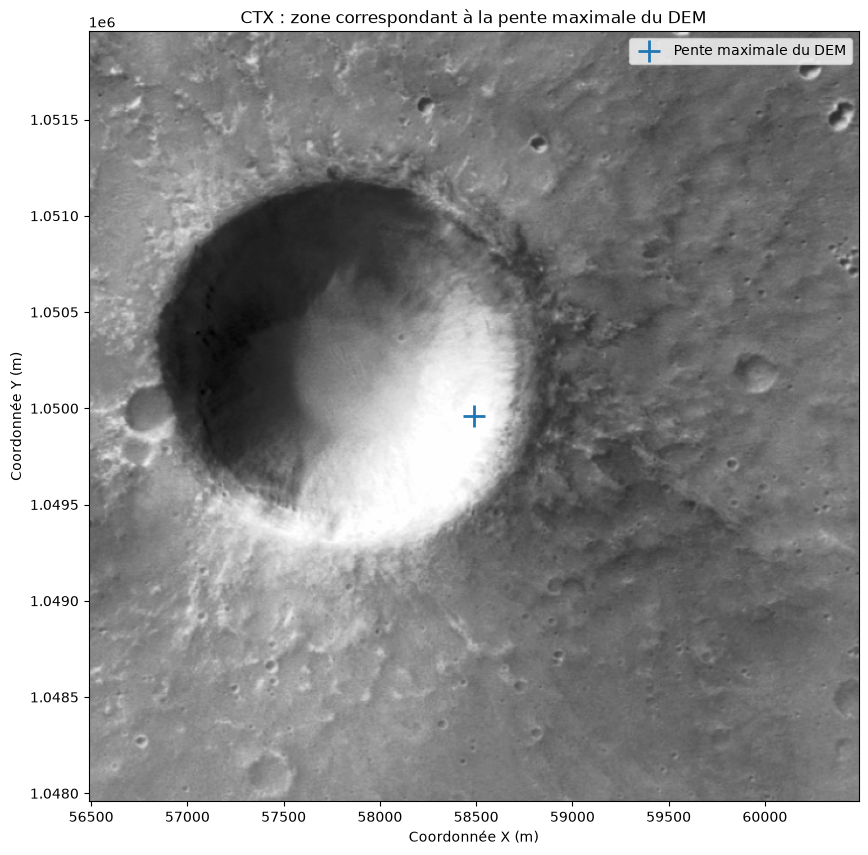

In [21]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

demi_largeur = 2000

with rasterio.open(chemin_ori) as ori:

    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    image_locale = ori.read(1, window=fenetre)

    left, bottom, right, top = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

plt.figure(figsize=(10, 10))

plt.imshow(
    image_locale,
    cmap="gray",
    extent=[left, right, bottom, top]
)

plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=250,
    linewidths=2,
    label="Pente maximale du DEM"
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("CTX : zone correspondant à la pente maximale du DEM")
plt.legend()
plt.show()

In [22]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds

demi_largeur = 500  # 500 m autour du point central

with rasterio.open(chemin_ori) as ori:

    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    image_locale = ori.read(1, window=fenetre, masked=True)

    left, bottom, right, top = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

valeurs = image_locale.compressed()

print("=== CTX : analyse de la zone autour du maximum de pente ===")
print(f"Centre X : {x_max:.2f} m")
print(f"Centre Y : {y_max:.2f} m")
print(f"Zone analysée : {2 * demi_largeur} m × {2 * demi_largeur} m")
print(f"Nombre de pixels valides : {len(valeurs):,}")
print(f"Valeur minimale : {valeurs.min():.0f}")
print(f"Valeur maximale : {valeurs.max():.0f}")
print(f"Valeur moyenne : {valeurs.mean():.2f}")
print(f"Médiane : {np.median(valeurs):.2f}")
print(f"Écart-type : {valeurs.std():.2f}")

# Valeur du pixel CTX le plus proche du point de pente maximale
with rasterio.open(chemin_ori) as ori:
    ligne, colonne = ori.index(x_max, y_max)
    valeur_centrale = ori.read(
        1,
        window=rasterio.windows.Window(colonne, ligne, 1, 1)
    )[0, 0]

print(f"\nValeur CTX au point de pente maximale : {valeur_centrale}")


=== CTX : analyse de la zone autour du maximum de pente ===
Centre X : 58486.81 m
Centre Y : 1049957.56 m
Zone analysée : 1000 m × 1000 m
Nombre de pixels valides : 27,225
Valeur minimale : 51
Valeur maximale : 254
Valeur moyenne : 181.56
Médiane : 209.00
Écart-type : 68.46

Valeur CTX au point de pente maximale : 253


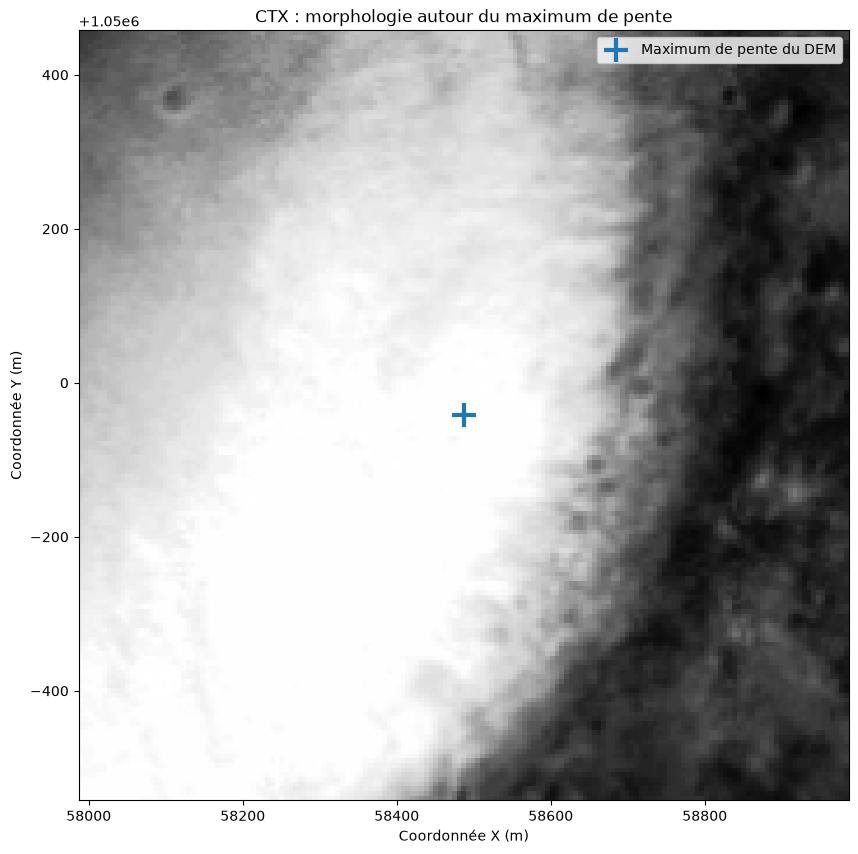

In [23]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

# Zone de 1 km × 1 km autour du point de pente maximale
demi_largeur = 500

with rasterio.open(chemin_ori) as ori:

    fenetre = from_bounds(
        x_max - demi_largeur,
        y_max - demi_largeur,
        x_max + demi_largeur,
        y_max + demi_largeur,
        ori.transform
    )

    image_locale = ori.read(1, window=fenetre)

    left, bottom, right, top = rasterio.windows.bounds(
        fenetre,
        ori.transform
    )

plt.figure(figsize=(10, 10))

plt.imshow(
    image_locale,
    cmap="gray",
    extent=[left, right, bottom, top]
)

plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=300,
    linewidths=3,
    label="Maximum de pente du DEM"
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("CTX : morphologie autour du maximum de pente")
plt.legend()

plt.show()

=== MORPHOLOGIE LOCALE ===
Distance étudiée : -485.6 m à 485.6 m
Altitude minimale : -2937.02 m
Altitude maximale : -2635.51 m
Variation totale d'altitude : 301.52 m
Pente maximale : 65.96°
Pente moyenne du profil : 19.53°


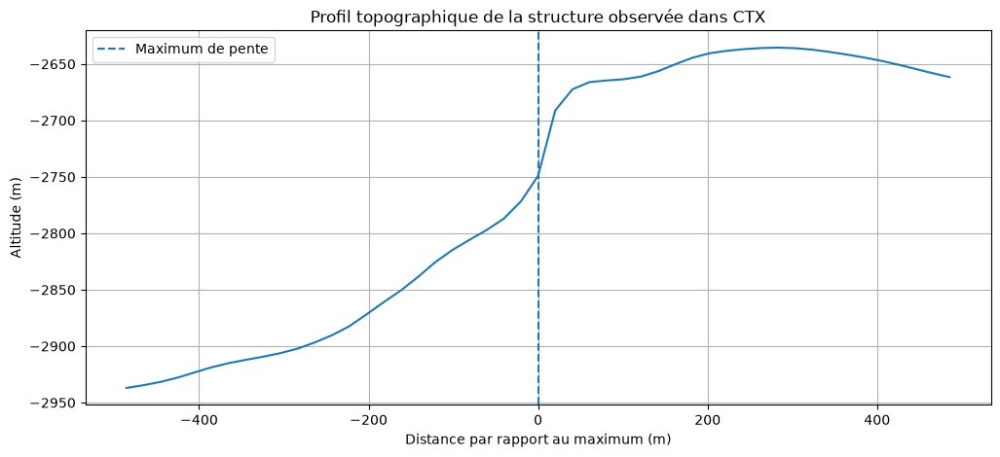

In [24]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Distance analysée de chaque côté du point central
rayon = 500  # mètres

with rasterio.open(chemin_dem) as dem:

    # Trouver la ligne et la colonne du maximum de pente
    ligne_max, colonne_max = np.unravel_index(
        np.nanargmax(pente.filled(np.nan)),
        pente.shape
    )

    # Extraire un profil horizontal centré sur le maximum
    col_min = max(0, colonne_max - int(rayon / resolution_x))
    col_max = min(dem.width, colonne_max + int(rayon / resolution_x) + 1)

    profil_altitude = dem.read(
        1,
        window=rasterio.windows.Window(
            col_min,
            ligne_max,
            col_max - col_min,
            1
        )
    )[0]

# Remplacer les valeurs NoData
profil_altitude = np.where(
    profil_altitude <= -3e38,
    np.nan,
    profil_altitude
)

# Distance par rapport au point central
distances = (
    np.arange(len(profil_altitude))
    - (colonne_max - col_min)
) * resolution_x

# Pente correspondante
profil_pente = pente.filled(np.nan)[
    ligne_max,
    col_min:col_max
]

# Statistiques
valide = ~np.isnan(profil_altitude)

alt_min = np.nanmin(profil_altitude)
alt_max = np.nanmax(profil_altitude)
variation = alt_max - alt_min

print("=== MORPHOLOGIE LOCALE ===")
print(f"Distance étudiée : {distances.min():.1f} m à {distances.max():.1f} m")
print(f"Altitude minimale : {alt_min:.2f} m")
print(f"Altitude maximale : {alt_max:.2f} m")
print(f"Variation totale d'altitude : {variation:.2f} m")
print(f"Pente maximale : {np.nanmax(profil_pente):.2f}°")
print(f"Pente moyenne du profil : {np.nanmean(profil_pente):.2f}°")

# Graphique
plt.figure(figsize=(12, 5))
plt.plot(distances, profil_altitude)
plt.axvline(0, linestyle="--", label="Maximum de pente")
plt.xlabel("Distance par rapport au maximum (m)")
plt.ylabel("Altitude (m)")
plt.title("Profil topographique de la structure observée dans CTX")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
print("=== ÉVALUATION QUANTITATIVE DE LA MORPHOLOGIE ===")
print(f"Distance analysée : {distances.min():.1f} à {distances.max():.1f} m")
print(f"Altitude minimale : {alt_min:.2f} m")
print(f"Altitude maximale : {alt_max:.2f} m")
print(f"Variation totale d'altitude : {variation:.2f} m")
print(f"Pente maximale : {np.nanmax(profil_pente):.2f}°")
print(f"Pente moyenne : {np.nanmean(profil_pente):.2f}°")

=== ÉVALUATION QUANTITATIVE DE LA MORPHOLOGIE ===
Distance analysée : -485.6 à 485.6 m
Altitude minimale : -2937.02 m
Altitude maximale : -2635.51 m
Variation totale d'altitude : 301.52 m
Pente maximale : 65.96°
Pente moyenne : 19.53°


In [26]:
# Seuils de pente à analyser
seuils = [10, 20, 30, 45]

print("=== LARGEUR DES ZONES DE FORTE PENTE ===")

for seuil in seuils:

    masque = profil_pente >= seuil

    # Nombre de pixels répondant au seuil
    nombre_pixels = np.count_nonzero(masque)

    if nombre_pixels > 0:
        distances_zone = distances[masque]

        largeur = (
            distances_zone.max()
            - distances_zone.min()
        )

        print(
            f"Pente ≥ {seuil:2d}° : "
            f"{nombre_pixels} pixels | "
            f"largeur approximative : {largeur:.1f} m | "
            f"de {distances_zone.min():.1f} à "
            f"{distances_zone.max():.1f} m"
        )

    else:
        print(f"Pente ≥ {seuil:2d}° : aucune zone")

=== LARGEUR DES ZONES DE FORTE PENTE ===
Pente ≥ 10° : 39 pixels | largeur approximative : 971.2 m | de -485.6 à 485.6 m
Pente ≥ 20° : 16 pixels | largeur approximative : 303.5 m | de -263.0 à 40.5 m
Pente ≥ 30° : 10 pixels | largeur approximative : 242.8 m | de -202.3 à 40.5 m
Pente ≥ 45° : 3 pixels | largeur approximative : 40.5 m | de -20.2 à 20.2 m


=== PROFIL ÉLARGI ===
Distance : -1982.9 à 1982.9 m
Altitude minimale : -2943.04 m
Altitude maximale : -2635.51 m
Variation totale : 307.53 m
Pente maximale : 63.34°
Pente moyenne : 10.01°

=== LARGEUR DES ZONES DE FORTE PENTE ===
Pente ≥ 10° : 2003.2 m | de -1537.8 à 465.4 m
Pente ≥ 20° : 1558.0 m | de -1517.6 à 40.5 m
Pente ≥ 30° : 1335.5 m | de -1295.0 à 40.5 m
Pente ≥ 45° : 20.2 m | de 0.0 à 20.2 m


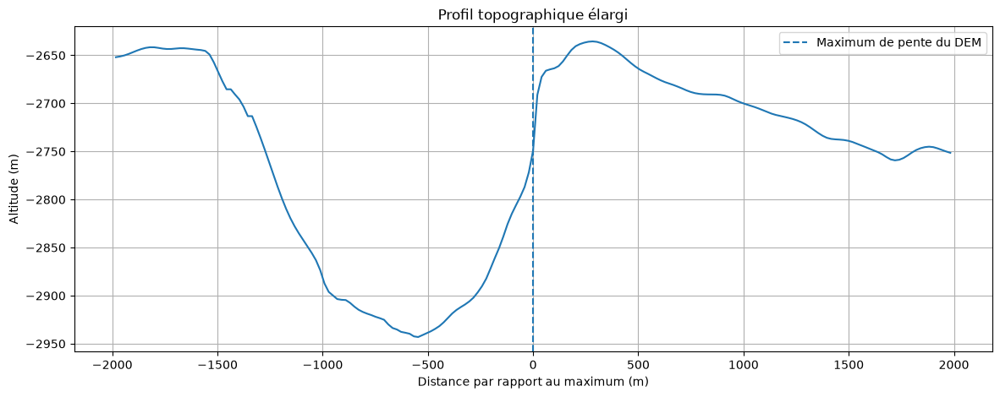

In [27]:
rayon = 2000  # 2 km de chaque côté

with rasterio.open(chemin_dem) as dem:

    col_min = max(0, colonne_max - int(rayon / resolution_x))
    col_max = min(
        dem.width,
        colonne_max + int(rayon / resolution_x) + 1
    )

    profil_altitude_large = dem.read(
        1,
        window=rasterio.windows.Window(
            col_min,
            ligne_max,
            col_max - col_min,
            1
        )
    )[0]

profil_altitude_large = np.where(
    profil_altitude_large <= -3e38,
    np.nan,
    profil_altitude_large
)

distances_large = (
    np.arange(len(profil_altitude_large))
    - (colonne_max - col_min)
) * resolution_x

# Calcul de la pente le long du nouveau profil
profil_pente_large = np.gradient(
    profil_altitude_large,
    resolution_x
)

profil_pente_large = np.degrees(
    np.arctan(np.abs(profil_pente_large))
)

print("=== PROFIL ÉLARGI ===")
print(f"Distance : {distances_large.min():.1f} à {distances_large.max():.1f} m")
print(f"Altitude minimale : {np.nanmin(profil_altitude_large):.2f} m")
print(f"Altitude maximale : {np.nanmax(profil_altitude_large):.2f} m")
print(f"Variation totale : "
      f"{np.nanmax(profil_altitude_large) - np.nanmin(profil_altitude_large):.2f} m")
print(f"Pente maximale : {np.nanmax(profil_pente_large):.2f}°")
print(f"Pente moyenne : {np.nanmean(profil_pente_large):.2f}°")

print("\n=== LARGEUR DES ZONES DE FORTE PENTE ===")

for seuil in [10, 20, 30, 45]:

    masque = profil_pente_large >= seuil
    distances_zone = distances_large[masque]

    if len(distances_zone) > 0:
        largeur = distances_zone.max() - distances_zone.min()

        print(
            f"Pente ≥ {seuil:2d}° : "
            f"{largeur:.1f} m | "
            f"de {distances_zone.min():.1f} à "
            f"{distances_zone.max():.1f} m"
        )
    else:
        print(f"Pente ≥ {seuil:2d}° : aucune zone")

plt.figure(figsize=(14, 5))
plt.plot(distances_large, profil_altitude_large)
plt.axvline(
    0,
    linestyle="--",
    label="Maximum de pente du DEM"
)
plt.xlabel("Distance par rapport au maximum (m)")
plt.ylabel("Altitude (m)")
plt.title("Profil topographique élargi")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Install SciPy in this notebook's Python environment only if needed
import sys
import subprocess

try:
    from scipy import ndimage
    import scipy
    print(f"SciPy available: {scipy.__version__}")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    from scipy import ndimage
    import scipy
    print(f"SciPy installed: {scipy.__version__}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# `pente` is the DEM-derived 2D slope map, in degrees.
slope = pente.filled(np.nan) if np.ma.isMaskedArray(pente) else np.asarray(pente)

# Locate the global maximum slope in the DEM
ligne_max, colonne_max = np.unravel_index(np.nanargmax(slope), slope.shape)
max_slope = slope[ligne_max, colonne_max]

# Use true DEM pixel dimensions when available
with rasterio.open(chemin_dem) as dem:
    resolution_x = abs(dem.transform.a)
    resolution_y = abs(dem.transform.e)

pixel_area_m2 = resolution_x * resolution_y
structure_8 = np.ones((3, 3), dtype=int)  # 8-neighbour connectivity

results = []
regions_for_plot = {}

for threshold in [10, 20, 30, 45]:
    # Valid pixels at or above the threshold
    mask = np.isfinite(slope) & (slope >= threshold)

    # Label every separate connected steep-slope region
    labels, n_regions = ndimage.label(mask, structure=structure_8)

    # Keep only the region that contains the DEM maximum-slope pixel
    target_label = labels[ligne_max, colonne_max]

    if target_label == 0:
        results.append({
            "Threshold (°)": threshold,
            "Connected regions in DEM": n_regions,
            "Region at maximum": "No",
            "Pixels": 0,
            "Area (m²)": np.nan,
            "Area (km²)": np.nan,
            "East-west span (m)": np.nan,
            "North-south span (m)": np.nan,
        })
        continue

    target = labels == target_label
    rows, cols = np.where(target)

    ew_span = (cols.max() - cols.min() + 1) * resolution_x
    ns_span = (rows.max() - rows.min() + 1) * resolution_y
    area_m2 = target.sum() * pixel_area_m2

    results.append({
        "Threshold (°)": threshold,
        "Connected regions in DEM": n_regions,
        "Region at maximum": "Yes",
        "Pixels": int(target.sum()),
        "Area (m²)": area_m2,
        "Area (km²)": area_m2 / 1e6,
        "East-west span (m)": ew_span,
        "North-south span (m)": ns_span,
    })

    regions_for_plot[threshold] = target

report = pd.DataFrame(results)

print(f"DEM maximum slope: {max_slope:.2f}°")
print(f"Location in DEM array: row {ligne_max}, column {colonne_max}")
display(report.round(2))

# Visual check: each panel shows only the connected region containing the maximum
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

for ax, threshold in zip(axes.ravel(), [10, 20, 30, 45]):
    ax.imshow(slope, cmap="terrain", vmin=0, vmax=min(70, np.nanmax(slope)))
    target = regions_for_plot.get(threshold)

    if target is not None:
        ax.contour(target, levels=[0.5], colors="red", linewidths=1.5)

    ax.plot(colonne_max, ligne_max, "w+", ms=12, mew=2)
    ax.set_title(f"Connected region ≥ {threshold}° containing the maximum")
    ax.set_xlabel("DEM column")
    ax.set_ylabel("DEM row")

plt.show()

SciPy installed: 1.18.1


ModuleNotFoundError: No module named 'pandas'

In [ ]:
print("Notebook cell is running.")
print("pente exists:", "pente" in globals())
print("chemin_dem exists:", "chemin_dem" in globals())

try:
    import scipy
    print("SciPy version:", scipy.__version__)
except Exception as e:
    print("SciPy problem:", repr(e))
    

In [ ]:
1 + 1


DEM maximum slope: 65.96°
Maximum location: row 4230, column 5447

Threshold | All regions | Max-region pixels | Area (km²) | E-W span (m) | N-S span (m)
--------------------------------------------------------------------------------------
      10° |        8747 |              6309 |     2.5830 |       2023.4 |       1881.8
      20° |        1811 |              4082 |     1.6713 |       1679.4 |       1780.6
      30° |         715 |               896 |     0.3668 |       1517.6 |       1011.7
      45° |          86 |                56 |     0.0229 |        283.3 |        283.3


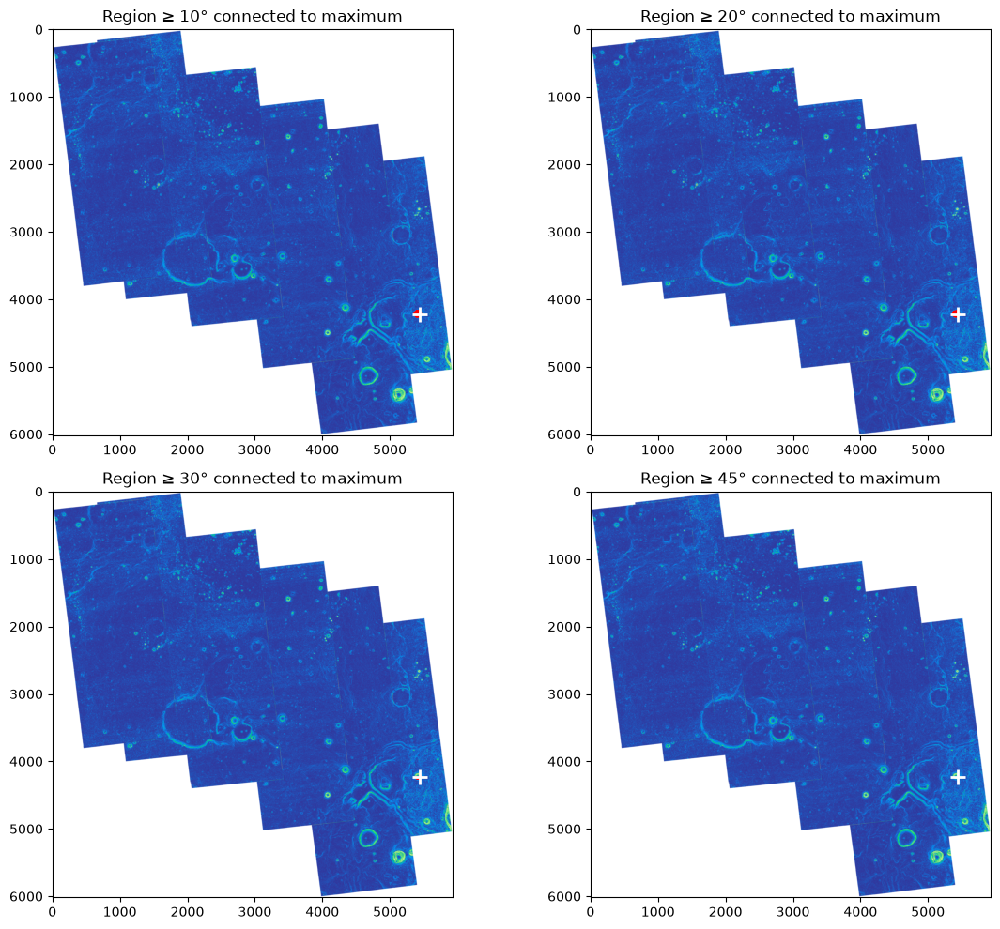

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import rasterio

slope = pente.filled(np.nan) if np.ma.isMaskedArray(pente) else np.asarray(pente)

ligne_max, colonne_max = np.unravel_index(np.nanargmax(slope), slope.shape)
max_slope = slope[ligne_max, colonne_max]

with rasterio.open(chemin_dem) as dem:
    resolution_x = abs(dem.transform.a)
    resolution_y = abs(dem.transform.e)

pixel_area_m2 = resolution_x * resolution_y
structure_8 = np.ones((3, 3), dtype=int)

print(f"DEM maximum slope: {max_slope:.2f}°")
print(f"Maximum location: row {ligne_max}, column {colonne_max}\n")

print("Threshold | All regions | Max-region pixels | Area (km²) | E-W span (m) | N-S span (m)")
print("-" * 86)

regions_for_plot = {}

for threshold in [10, 20, 30, 45]:
    mask = np.isfinite(slope) & (slope >= threshold)
    labels, n_regions = ndimage.label(mask, structure=structure_8)

    target_label = labels[ligne_max, colonne_max]

    if target_label == 0:
        print(f"{threshold:>8}° | {n_regions:>11} | no region containing the maximum")
        continue

    target = labels == target_label
    rows, cols = np.where(target)

    pixels = target.sum()
    area_km2 = pixels * pixel_area_m2 / 1e6
    ew_span = (cols.max() - cols.min() + 1) * resolution_x
    ns_span = (rows.max() - rows.min() + 1) * resolution_y

    print(
        f"{threshold:>8}° | {n_regions:>11} | {pixels:>17} | "
        f"{area_km2:>10.4f} | {ew_span:>12.1f} | {ns_span:>12.1f}"
    )

    regions_for_plot[threshold] = target

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, threshold in zip(axes.ravel(), [10, 20, 30, 45]):
    ax.imshow(slope, cmap="terrain", vmin=0, vmax=min(70, np.nanmax(slope)))

    if threshold in regions_for_plot:
        ax.contour(regions_for_plot[threshold], levels=[0.5],
                   colors="red", linewidths=1.5)

    ax.plot(colonne_max, ligne_max, "w+", ms=12, mew=2)
    ax.set_title(f"Region ≥ {threshold}° connected to maximum")

plt.tight_layout()
plt.show()

In [30]:
# Analyse la position et la forme de la région où la pente dépasse 45°

seuil = 45

# Recréer le masque de pente
masque_45 = pente.filled(np.nan) >= seuil

# Trouver les coordonnées des pixels concernés
lignes_45, colonnes_45 = np.where(masque_45)

print("=== RÉGION DE FORTE PENTE (≥ 45°) ===")
print(f"Nombre de pixels : {len(lignes_45)}")

# Coordonnées géographiques de chaque pixel
with rasterio.open(chemin_dem) as dem:
    coordonnees = [
        dem.xy(ligne, colonne)
        for ligne, colonne in zip(lignes_45, colonnes_45)
    ]

x_45 = np.array([coord[0] for coord in coordonnees])
y_45 = np.array([coord[1] for coord in coordonnees])

print(f"\nCentre approximatif de la région :")
print(f"X = {x_45.mean():.2f} m")
print(f"Y = {y_45.mean():.2f} m")

print("\nÉtendue spatiale totale :")
print(f"X : {x_45.min():.2f} m → {x_45.max():.2f} m")
print(f"Y : {y_45.min():.2f} m → {y_45.max():.2f} m")

print(f"\nLargeur E-W : {x_45.max() - x_45.min():.1f} m")
print(f"Largeur N-S : {y_45.max() - y_45.min():.1f} m")

=== RÉGION DE FORTE PENTE (≥ 45°) ===
Nombre de pixels : 625

Centre approximatif de la région :
X = 38335.41 m
Y = 1052671.75 m

Étendue spatiale totale :
X : -28337.79 m → 66904.20 m
Y : 1025191.00 m → 1133261.43 m

Largeur E-W : 95242.0 m
Largeur N-S : 108070.4 m


In [31]:
# Analyse uniquement la région connectée contenant le maximum de pente

from scipy import ndimage
import numpy as np
import rasterio

seuil = 45

# Masque des pentes ≥ 45°
masque_45 = pente.filled(np.nan) >= seuil

# Identifier les régions connectées
etiquettes, nombre_regions = ndimage.label(masque_45)

# Identifier la région contenant le maximum de pente
region_max = etiquettes[ligne_max, colonne_max]

# Garder uniquement cette région
region = etiquettes == region_max

# Coordonnées des pixels de cette région
lignes, colonnes = np.where(region)

with rasterio.open(chemin_dem) as dem:
    coordonnees = [
        dem.xy(ligne, colonne)
        for ligne, colonne in zip(lignes, colonnes)
    ]

x = np.array([c[0] for c in coordonnees])
y = np.array([c[1] for c in coordonnees])

surface_pixel_m2 = resolution_x * resolution_y
surface_km2 = len(x) * surface_pixel_m2 / 1_000_000

print("=== RÉGION CONNECTÉE CONTENANT LE MAXIMUM ===")
print(f"Seuil de pente : ≥ {seuil}°")
print(f"Nombre total de régions ≥ {seuil}° : {nombre_regions}")
print(f"Pixels dans la région du maximum : {len(x)}")
print(f"Surface : {surface_km2:.4f} km²")

print("\nÉtendue spatiale :")
print(f"E-W : {x.min():.2f} → {x.max():.2f} m")
print(f"N-S : {y.min():.2f} → {y.max():.2f} m")

print(f"\nLargeur E-W : {x.max() - x.min():.1f} m")
print(f"Largeur N-S : {y.max() - y.min():.1f} m")

print("\nPosition du maximum :")
print(f"X = {x_max:.2f} m")
print(f"Y = {y_max:.2f} m")

=== RÉGION CONNECTÉE CONTENANT LE MAXIMUM ===
Seuil de pente : ≥ 45°
Nombre total de régions ≥ 45° : 107
Pixels dans la région du maximum : 56
Surface : 0.0229 km²

Étendue spatiale :
E-W : 58284.47 → 58547.51 m
N-S : 1049836.16 → 1050099.20 m

Largeur E-W : 263.0 m
Largeur N-S : 263.0 m

Position du maximum :
X = 58486.81 m
Y = 1049957.56 m


In [32]:
# Analyse l'altitude de la région connectée où la pente est ≥ 45°

import numpy as np
import rasterio

# Masque de la région connectée contenant le maximum
masque_region = etiquettes == region_max

# Récupérer les altitudes correspondantes
with rasterio.open(chemin_dem) as dem:
    altitude_complete = dem.read(1, masked=True)

altitudes_region = altitude_complete[masque_region]

print("=== ALTITUDE DE LA RÉGION DE FORTE PENTE ===")
print(f"Nombre de pixels : {altitudes_region.count()}")

print(f"Altitude minimale : {altitudes_region.min():.2f} m")
print(f"Altitude maximale : {altitudes_region.max():.2f} m")
print(f"Altitude moyenne : {altitudes_region.mean():.2f} m")
print(f"Altitude médiane : {np.ma.median(altitudes_region):.2f} m")

variation_region = (
    altitudes_region.max()
    - altitudes_region.min()
)

print(f"Variation d'altitude dans la région : "
      f"{variation_region:.2f} m")

=== ALTITUDE DE LA RÉGION DE FORTE PENTE ===
Nombre de pixels : 56
Altitude minimale : -2834.88 m
Altitude maximale : -2662.82 m
Altitude moyenne : -2744.74 m
Altitude médiane : -2745.78 m
Variation d'altitude dans la région : 172.06 m


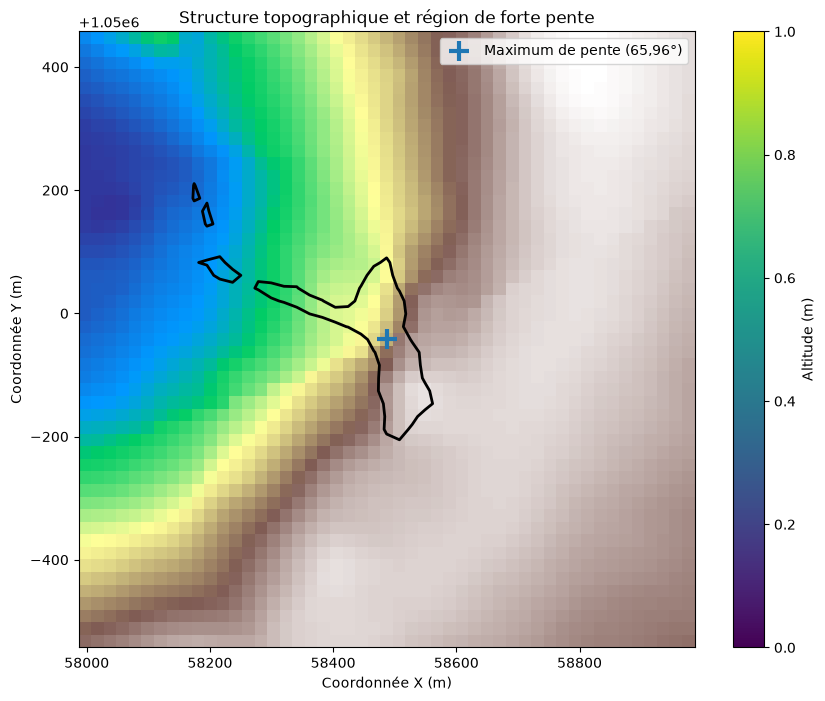

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import from_bounds

# Taille de la zone autour du maximum
rayon = 500

with rasterio.open(chemin_dem) as dem:

    # Extraire une zone de 1 km × 1 km
    fenetre = from_bounds(
        x_max - rayon,
        y_max - rayon,
        x_max + rayon,
        y_max + rayon,
        dem.transform
    )

    altitude_locale = dem.read(
        1,
        window=fenetre,
        masked=True
    )

    # Coordonnées de la fenêtre
    gauche, bas, droite, haut = rasterio.windows.bounds(
        fenetre,
        dem.transform
    )

# Créer le masque de pente ≥45° dans la même zone
ligne_debut = max(0, ligne_max - int(rayon / resolution_y))
ligne_fin = min(
    pente.shape[0],
    ligne_max + int(rayon / resolution_y) + 1
)

colonne_debut = max(0, colonne_max - int(rayon / resolution_x))
colonne_fin = min(
    pente.shape[1],
    colonne_max + int(rayon / resolution_x) + 1
)

pente_locale = pente.filled(np.nan)[
    ligne_debut:ligne_fin,
    colonne_debut:colonne_fin
]

# Affichage
plt.figure(figsize=(10, 8))

plt.imshow(
    altitude_locale,
    extent=[gauche, droite, bas, haut],
    cmap="terrain"
)

# Contour de la zone ≥45°
plt.contour(
    pente_locale,
    levels=[45],
    colors="black",
    linewidths=2,
    extent=[gauche, droite, bas, haut]
)

# Position du maximum
plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=200,
    linewidths=3,
    label="Maximum de pente (65,96°)"
)

plt.colorbar(label="Altitude (m)")
plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("Structure topographique et région de forte pente")
plt.legend()
plt.show()

In [34]:
# Distribution des altitudes dans l'ensemble du DEM

valeurs_altitude = altitude.compressed()

print("=== DISTRIBUTION DES ALTITUDES ===")

for limite in [-3200, -3150, -3100, -3050, -3000, -2950, -2900, -2850, -2800, -2750, -2700, -2650, -2600, -2550, -2500, -2450]:
    pourcentage = np.mean(valeurs_altitude >= limite) * 100

    print(
        f"Altitude ≥ {limite:5d} m : "
        f"{pourcentage:6.2f} % des pixels"
    )

print("\n=== STATISTIQUES ===")
print(f"Pixels analysés : {len(valeurs_altitude):,}")
print(f"Minimum : {np.min(valeurs_altitude):.2f} m")
print(f"Maximum : {np.max(valeurs_altitude):.2f} m")
print(f"Moyenne : {np.mean(valeurs_altitude):.2f} m")
print(f"Médiane : {np.median(valeurs_altitude):.2f} m")

=== DISTRIBUTION DES ALTITUDES ===
Altitude ≥ -3200 m : 100.00 % des pixels
Altitude ≥ -3150 m :  98.56 % des pixels
Altitude ≥ -3100 m :  84.05 % des pixels
Altitude ≥ -3050 m :  61.91 % des pixels
Altitude ≥ -3000 m :  44.55 % des pixels
Altitude ≥ -2950 m :  34.26 % des pixels
Altitude ≥ -2900 m :  25.93 % des pixels
Altitude ≥ -2850 m :  19.05 % des pixels
Altitude ≥ -2800 m :  10.99 % des pixels
Altitude ≥ -2750 m :   5.39 % des pixels
Altitude ≥ -2700 m :   2.29 % des pixels
Altitude ≥ -2650 m :   0.63 % des pixels
Altitude ≥ -2600 m :   0.13 % des pixels
Altitude ≥ -2550 m :   0.02 % des pixels
Altitude ≥ -2500 m :   0.01 % des pixels
Altitude ≥ -2450 m :   0.00 % des pixels

=== STATISTIQUES ===
Pixels analysés : 21,274,732
Minimum : -3239.99 m
Maximum : -2403.87 m
Moyenne : -2980.74 m
Médiane : -3018.20 m


In [35]:
# Relation entre altitude et pente

print("=== PENTE MOYENNE SELON L'ALTITUDE ===")

altitudes = altitude.filled(np.nan)
pentes = pente.filled(np.nan)

# Limites des classes d'altitude
classes_altitude = [
    (-3250, -3150),
    (-3150, -3050),
    (-3050, -2950),
    (-2950, -2850),
    (-2850, -2750),
    (-2750, -2650),
    (-2650, -2550),
    (-2550, -2400)
]

for bas, haut in classes_altitude:

    masque = (
        (altitudes >= bas)
        & (altitudes < haut)
        & ~np.isnan(pentes)
    )

    if np.any(masque):

        pente_moyenne = np.mean(pentes[masque])
        pente_mediane = np.median(pentes[masque])
        nombre = np.count_nonzero(masque)

        print(
            f"{bas:5d} à {haut:5d} m | "
            f"{nombre:,} pixels | "
            f"pente moyenne = {pente_moyenne:.2f}° | "
            f"médiane = {pente_mediane:.2f}°"
        )

=== PENTE MOYENNE SELON L'ALTITUDE ===
-3250 à -3150 m | 307,052 pixels | pente moyenne = 2.60° | médiane = 1.87°
-3150 à -3050 m | 7,791,434 pixels | pente moyenne = 2.34° | médiane = 1.81°
-3050 à -2950 m | 5,877,071 pixels | pente moyenne = 2.49° | médiane = 1.92°
-2950 à -2850 m | 3,232,144 pixels | pente moyenne = 2.62° | médiane = 1.93°
-2850 à -2750 m | 2,899,639 pixels | pente moyenne = 3.07° | médiane = 2.25°
-2750 à -2650 m | 1,010,955 pixels | pente moyenne = 4.53° | médiane = 3.43°
-2650 à -2550 m | 129,064 pixels | pente moyenne = 7.49° | médiane = 6.04°
-2550 à -2400 m | 4,569 pixels | pente moyenne = 11.01° | médiane = 9.70°


In [36]:
# Corrélation entre altitude et pente

altitudes = altitude.compressed()
pentes = pente.compressed()

# Les deux tableaux doivent utiliser exactement les mêmes pixels.
# On reconstruit donc un masque commun de valeurs valides.

altitudes_completes = altitude.filled(np.nan)
pentes_completes = pente.filled(np.nan)

masque_valide = (
    ~np.isnan(altitudes_completes)
    & ~np.isnan(pentes_completes)
)

altitudes_valides = altitudes_completes[masque_valide]
pentes_valides = pentes_completes[masque_valide]

correlation = np.corrcoef(
    altitudes_valides,
    pentes_valides
)[0, 1]

print("=== CORRÉLATION ENTRE ALTITUDE ET PENTE ===")
print(f"Nombre de pixels analysés : {len(altitudes_valides):,}")
print(f"Coefficient de corrélation : {correlation:.4f}")

=== CORRÉLATION ENTRE ALTITUDE ET PENTE ===
Nombre de pixels analysés : 21,251,928
Coefficient de corrélation : 0.1844


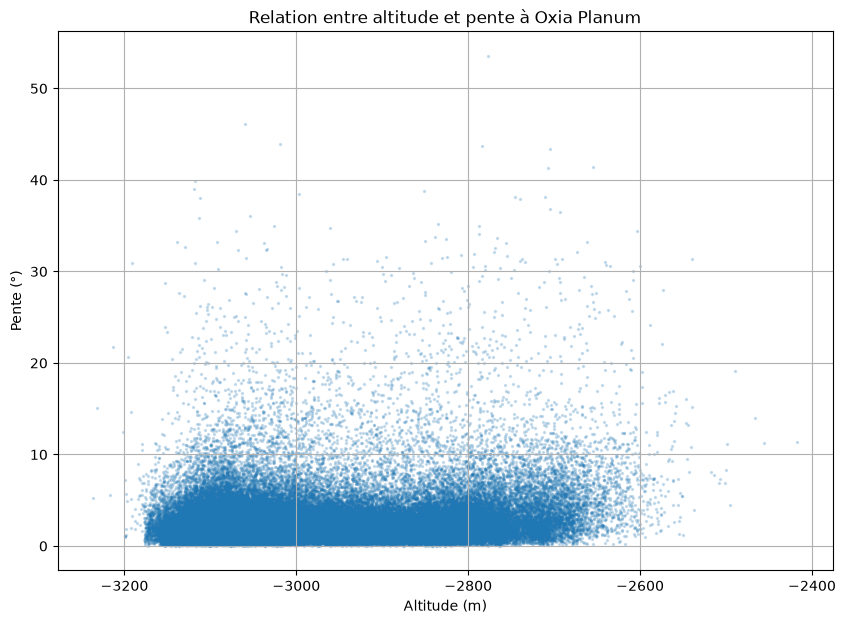

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage uniquement pour rendre le graphique lisible.
# La corrélation précédente a été calculée avec tous les pixels valides.

nombre_points = 100000

rng = np.random.default_rng(42)

indices = rng.choice(
    len(altitudes_valides),
    size=min(nombre_points, len(altitudes_valides)),
    replace=False
)

altitudes_graphique = altitudes_valides[indices]
pentes_graphique = pentes_valides[indices]

plt.figure(figsize=(10, 7))

plt.scatter(
    altitudes_graphique,
    pentes_graphique,
    s=2,
    alpha=0.2
)

plt.xlabel("Altitude (m)")
plt.ylabel("Pente (°)")
plt.title("Relation entre altitude et pente à Oxia Planum")
plt.grid(True)

plt.show()

In [38]:
import scipy

print("Version de SciPy :", scipy.__version__)

Version de SciPy : 1.18.1


In [39]:
import scipy

print("Version de SciPy :", scipy.__version__)

Version de SciPy : 1.18.1


In [40]:
from scipy import ndimage
import numpy as np

pente_array = pente.filled(np.nan)

print("=== RÉGIONS DE FORTE PENTE ===")

for seuil in [10, 20, 30, 45]:

    masque = (
        pente_array >= seuil
    )

    # Identification des régions contiguës
    etiquettes, nombre_regions = ndimage.label(masque)

    tailles = np.bincount(etiquettes.ravel())

    # On ignore la région 0, qui correspond aux pixels ne respectant pas le seuil
    tailles[0] = 0

    region_max = np.argmax(tailles)
    nombre_pixels = tailles[region_max]

    surface_pixel_m2 = resolution_x * resolution_y
    surface_km2 = nombre_pixels * surface_pixel_m2 / 1_000_000

    lignes, colonnes = np.where(
        etiquettes == region_max
    )

    x_min = colonnes.min() * resolution_x
    x_max_region = colonnes.max() * resolution_x

    y_min = lignes.min() * resolution_y
    y_max_region = lignes.max() * resolution_y

    largeur_x = (colonnes.max() - colonnes.min()) * resolution_x
    largeur_y = (lignes.max() - lignes.min()) * resolution_y

    print(f"\n--- Pente ≥ {seuil}° ---")
    print(f"Nombre total de régions : {nombre_regions:,}")
    print(f"Pixels dans la plus grande région : {nombre_pixels:,}")
    print(f"Surface approximative : {surface_km2:.4f} km²")
    print(f"Étendue X : {largeur_x:.1f} m")
    print(f"Étendue Y : {largeur_y:.1f} m")

=== RÉGIONS DE FORTE PENTE ===

--- Pente ≥ 10° ---
Nombre total de régions : 9,695
Pixels dans la plus grande région : 31,454
Surface approximative : 12.8779 km²
Étendue X : 4755.0 m
Étendue Y : 4370.6 m

--- Pente ≥ 20° ---
Nombre total de régions : 2,028
Pixels dans la plus grande région : 16,068
Surface approximative : 6.5786 km²
Étendue X : 3642.1 m
Étendue Y : 3885.0 m

--- Pente ≥ 30° ---
Nombre total de régions : 789
Pixels dans la plus grande région : 896
Surface approximative : 0.3668 km²
Étendue X : 1497.3 m
Étendue Y : 991.5 m

--- Pente ≥ 45° ---
Nombre total de régions : 107
Pixels dans la plus grande région : 62
Surface approximative : 0.0254 km²
Étendue X : 141.6 m
Étendue Y : 424.9 m


In [41]:
import matplotlib.pyplot as plt
import rasterio
from scipy import ndimage
import numpy as np

pente_array = pente.filled(np.nan)

# Création des masques pour différents seuils de pente
masque_10 = pente_array >= 10
masque_20 = pente_array >= 20
masque_30 = pente_array >= 30
masque_45 = pente_array >= 45

with rasterio.open(chemin_dem) as dem:
    
    emprise = rasterio.plot.plotting_extent(dem)

plt.figure(figsize=(12, 10))

# Fond : pente du terrain
plt.imshow(
    pente_array,
    extent=emprise,
    cmap="terrain"
)

# Contours des différentes classes de pente
plt.contour(
    masque_10,
    levels=[0.5],
    extent=emprise,
    linewidths=0.8
)

plt.contour(
    masque_20,
    levels=[0.5],
    extent=emprise,
    linewidths=1.0
)

plt.contour(
    masque_30,
    levels=[0.5],
    extent=emprise,
    linewidths=1.2
)

plt.contour(
    masque_45,
    levels=[0.5],
    extent=emprise,
    linewidths=1.5
)

# Localisation du maximum de pente
plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=250,
    linewidths=2,
    label="Pente maximale : 65,96°"
)

plt.colorbar(
    label="Pente (°)"
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("Distribution spatiale des zones de forte pente à Oxia Planum")
plt.legend()

plt.show()

AttributeError: module 'rasterio' has no attribute 'plot'

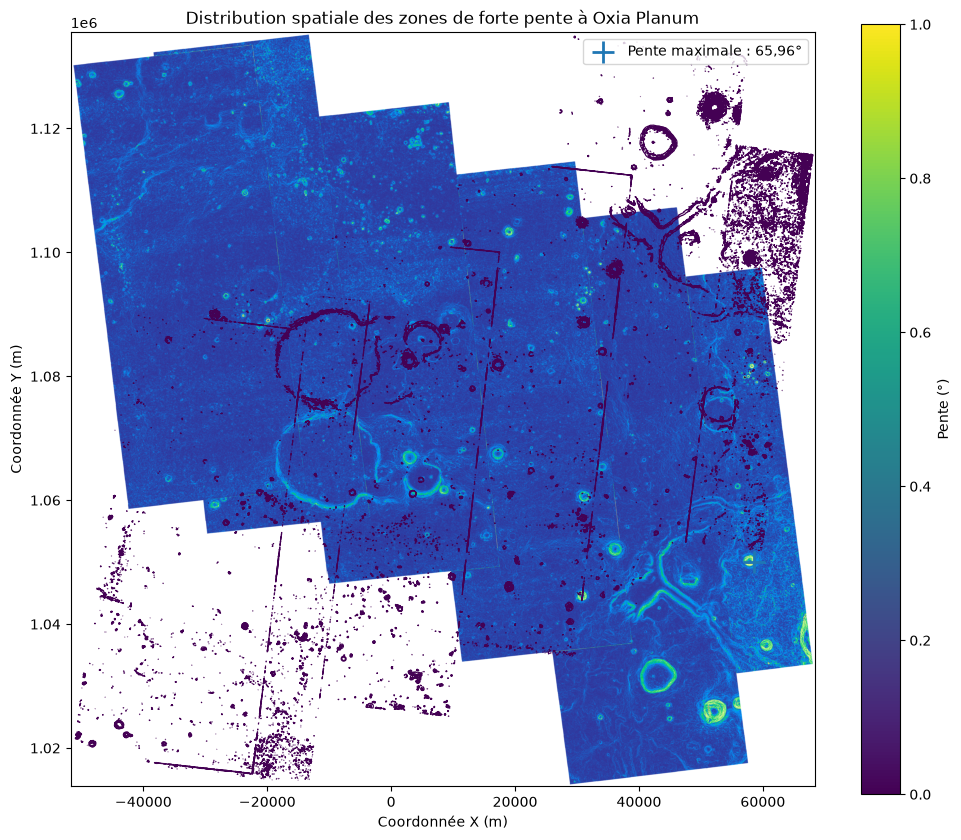

In [42]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent
import numpy as np

pente_array = pente.filled(np.nan)

# Création des masques pour différents seuils de pente
masque_10 = pente_array >= 10
masque_20 = pente_array >= 20
masque_30 = pente_array >= 30
masque_45 = pente_array >= 45

with rasterio.open(chemin_dem) as dem:
    emprise = plotting_extent(dem)

plt.figure(figsize=(12, 10))

# Fond : pente du terrain
plt.imshow(
    pente_array,
    extent=emprise,
    cmap="terrain"
)

# Contours des différentes classes de pente
plt.contour(
    masque_10,
    levels=[0.5],
    extent=emprise,
    linewidths=0.8
)

plt.contour(
    masque_20,
    levels=[0.5],
    extent=emprise,
    linewidths=1.0
)

plt.contour(
    masque_30,
    levels=[0.5],
    extent=emprise,
    linewidths=1.2
)

plt.contour(
    masque_45,
    levels=[0.5],
    extent=emprise,
    linewidths=1.5
)

# Localisation du maximum de pente
plt.scatter(
    x_max,
    y_max,
    marker="+",
    s=250,
    linewidths=2,
    label="Pente maximale : 65,96°"
)

plt.colorbar(label="Pente (°)")
plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title("Distribution spatiale des zones de forte pente à Oxia Planum")
plt.legend()

plt.show()

In [44]:
from scipy import ndimage
import numpy as np
import rasterio

pente_array = pente.filled(np.nan)

# Région correspondant à la pente maximale
masque_45 = pente_array >= 45

etiquettes, nombre_regions = ndimage.label(masque_45)

# Identifier la région contenant le maximum de pente
region_max = etiquettes[ligne_max, colonne_max]

masque_region = etiquettes == region_max

lignes, colonnes = np.where(masque_region)

surface_pixel_m2 = resolution_x * resolution_y
surface_km2 = len(lignes) * surface_pixel_m2 / 1_000_000

with rasterio.open(chemin_dem) as dem:

    # Coordonnées géographiques des limites
    x_gauche, y_haut = dem.xy(
        lignes.min(),
        colonnes.min()
    )

    x_droit, y_bas = dem.xy(
        lignes.max(),
        colonnes.max()
    )

    # Altitudes correspondant uniquement à cette région
    altitude_region = altitude.filled(np.nan)[masque_region]

print("=== CARACTÉRISATION DE LA RÉGION À FORTE PENTE ===")

print(f"Seuil étudié : ≥45°")
print(f"Nombre total de régions ≥45° : {nombre_regions:,}")
print(f"Pixels dans la région étudiée : {len(lignes):,}")
print(f"Surface approximative : {surface_km2:.4f} km²")

print(
    f"Étendue X : "
    f"{(colonnes.max() - colonnes.min()) * resolution_x:.1f} m"
)

print(
    f"Étendue Y : "
    f"{(lignes.max() - lignes.min()) * resolution_y:.1f} m"
)

print(f"Altitude minimale : {np.nanmin(altitude_region):.2f} m")
print(f"Altitude maximale : {np.nanmax(altitude_region):.2f} m")
print(f"Altitude moyenne : {np.nanmean(altitude_region):.2f} m")
print(f"Pente maximale : {np.nanmax(pente_array[masque_region]):.2f}°")
print(f"Pente moyenne : {np.nanmean(pente_array[masque_region]):.2f}°")

=== CARACTÉRISATION DE LA RÉGION À FORTE PENTE ===
Seuil étudié : ≥45°
Nombre total de régions ≥45° : 107
Pixels dans la région étudiée : 56
Surface approximative : 0.0229 km²
Étendue X : 263.0 m
Étendue Y : 263.0 m
Altitude minimale : -2834.88 m
Altitude maximale : -2662.82 m
Altitude moyenne : -2744.74 m
Pente maximale : 65.96°
Pente moyenne : 52.29°


In [45]:
=== CARACTÉRISATION DE LA RÉGION À FORTE PENTE ===
Seuil étudié : ≥45°
Nombre total de régions ≥45° : 107
Pixels dans la région étudiée : 56
Surface approximative : 0.0229 km²
Étendue X : 263.0 m
Étendue Y : 263.0 m
Altitude minimale : -2834.88 m
Altitude maximale : -2662.82 m
Altitude moyenne : -2744.74 m
Pente maximale : 65.96°
Pente moyenne : 52.29°

SyntaxError: invalid character '≥' (U+2265) (549202564.py, line 2)

In [46]:
  Cell In[45], line 2
    Seuil étudié : ≥45°
                   ^
SyntaxError: invalid character '≥' (U+2265)


IndentationError: unexpected indent (11391876.py, line 1)

In [47]:


import numpy as np
import rasterio
from rasterio.windows import from_bounds

rayon = 1000

with rasterio.open(chemin_dem) as dem:

    fenetre = from_bounds(
        x_max - rayon,
        y_max - rayon,
        x_max + rayon,
        y_max + rayon,
        dem.transform
    )

    pente_locale = pente_array[
        max(0, ligne_max - int(rayon / resolution_y)):
        min(dem.height, ligne_max + int(rayon / resolution_y) + 1),
        max(0, colonne_max - int(rayon / resolution_x)):
        min(dem.width, colonne_max + int(rayon / resolution_x) + 1)
    ]

valeurs = pente_locale[~np.isnan(pente_locale)]

print("=== ANALYSE DE L'ENVIRONNEMENT DE L'OBSTACLE ===")
print(f"Rayon étudié : {rayon} m")
print(
    f"Surface totale étudiée : "
    f"environ {(2 * rayon / 1000) ** 2:.1f} km²"
)
print()

for seuil in [5, 10, 20, 30, 45]:

    pourcentage = np.mean(valeurs >= seuil) * 100

    print(
        f"Pente >= {seuil:2d}° : "
        f"{pourcentage:.2f}% de la zone étudiée"
    )

print()
print(
    f"Pente moyenne autour de l'obstacle : "
    f"{np.mean(valeurs):.2f}°"
)
print(
    f"Pente médiane autour de l'obstacle : "
    f"{np.median(valeurs):.2f}°"
)

=== ANALYSE DE L'ENVIRONNEMENT DE L'OBSTACLE ===
Rayon étudié : 1000 m
Surface totale étudiée : environ 4.0 km²

Pente >=  5° : 84.57% de la zone étudiée
Pente >= 10° : 49.60% de la zone étudiée
Pente >= 20° : 29.24% de la zone étudiée
Pente >= 30° : 12.17% de la zone étudiée
Pente >= 45° : 0.70% de la zone étudiée

Pente moyenne autour de l'obstacle : 14.58°
Pente médiane autour de l'obstacle : 9.93°


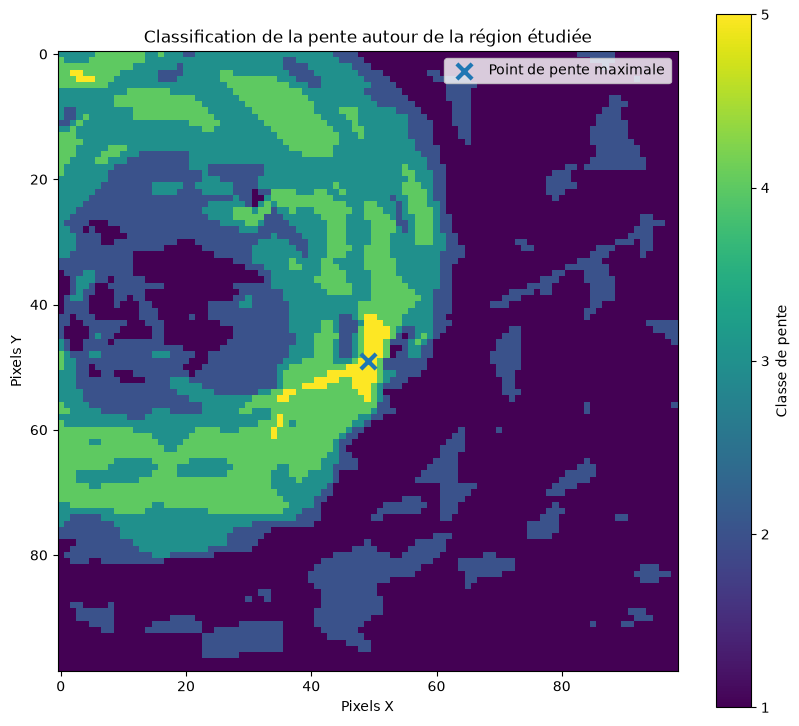

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Taille de la zone étudiée
rayon = 1000

# Extraction de la zone autour du point de pente maximale
ligne_centre = ligne_max
colonne_centre = colonne_max

pixels_y = int(rayon / resolution_y)
pixels_x = int(rayon / resolution_x)

ligne_debut = max(0, ligne_centre - pixels_y)
ligne_fin = min(pente_array.shape[0], ligne_centre + pixels_y + 1)

colonne_debut = max(0, colonne_centre - pixels_x)
colonne_fin = min(pente_array.shape[1], colonne_centre + pixels_x + 1)

pente_zone = pente_array[
    ligne_debut:ligne_fin,
    colonne_debut:colonne_fin
]

# Classification des pentes
classification = np.full(pente_zone.shape, np.nan)

classification[(pente_zone >= 0) & (pente_zone < 10)] = 1
classification[(pente_zone >= 10) & (pente_zone < 20)] = 2
classification[(pente_zone >= 20) & (pente_zone < 30)] = 3
classification[(pente_zone >= 30) & (pente_zone < 45)] = 4
classification[pente_zone >= 45] = 5

# Affichage
plt.figure(figsize=(10, 9))

image = plt.imshow(
    classification,
    origin="upper",
    interpolation="nearest"
)

plt.colorbar(
    image,
    ticks=[1, 2, 3, 4, 5],
    label="Classe de pente"
)

plt.title(
    "Classification de la pente autour de la région étudiée"
)

plt.xlabel("Pixels X")
plt.ylabel("Pixels Y")

plt.scatter(
    colonne_centre - colonne_debut,
    ligne_centre - ligne_debut,
    marker="x",
    s=120,
    linewidths=3,
    label="Point de pente maximale"
)

plt.legend()
plt.show()

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Nombre de directions étudiées
angles = np.arange(0, 360, 10)

# Distances étudiées depuis le point central
distances = np.arange(20, 1001, 20)

# Tableau pour stocker la pente moyenne rencontrée
pentes_radiales = np.zeros((len(angles), len(distances)))

for i, angle in enumerate(angles):

    angle_rad = np.radians(angle)

    for j, distance in enumerate(distances):

        dx = distance * np.cos(angle_rad)
        dy = distance * np.sin(angle_rad)

        colonne = int(round(colonne_max + dx / resolution_x))
        ligne = int(round(ligne_max - dy / resolution_y))

        if (
            0 <= ligne < pente_array.shape[0]
            and 0 <= colonne < pente_array.shape[1]
        ):
            pentes_radiales[i, j] = pente_array[ligne, colonne]
        else:
            pentes_radiales[i, j] = np.nan


# Distance à laquelle chaque direction repasse sous 10°
distance_sortie = []

for i, angle in enumerate(angles):

    profil = pentes_radiales[i]

    indices = np.where(profil < 10)[0]

    if len(indices) > 0:
        distance_sortie.append(distances[indices[0]])
    else:
        distance_sortie.append(np.nan)


print("=== ANALYSE DES CORRIDORS POTENTIELS ===")
print()

for angle, distance in zip(angles, distance_sortie):

    if np.isnan(distance):
        print(f"Direction {angle:3d}° : aucune pente <10° trouvée")
    else:
        print(
            f"Direction {angle:3d}° : "
            f"pente <10° retrouvée à environ {distance:.0f} m"
        )

print()
print(
    "Distance moyenne avant de retrouver une pente <10° : "
    f"{np.nanmean(distance_sortie):.1f} m"
)

=== ANALYSE DES CORRIDORS POTENTIELS ===

Direction   0° : pente <10° retrouvée à environ 200 m
Direction  10° : pente <10° retrouvée à environ 80 m
Direction  20° : pente <10° retrouvée à environ 80 m
Direction  30° : pente <10° retrouvée à environ 100 m
Direction  40° : pente <10° retrouvée à environ 360 m
Direction  50° : pente <10° retrouvée à environ 500 m
Direction  60° : pente <10° retrouvée à environ 560 m
Direction  70° : pente <10° retrouvée à environ 700 m
Direction  80° : pente <10° retrouvée à environ 860 m
Direction  90° : pente <10° retrouvée à environ 980 m
Direction 100° : aucune pente <10° trouvée
Direction 110° : aucune pente <10° trouvée
Direction 120° : aucune pente <10° trouvée
Direction 130° : aucune pente <10° trouvée
Direction 140° : aucune pente <10° trouvée
Direction 150° : pente <10° retrouvée à environ 520 m
Direction 160° : pente <10° retrouvée à environ 560 m
Direction 170° : pente <10° retrouvée à environ 460 m
Direction 180° : pente <10° retrouvée à env

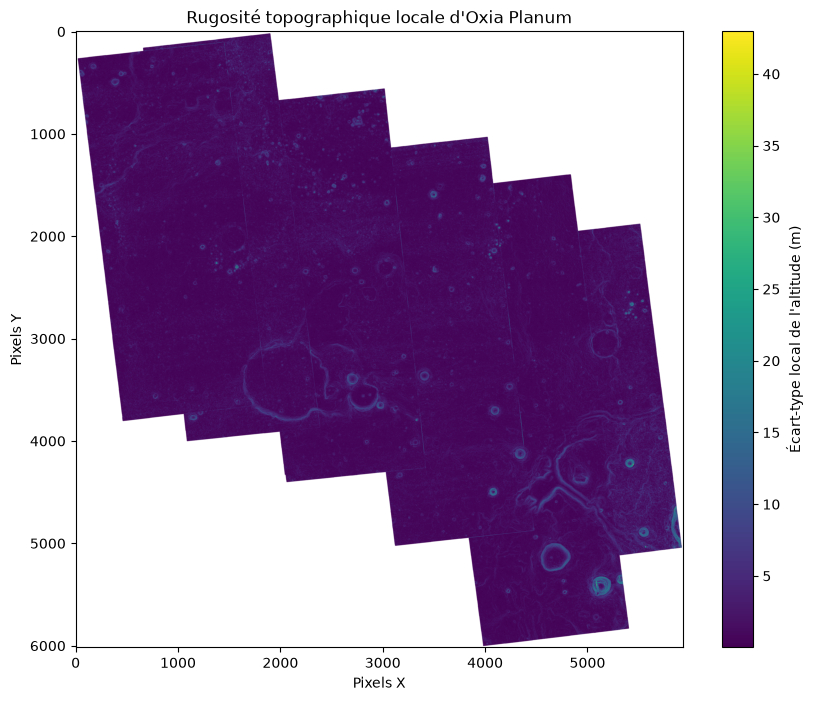

=== ANALYSE DE LA RUGOSITÉ ===
Fenêtre utilisée : 5 × 5 pixels
Taille approximative : 101.2 m

Rugosité minimale : 0.01 m
Rugosité maximale : 42.96 m
Rugosité moyenne : 1.31 m
Rugosité médiane : 0.96 m


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter

# Taille de la fenêtre locale
# 5 x 5 pixels ≈ 100 m x 100 m
taille_fenetre = 5

# Calcul de l'écart-type local de l'altitude
altitude_remplie = altitude.filled(np.nan)

def ecart_type_local(zone):
    valeurs = zone[~np.isnan(zone)]

    if len(valeurs) < 5:
        return np.nan

    return np.std(valeurs)

rugosite = generic_filter(
    altitude_remplie,
    ecart_type_local,
    size=taille_fenetre,
    mode="constant",
    cval=np.nan
)

# Affichage
plt.figure(figsize=(10, 8))

image = plt.imshow(
    rugosite,
    cmap="viridis",
    origin="upper"
)

plt.colorbar(
    image,
    label="Écart-type local de l'altitude (m)"
)

plt.title(
    "Rugosité topographique locale d'Oxia Planum"
)

plt.xlabel("Pixels X")
plt.ylabel("Pixels Y")

plt.show()

# Statistiques
valeurs_rugosite = rugosite[~np.isnan(rugosite)]

print("=== ANALYSE DE LA RUGOSITÉ ===")
print(f"Fenêtre utilisée : {taille_fenetre} × {taille_fenetre} pixels")
print(f"Taille approximative : {taille_fenetre * resolution_x:.1f} m")
print()
print(f"Rugosité minimale : {np.min(valeurs_rugosite):.2f} m")
print(f"Rugosité maximale : {np.max(valeurs_rugosite):.2f} m")
print(f"Rugosité moyenne : {np.mean(valeurs_rugosite):.2f} m")
print(f"Rugosité médiane : {np.median(valeurs_rugosite):.2f} m")

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

# ------------------------------------------------------------
# PARAMÈTRES
# ------------------------------------------------------------

taille_fenetre = 5

# ------------------------------------------------------------
# PRÉPARATION DU DEM
# ------------------------------------------------------------

z = altitude.filled(np.nan)

# Masque des valeurs valides
valide = np.isfinite(z)

# Remplacement temporaire des NaN
z_rempli = np.where(valide, z, 0.0)

# Nombre de pixels valides dans chaque fenêtre
compteur = uniform_filter(
    valide.astype(float),
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2

# Éviter les divisions par zéro
compteur = np.maximum(compteur, 1)

# ------------------------------------------------------------
# COORDONNÉES SPATIALES
# ------------------------------------------------------------

lignes, colonnes = np.indices(z.shape)

x = colonnes * resolution_x
y = lignes * resolution_y

# ------------------------------------------------------------
# MOYENNES LOCALES
# ------------------------------------------------------------

moy_z = uniform_filter(
    z_rempli,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

moy_x = uniform_filter(
    x * valide,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

moy_y = uniform_filter(
    y * valide,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

# ------------------------------------------------------------
# COVARIANCES LOCALES
# ------------------------------------------------------------

moy_xz = uniform_filter(
    x * z_rempli,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

moy_yz = uniform_filter(
    y * z_rempli,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

moy_xx = uniform_filter(
    x * x * valide,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

moy_yy = uniform_filter(
    y * y * valide,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

moy_zz = uniform_filter(
    z_rempli * z_rempli,
    size=taille_fenetre,
    mode="constant",
    cval=0
) * taille_fenetre**2 / compteur

cov_xz = moy_xz - moy_x * moy_z
cov_yz = moy_yz - moy_y * moy_z

var_x = moy_xx - moy_x * moy_x
var_y = moy_yy - moy_y * moy_y

var_z = moy_zz - moy_z * moy_z

# ------------------------------------------------------------
# AJUSTEMENT DU PLAN LOCAL
# ------------------------------------------------------------

var_x = np.maximum(var_x, 1e-12)
var_y = np.maximum(var_y, 1e-12)

a = cov_xz / var_x
b = cov_yz / var_y

# ------------------------------------------------------------
# VARIANCE DES RÉSIDUS
# ------------------------------------------------------------

var_residuelle = (
    var_z
    - (cov_xz**2 / var_x)
    - (cov_yz**2 / var_y)
)

var_residuelle = np.maximum(var_residuelle, 0)

rugosite_detrendee = np.sqrt(var_residuelle)

# Élimination des zones insuffisamment couvertes
rugosite_detrendee[compteur < 20] = np.nan

# ------------------------------------------------------------
# STATISTIQUES
# ------------------------------------------------------------

valeurs = rugosite_detrendee[
    np.isfinite(rugosite_detrendee)
]

print("=== RUGOSITÉ TOPOGRAPHIQUE DÉTRENDEE ===")
print(
    f"Fenêtre : {taille_fenetre} × {taille_fenetre} pixels"
)
print(
    f"Échelle spatiale : "
    f"{taille_fenetre * resolution_x:.1f} m"
)
print()

print(
    f"Minimum : {np.min(valeurs):.3f} m"
)
print(
    f"Maximum : {np.max(valeurs):.3f} m"
)
print(
    f"Moyenne : {np.mean(valeurs):.3f} m"
)
print(
    f"Médiane : {np.median(valeurs):.3f} m"
)

for percentile in [75, 90, 95, 99]:
    print(
        f"Percentile {percentile} : "
        f"{np.percentile(valeurs, percentile):.3f} m"
    )

# ------------------------------------------------------------
# CARTE
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

image = plt.imshow(
    rugosite_detrendee,
    origin="upper",
    interpolation="nearest"
)

plt.colorbar(
    image,
    label="Écart-type des résidus topographiques (m)"
)

plt.title(
    "Rugosité topographique locale après retrait du plan"
)

plt.xlabel("Pixels X")
plt.ylabel("Pixels Y")

plt.show()

=== RUGOSITÉ TOPOGRAPHIQUE DÉTRENDEE ===
Fenêtre : 5 × 5 pixels
Échelle spatiale : 101.2 m

Minimum : 0.000 m
Maximum : 18.858 m
Moyenne : 0.472 m
Médiane : 0.333 m
Percentile 75 : 0.838 m
Percentile 90 : 1.175 m
Percentile 95 : 1.402 m
Percentile 99 : 2.170 m


MemoryError: Unable to allocate 1.06 GiB for an array with shape (6018, 5935, 4) and data type float64

<Figure size 1000x800 with 2 Axes>

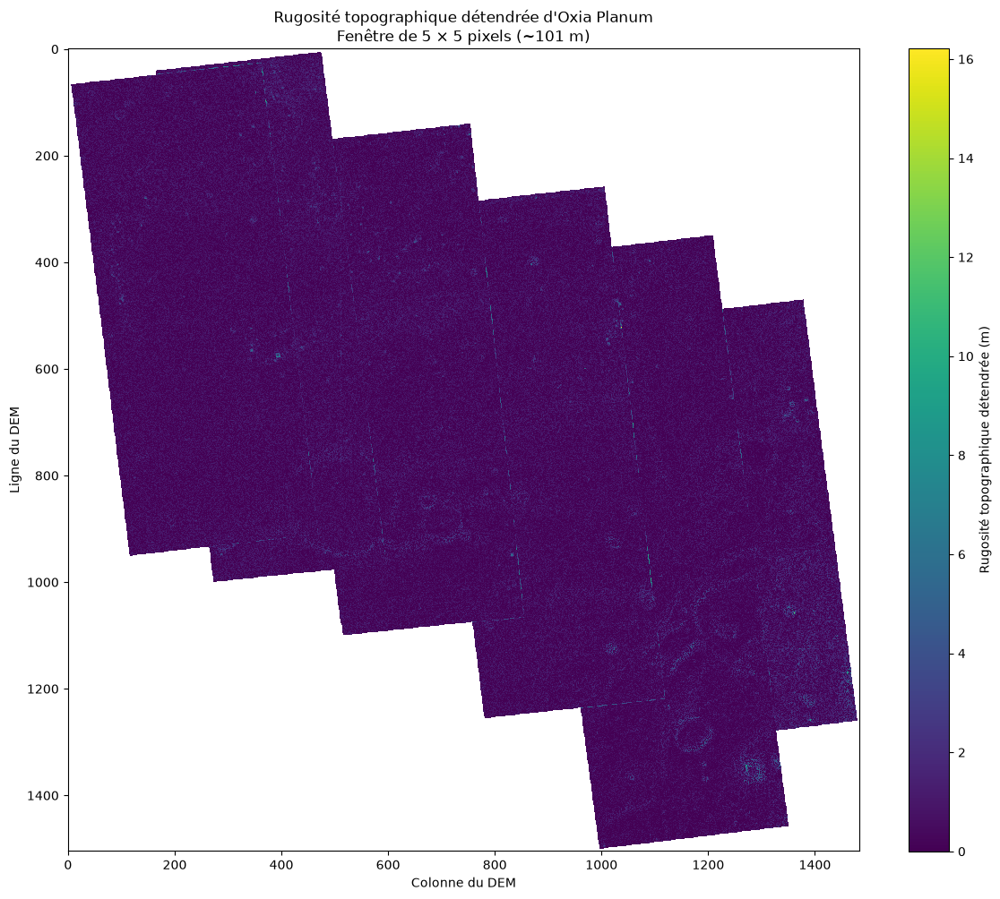

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# AFFICHAGE OPTIMISÉ DE LA RUGOSITÉ DÉTRENDEE
# ------------------------------------------------------------

facteur = 4

# Réduction uniquement pour l'affichage
rugosite_affichage = rugosite_detrendee[::facteur, ::facteur]

plt.figure(figsize=(12, 10))

plt.imshow(
    rugosite_affichage,
    cmap="viridis",
    interpolation="nearest"
)

plt.colorbar(
    label="Rugosité topographique détendrée (m)"
)

plt.title(
    "Rugosité topographique détendrée d'Oxia Planum\n"
    "Fenêtre de 5 × 5 pixels (~101 m)"
)

plt.xlabel("Colonne du DEM")
plt.ylabel("Ligne du DEM")

plt.tight_layout()
plt.show()

=== CLASSIFICATION PENTE + RUGOSITÉ ===
Pixels valides : 21,243,496

Classe 1 : 20,617,803 pixels (97.05 %)
Classe 2 : 346,862 pixels (1.63 %)
Classe 3 : 141,347 pixels (0.67 %)
Classe 4 : 137,484 pixels (0.65 %)


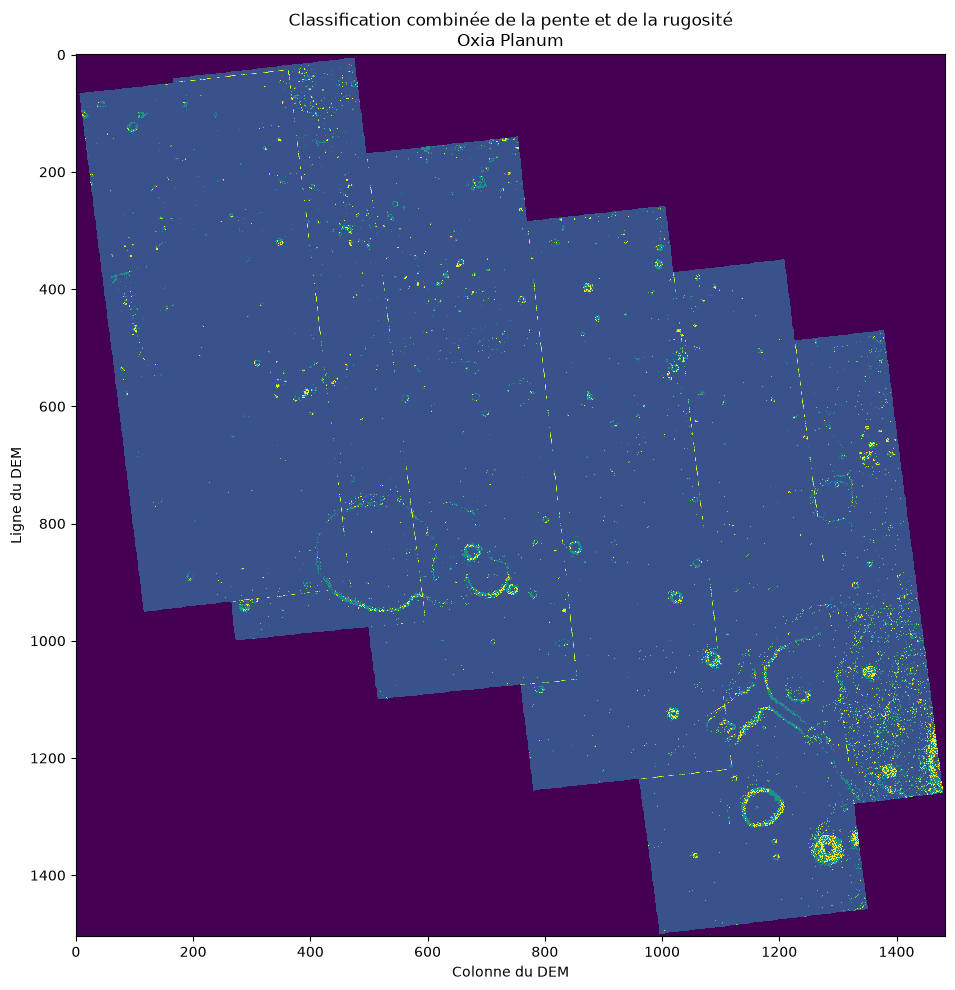

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# CLASSIFICATION COMBINÉE : PENTE + RUGOSITÉ
# ------------------------------------------------------------

# Seuils analytiques
seuil_pente = 10.0
seuil_rugosite = 2.0

# 0 = données invalides
# 1 = faible pente / faible rugosité
# 2 = forte pente / faible rugosité
# 3 = faible pente / forte rugosité
# 4 = forte pente / forte rugosité

classification = np.zeros_like(pente_array, dtype=np.uint8)

valide = (
    np.isfinite(pente_array)
    & np.isfinite(rugosite_detrendee)
)

classification[
    valide
    & (pente_array < seuil_pente)
    & (rugosite_detrendee < seuil_rugosite)
] = 1

classification[
    valide
    & (pente_array >= seuil_pente)
    & (rugosite_detrendee < seuil_rugosite)
] = 2

classification[
    valide
    & (pente_array < seuil_pente)
    & (rugosite_detrendee >= seuil_rugosite)
] = 3

classification[
    valide
    & (pente_array >= seuil_pente)
    & (rugosite_detrendee >= seuil_rugosite)
] = 4

# Pourcentage de chaque classe
total = np.sum(classification > 0)

print("=== CLASSIFICATION PENTE + RUGOSITÉ ===")
print(f"Pixels valides : {total:,}")
print()

for classe in range(1, 5):
    nombre = np.sum(classification == classe)
    pourcentage = nombre / total * 100

    print(
        f"Classe {classe} : "
        f"{nombre:,} pixels "
        f"({pourcentage:.2f} %)"
    )

# Affichage optimisé
facteur = 4

classification_affichage = classification[::facteur, ::facteur]

plt.figure(figsize=(12, 10))

plt.imshow(
    classification_affichage,
    interpolation="nearest"
)

plt.title(
    "Classification combinée de la pente et de la rugosité\n"
    "Oxia Planum"
)

plt.xlabel("Colonne du DEM")
plt.ylabel("Ligne du DEM")

plt.tight_layout()
plt.show()

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Masques de validité
valide = (
    ~np.isnan(pente_array)
    & ~np.isnan(rugosite_detrendee)
)

# Classification indépendante des deux paramètres
# Ces seuils sont des catégories analytiques choisies pour l'étude,
# et ne représentent PAS des limites officielles du rover.

classe_pente = np.full(pente_array.shape, np.nan)
classe_rugosite = np.full(rugosite_detrendee.shape, np.nan)

classe_pente[valide & (pente_array < 10)] = 1
classe_pente[valide & (pente_array >= 10) & (pente_array < 20)] = 2
classe_pente[valide & (pente_array >= 20) & (pente_array < 30)] = 3
classe_pente[valide & (pente_array >= 30) & (pente_array < 45)] = 4
classe_pente[valide & (pente_array >= 45)] = 5

classe_rugosite[valide & (rugosite_detrendee < 0.5)] = 1
classe_rugosite[valide & (rugosite_detrendee >= 0.5) & (rugosite_detrendee < 1)] = 2
classe_rugosite[valide & (rugosite_detrendee >= 1) & (rugosite_detrendee < 2)] = 3
classe_rugosite[valide & (rugosite_detrendee >= 2) & (rugosite_detrendee < 5)] = 4
classe_rugosite[valide & (rugosite_detrendee >= 5)] = 5

# Indice combiné : on conserve volontairement les deux dimensions
# plutôt que d'imposer immédiatement une pondération arbitraire.
difficulte_topographique = classe_pente + classe_rugosite

print("=== DIFFICULTÉ TOPOGRAPHIQUE ===")
print("Pixels valides :", np.sum(valide))
print()
print("Classes de pente :")
for i in range(1, 6):
    print(f"  Classe {i} :", np.sum(classe_pente == i), "pixels")

print()
print("Classes de rugosité :")
for i in range(1, 6):
    print(f"  Classe {i} :", np.sum(classe_rugosite == i), "pixels")

print()
print(
    "Indice combiné : de 2 (terrain relativement simple) "
    "à 10 (terrain fortement complexe)"
)

=== DIFFICULTÉ TOPOGRAPHIQUE ===
Pixels valides : 21243496

Classes de pente :
  Classe 1 : 20759150 pixels
  Classe 2 : 401679 pixels
  Classe 3 : 68325 pixels
  Classe 4 : 13717 pixels
  Classe 5 : 625 pixels

Classes de rugosité :
  Classe 1 : 12008298 pixels
  Classe 2 : 5691108 pixels
  Classe 3 : 3265259 pixels
  Classe 4 : 265156 pixels
  Classe 5 : 13675 pixels

Indice combiné : de 2 (terrain relativement simple) à 10 (terrain fortement complexe)


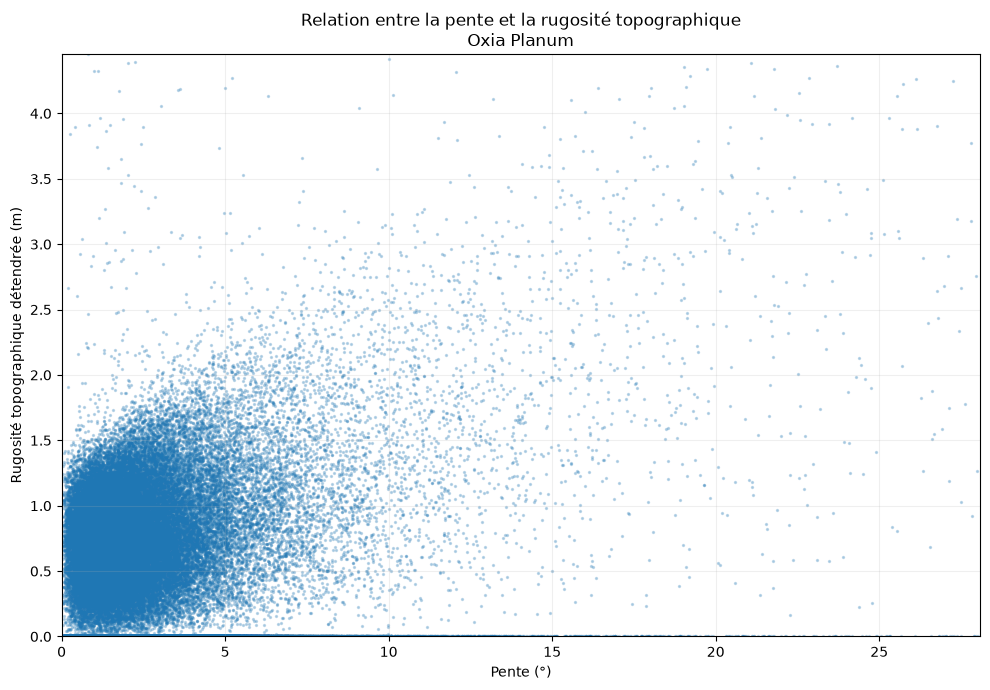

=== RELATION PENTE / RUGOSITÉ ===
Pixels valides : 21243496
Points affichés : 100000
Pente médiane : 1.97°
Rugosité médiane : 0.333 m


In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Sélection des pixels valides
indices_valides = (
    ~np.isnan(pente_array)
    & ~np.isnan(rugosite_detrendee)
)

pentes = pente_array[indices_valides]
rugosites = rugosite_detrendee[indices_valides]

# Pour garder le graphique lisible, on utilise un échantillon aléatoire.
# Les statistiques précédentes restent calculées sur tous les pixels.
rng = np.random.default_rng(42)

nombre_points = min(100000, len(pentes))
indices = rng.choice(len(pentes), nombre_points, replace=False)

pentes_echantillon = pentes[indices]
rugosites_echantillon = rugosites[indices]

plt.figure(figsize=(10, 7))

plt.scatter(
    pentes_echantillon,
    rugosites_echantillon,
    s=2,
    alpha=0.25
)

plt.xlabel("Pente (°)")
plt.ylabel("Rugosité topographique détendrée (m)")
plt.title(
    "Relation entre la pente et la rugosité topographique\n"
    "Oxia Planum"
)

plt.xlim(0, np.percentile(pentes, 99.9))
plt.ylim(0, np.percentile(rugosites, 99.9))

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("=== RELATION PENTE / RUGOSITÉ ===")
print("Pixels valides :", len(pentes))
print("Points affichés :", nombre_points)
print(f"Pente médiane : {np.median(pentes):.2f}°")
print(f"Rugosité médiane : {np.median(rugosites):.3f} m")

In [56]:
# Analyse quantitative de la relation pente / rugosité

print("=== ANALYSE QUANTITATIVE PENTE / RUGOSITÉ ===")

# Corrélation de Pearson
correlation = np.corrcoef(pentes, rugosites)[0, 1]

print(f"Corrélation de Pearson : r = {correlation:.4f}")
print()

print("=== STATISTIQUES DE PENTE ===")
for percentile in [25, 50, 75, 90, 95, 99]:
    print(
        f"Percentile {percentile:2d} : "
        f"{np.percentile(pentes, percentile):.3f}°"
    )

print()
print("=== STATISTIQUES DE RUGOSITÉ ===")
for percentile in [25, 50, 75, 90, 95, 99]:
    print(
        f"Percentile {percentile:2d} : "
        f"{np.percentile(rugosites, percentile):.3f} m"
    )

print()
print("=== COMBINAISONS PENTE / RUGOSITÉ ===")

combinaisons = {
    "Pente <10° + rugosité <2 m":
        (pentes < 10) & (rugosites < 2),

    "Pente >=10° + rugosité <2 m":
        (pentes >= 10) & (rugosites < 2),

    "Pente <10° + rugosité >=2 m":
        (pentes < 10) & (rugosites >= 2),

    "Pente >=10° + rugosité >=2 m":
        (pentes >= 10) & (rugosites >= 2),
}

total = len(pentes)

for nom, masque in combinaisons.items():
    nombre = np.sum(masque)
    pourcentage = nombre / total * 100

    print(
        f"{nom} : "
        f"{nombre:,} pixels "
        f"({pourcentage:.3f}%)"
    )

print()
print("=== VALEURS EXTRÊMES ===")
print(f"Pente maximale : {np.max(pentes):.3f}°")
print(f"Rugosité maximale : {np.max(rugosites):.3f} m")

=== ANALYSE QUANTITATIVE PENTE / RUGOSITÉ ===
Corrélation de Pearson : r = 0.3167

=== STATISTIQUES DE PENTE ===
Percentile 25 : 1.181°
Percentile 50 : 1.969°
Percentile 75 : 3.180°
Percentile 90 : 5.073°
Percentile 95 : 7.032°
Percentile 99 : 14.109°

=== STATISTIQUES DE RUGOSITÉ ===
Percentile 25 : 0.000 m
Percentile 50 : 0.333 m
Percentile 75 : 0.838 m
Percentile 90 : 1.175 m
Percentile 95 : 1.402 m
Percentile 99 : 2.170 m

=== COMBINAISONS PENTE / RUGOSITÉ ===
Pente <10° + rugosité <2 m : 20,617,803 pixels (97.055%)
Pente >=10° + rugosité <2 m : 346,862 pixels (1.633%)
Pente <10° + rugosité >=2 m : 141,347 pixels (0.665%)
Pente >=10° + rugosité >=2 m : 137,484 pixels (0.647%)

=== VALEURS EXTRÊMES ===
Pente maximale : 65.962°
Rugosité maximale : 18.858 m


In [57]:
v

NameError: name 'v' is not defined

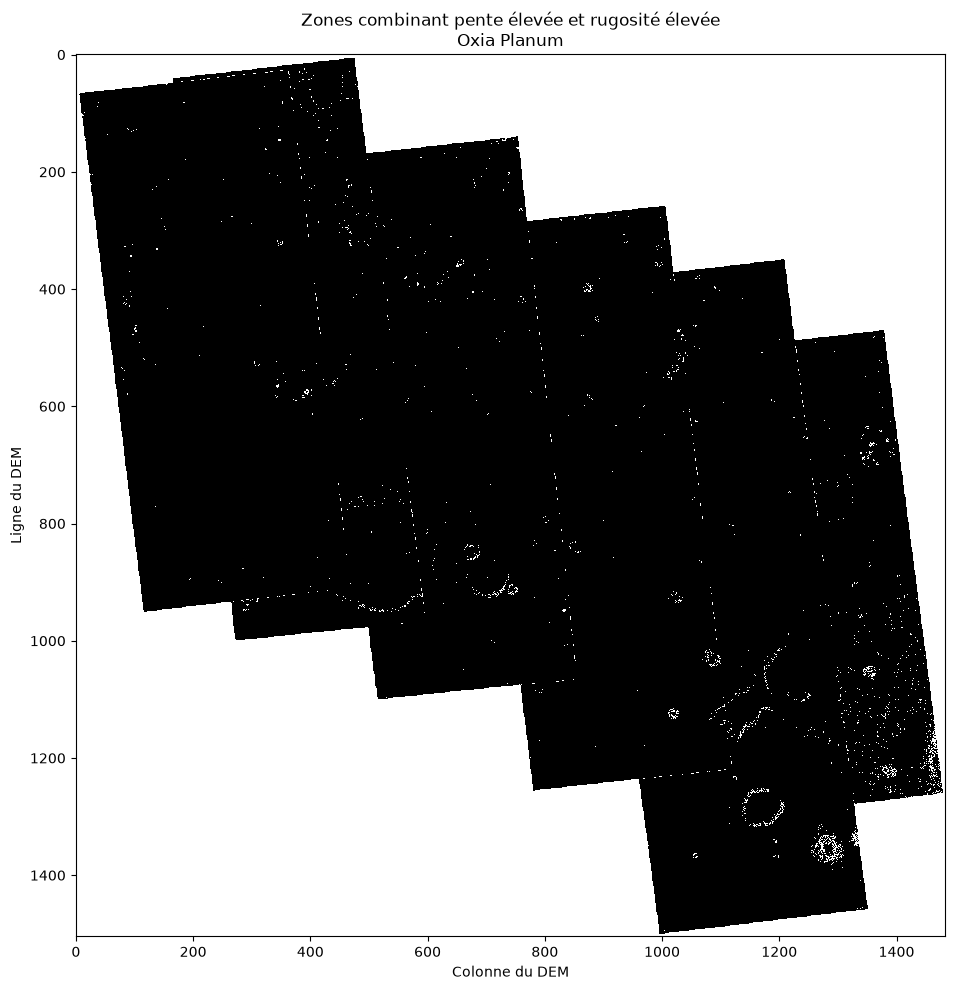

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Zone répondant simultanément aux deux critères
zone_complexe = (
    (pente_array >= 10)
    & (rugosite_detrendee >= 2)
)

# Masquer les pixels invalides
zone_complexe = np.where(valide, zone_complexe, np.nan)

# Affichage uniquement : réduction pour éviter une consommation excessive de mémoire
facteur = 4
zone_affichage = zone_complexe[::facteur, ::facteur]

plt.figure(figsize=(12, 10))

plt.imshow(
    zone_affichage,
    cmap="gray",
    interpolation="nearest"
)

plt.title(
    "Zones combinant pente élevée et rugosité élevée\n"
    "Oxia Planum"
)

plt.xlabel("Colonne du DEM")
plt.ylabel("Ligne du DEM")

plt.tight_layout()
plt.show()

In [59]:
from scipy import ndimage

# Connexité 8-voisins : les cellules qui se touchent par un côté
# ou une diagonale appartiennent au même secteur.
structure = np.ones((3, 3), dtype=int)

etiquettes, nombre_regions = ndimage.label(
    zone_complexe.astype(bool),
    structure=structure
)

print("=== ZONES À FORTE COMPLEXITÉ TOPOGRAPHIQUE ===")

nombre_pixels = np.sum(zone_complexe == True)

surface_pixel_km2 = (
    resolution_x * resolution_y
) / 1_000_000

surface_totale_km2 = nombre_pixels * surface_pixel_km2

print(f"Pixels concernés : {nombre_pixels:,}")
print(f"Surface totale : {surface_totale_km2:.4f} km²")
print(f"Nombre de régions connectées : {nombre_regions}")

# Taille des régions
tailles = np.bincount(etiquettes.ravel())

# On ignore le label 0 = arrière-plan
tailles_regions = tailles[1:]

if len(tailles_regions) > 0:

    ordre = np.argsort(tailles_regions)[::-1]

    print()
    print("=== 10 PLUS GRANDES RÉGIONS ===")

    for rang, indice in enumerate(ordre[:10], start=1):

        pixels_region = tailles_regions[indice]
        surface_region = pixels_region * surface_pixel_km2

        print(
            f"{rang:2d}. "
            f"{pixels_region:,} pixels | "
            f"{surface_region:.4f} km²"
        )

=== ZONES À FORTE COMPLEXITÉ TOPOGRAPHIQUE ===
Pixels concernés : 137,484
Surface totale : 56.2886 km²
Nombre de régions connectées : 21179

=== 10 PLUS GRANDES RÉGIONS ===
 1. 14,481,985 pixels | 5929.2076 km²
 2. 8,037 pixels | 3.2905 km²
 3. 2,177 pixels | 0.8913 km²
 4. 1,986 pixels | 0.8131 km²
 5. 1,105 pixels | 0.4524 km²
 6. 1,049 pixels | 0.4295 km²
 7. 734 pixels | 0.3005 km²
 8. 725 pixels | 0.2968 km²
 9. 709 pixels | 0.2903 km²
10. 650 pixels | 0.2661 km²


In [60]:
from scipy import ndimage
import numpy as np

# Masque booléen strict :
# True = cellule valide ET répondant aux deux critères
zone_complexe_bool = (
    valide
    & (pente_array >= 10)
    & (rugosite_detrendee >= 2)
)

# Connexité 8-voisins
structure = np.ones((3, 3), dtype=int)

etiquettes, nombre_regions = ndimage.label(
    zone_complexe_bool,
    structure=structure
)

nombre_pixels = np.sum(zone_complexe_bool)

surface_pixel_km2 = (
    resolution_x * resolution_y
) / 1_000_000

surface_totale_km2 = nombre_pixels * surface_pixel_km2

print("=== ZONES À FORTE COMPLEXITÉ TOPOGRAPHIQUE ===")
print(f"Pixels concernés : {nombre_pixels:,}")
print(f"Surface totale : {surface_totale_km2:.4f} km²")
print(f"Nombre de régions connectées : {nombre_regions}")

tailles = np.bincount(etiquettes.ravel())
tailles_regions = tailles[1:]

print()
print("=== 10 PLUS GRANDES RÉGIONS ===")

if len(tailles_regions) > 0:

    ordre = np.argsort(tailles_regions)[::-1]

    for rang, indice in enumerate(ordre[:10], start=1):

        pixels_region = tailles_regions[indice]
        surface_region = pixels_region * surface_pixel_km2

        print(
            f"{rang:2d}. "
            f"{pixels_region:,} pixels | "
            f"{surface_region:.4f} km²"
        )

=== ZONES À FORTE COMPLEXITÉ TOPOGRAPHIQUE ===
Pixels concernés : 137,484
Surface totale : 56.2886 km²
Nombre de régions connectées : 21305

=== 10 PLUS GRANDES RÉGIONS ===
 1. 8,037 pixels | 3.2905 km²
 2. 2,381 pixels | 0.9748 km²
 3. 2,177 pixels | 0.8913 km²
 4. 1,986 pixels | 0.8131 km²
 5. 1,595 pixels | 0.6530 km²
 6. 1,105 pixels | 0.4524 km²
 7. 1,049 pixels | 0.4295 km²
 8. 969 pixels | 0.3967 km²
 9. 734 pixels | 0.3005 km²
10. 725 pixels | 0.2968 km²


In [61]:
import numpy as np
import rasterio

# Identifier la plus grande région
tailles = np.bincount(etiquettes.ravel())
tailles_regions = tailles[1:]

indice_plus_grande = np.argmax(tailles_regions) + 1
pixels_plus_grande = tailles_regions[indice_plus_grande - 1]

# Coordonnées des pixels appartenant à cette région
lignes, colonnes = np.where(etiquettes == indice_plus_grande)

# Dimensions de la région
ligne_min, ligne_max = lignes.min(), lignes.max()
colonne_min, colonne_max = colonnes.min(), colonnes.max()

# Coordonnées géographiques des extrémités
with rasterio.open(chemin_dem) as dem:
    x_gauche, y_haut = dem.transform * (colonne_min, ligne_min)
    x_droite, y_bas = dem.transform * (colonne_max, ligne_max)

    # Coordonnées de chaque pixel de la région
    xs, ys = rasterio.transform.xy(
        dem.transform,
        lignes,
        colonnes
    )

xs = np.array(xs)
ys = np.array(ys)

# Valeurs des différentes données dans cette région
altitudes_region = altitude.data[etiquettes == indice_plus_grande]
pentes_region = pente_array[etiquettes == indice_plus_grande]
rugosite_region = rugosite_detrendee[etiquettes == indice_plus_grande]

surface_pixel_km2 = (resolution_x * resolution_y) / 1_000_000
surface_region_km2 = pixels_plus_grande * surface_pixel_km2

largeur_m = (colonne_max - colonne_min + 1) * resolution_x
hauteur_m = (ligne_max - ligne_min + 1) * resolution_y

print("=== PLUS GRANDE ZONE DE COMPLEXITÉ TOPOGRAPHIQUE ===")
print(f"Pixels : {pixels_plus_grande:,}")
print(f"Surface : {surface_region_km2:.4f} km²")
print()

print("=== DIMENSIONS ===")
print(f"Largeur : {largeur_m:.1f} m")
print(f"Hauteur : {hauteur_m:.1f} m")
print()

print("=== COORDONNÉES ===")
print(f"X min : {x_gauche:.2f} m")
print(f"X max : {x_droite:.2f} m")
print(f"Y max : {y_haut:.2f} m")
print(f"Y min : {y_bas:.2f} m")
print(f"Centre X : {xs.mean():.2f} m")
print(f"Centre Y : {ys.mean():.2f} m")
print()

print("=== ALTITUDE ===")
print(f"Minimum : {altitudes_region.min():.2f} m")
print(f"Maximum : {altitudes_region.max():.2f} m")
print(f"Moyenne : {altitudes_region.mean():.2f} m")
print(f"Relief : {altitudes_region.max() - altitudes_region.min():.2f} m")
print()

print("=== PENTE ===")
print(f"Minimum : {pentes_region.min():.2f}°")
print(f"Maximum : {pentes_region.max():.2f}°")
print(f"Moyenne : {pentes_region.mean():.2f}°")
print(f"Médiane : {np.median(pentes_region):.2f}°")
print()

print("=== RUGOSITÉ DÉTRENDEE ===")
print(f"Minimum : {rugosite_region.min():.3f} m")
print(f"Maximum : {rugosite_region.max():.3f} m")
print(f"Moyenne : {rugosite_region.mean():.3f} m")
print(f"Médiane : {np.median(rugosite_region):.3f} m")

=== PLUS GRANDE ZONE DE COMPLEXITÉ TOPOGRAPHIQUE ===
Pixels : 8,037
Surface : 3.2905 km²

=== DIMENSIONS ===
Largeur : 3682.6 m
Hauteur : 3763.5 m

=== COORDONNÉES ===
X min : 50443.75 m
X max : 54106.12 m
Y max : 1027892.26 m
Y min : 1024148.94 m
Centre X : 52236.54 m
Centre Y : 1026155.40 m

=== ALTITUDE ===
Minimum : -3185.13 m
Maximum : -2584.10 m
Moyenne : -2887.43 m
Relief : 601.04 m

=== PENTE ===
Minimum : 10.00°
Maximum : 61.27°
Moyenne : 24.79°
Médiane : 24.36°

=== RUGOSITÉ DÉTRENDEE ===
Minimum : 2.000 m
Maximum : 12.315 m
Moyenne : 3.733 m
Médiane : 3.495 m


In [62]:
print("=== RÉSUMÉ POUR LE RAPPORT ===")
print(
    f"La plus grande région répondant simultanément aux critères "
    f"de pente ≥10° et de rugosité détendrée ≥2 m couvre "
    f"{surface_region_km2:.2f} km²."
)

print(
    f"Elle s'étend sur environ {largeur_m:.0f} m × "
    f"{hauteur_m:.0f} m."
)

print(
    f"Son altitude varie de {altitudes_region.min():.1f} m à "
    f"{altitudes_region.max():.1f} m, soit un relief interne "
    f"d'environ {altitudes_region.max() - altitudes_region.min():.1f} m."
)

print(
    f"La pente moyenne y est de {pentes_region.mean():.1f}°, "
    f"avec un maximum de {pentes_region.max():.1f}°."
)

print(
    f"La rugosité topographique détendrée moyenne est de "
    f"{rugosite_region.mean():.2f} m."
)

print(
    f"Son centre se situe approximativement aux coordonnées "
    f"X = {xs.mean():.0f} m, Y = {ys.mean():.0f} m "
    f"dans le système de coordonnées du DEM."
)

=== RÉSUMÉ POUR LE RAPPORT ===
La plus grande région répondant simultanément aux critères de pente ≥10° et de rugosité détendrée ≥2 m couvre 3.29 km².
Elle s'étend sur environ 3683 m × 3764 m.
Son altitude varie de -3185.1 m à -2584.1 m, soit un relief interne d'environ 601.0 m.
La pente moyenne y est de 24.8°, avec un maximum de 61.3°.
La rugosité topographique détendrée moyenne est de 3.73 m.
Son centre se situe approximativement aux coordonnées X = 52237 m, Y = 1026155 m dans le système de coordonnées du DEM.


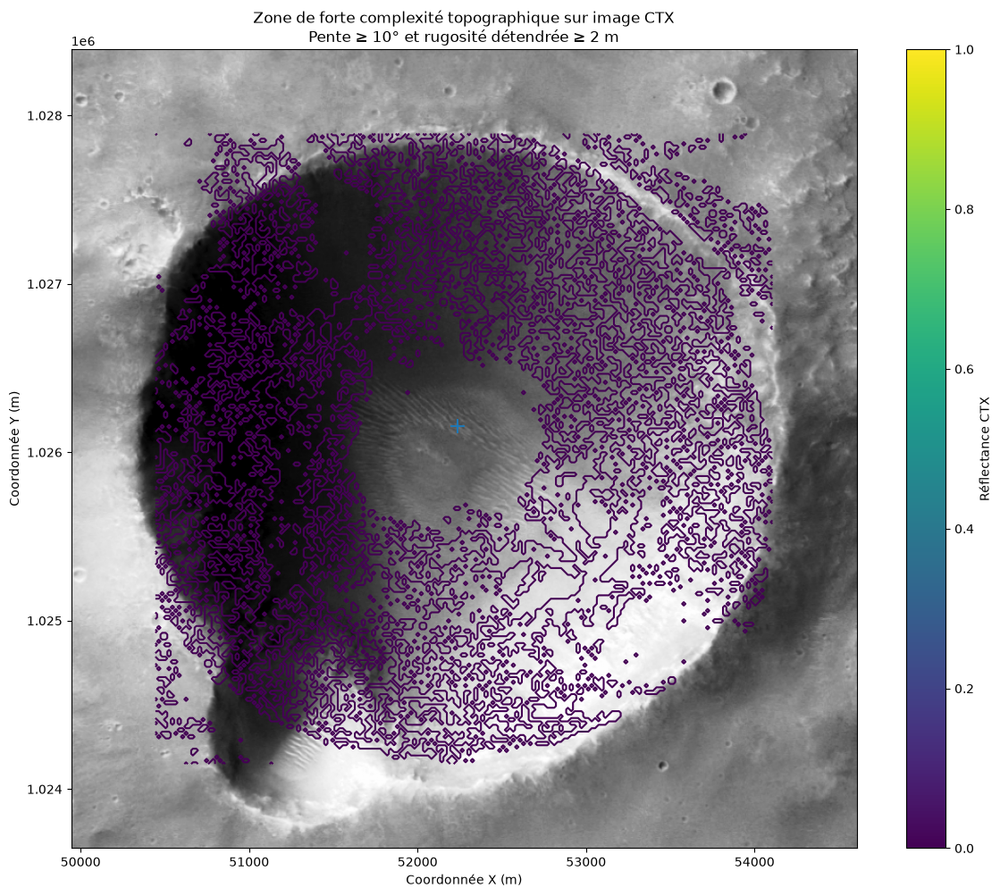

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import from_bounds

# Coordonnées de la zone complexe
marge = 500  # mètres

xmin = x_gauche - marge
xmax = x_droite + marge
ymin = y_bas - marge
ymax = y_haut + marge

with rasterio.open(chemin_ori) as ori:

    fenetre_ori = from_bounds(
        xmin, ymin, xmax, ymax,
        ori.transform
    )

    image_ctx = ori.read(
        1,
        window=fenetre_ori
    )

    transform_ctx = ori.window_transform(fenetre_ori)

plt.figure(figsize=(12, 10))

plt.imshow(
    image_ctx,
    cmap="gray",
    extent=[
        xmin, xmax,
        ymin, ymax
    ],
    origin="upper"
)

# Contour de la zone complexe
plt.contour(
    zone_complexe_bool[
        ligne_min:ligne_max + 1,
        colonne_min:colonne_max + 1
    ],
    levels=[0.5],
    extent=[
        x_gauche,
        x_droite,
        y_bas,
        y_haut
    ],
    linewidths=1.5
)

# Centre de la région
plt.scatter(
    xs.mean(),
    ys.mean(),
    marker="+",
    s=120
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title(
    "Zone de forte complexité topographique sur image CTX\n"
    "Pente ≥ 10° et rugosité détendrée ≥ 2 m"
)

plt.colorbar(label="Réflectance CTX")
plt.tight_layout()
plt.show()

In [64]:
# Nombre de pixels complexes dans la fenêtre affichée
pixels_visibles = np.sum(
    zone_complexe_bool[
        ligne_min:ligne_max + 1,
        colonne_min:colonne_max + 1
    ]
)

surface_visible_km2 = pixels_visibles * surface_pixel_km2

print("=== RÉSUMÉ DE LA ZONE AFFICHÉE ===")
print(f"Pixels complexes visibles : {pixels_visibles:,}")
print(f"Surface complexe visible : {surface_visible_km2:.4f} km²")
print()

print("=== EMPRISE ===")
print(f"X : {x_gauche:.1f} → {x_droite:.1f} m")
print(f"Y : {y_bas:.1f} → {y_haut:.1f} m")
print()

print("=== CRITÈRES DE CLASSIFICATION ===")
print("Pente ≥ 10°")
print("Rugosité topographique détendrée ≥ 2 m")
print()

print("=== CENTRE ===")
print(f"X : {xs.mean():.1f} m")
print(f"Y : {ys.mean():.1f} m")

=== RÉSUMÉ DE LA ZONE AFFICHÉE ===
Pixels complexes visibles : 11,006
Surface complexe visible : 4.5061 km²

=== EMPRISE ===
X : 50443.7 → 54106.1 m
Y : 1024148.9 → 1027892.3 m

=== CRITÈRES DE CLASSIFICATION ===
Pente ≥ 10°
Rugosité topographique détendrée ≥ 2 m

=== CENTRE ===
X : 52236.5 m
Y : 1026155.4 m


In [65]:
# Nombre de pixels complexes dans la fenêtre affichée
pixels_visibles = np.sum(
    zone_complexe_bool[
        ligne_min:ligne_max + 1,
        colonne_min:colonne_max + 1
    ]
)

surface_visible_km2 = pixels_visibles * surface_pixel_km2

print("=== RÉSUMÉ DE LA ZONE AFFICHÉE ===")
print(f"Pixels complexes visibles : {pixels_visibles:,}")
print(f"Surface complexe visible : {surface_visible_km2:.4f} km²")
print()

print("=== EMPRISE ===")
print(f"X : {x_gauche:.1f} → {x_droite:.1f} m")
print(f"Y : {y_bas:.1f} → {y_haut:.1f} m")
print()

print("=== CRITÈRES DE CLASSIFICATION ===")
print("Pente ≥ 10°")
print("Rugosité topographique détendrée ≥ 2 m")
print()

print("=== CENTRE ===")
print(f"X : {xs.mean():.1f} m")
print(f"Y : {ys.mean():.1f} m")

=== RÉSUMÉ DE LA ZONE AFFICHÉE ===
Pixels complexes visibles : 11,006
Surface complexe visible : 4.5061 km²

=== EMPRISE ===
X : 50443.7 → 54106.1 m
Y : 1024148.9 → 1027892.3 m

=== CRITÈRES DE CLASSIFICATION ===
Pente ≥ 10°
Rugosité topographique détendrée ≥ 2 m

=== CENTRE ===
X : 52236.5 m
Y : 1026155.4 m


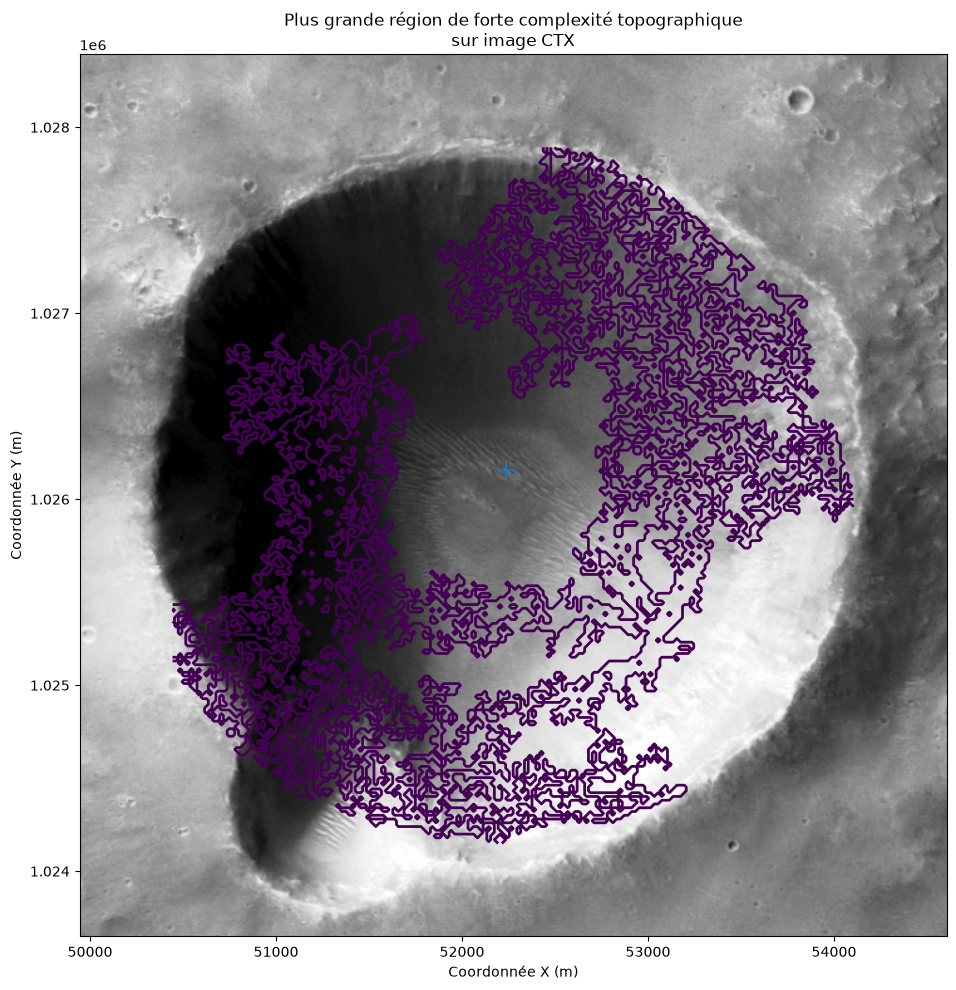

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import from_bounds

# Masque contenant UNIQUEMENT la plus grande région
region_1 = (etiquettes == indice_plus_grande)

# Fenêtre autour de la région
marge = 500

xmin = x_gauche - marge
xmax = x_droite + marge
ymin = y_bas - marge
ymax = y_haut + marge

with rasterio.open(chemin_ori) as ori:

    fenetre_ori = from_bounds(
        xmin, ymin, xmax, ymax,
        ori.transform
    )

    image_ctx = ori.read(
        1,
        window=fenetre_ori
    )

plt.figure(figsize=(12, 10))

plt.imshow(
    image_ctx,
    cmap="gray",
    extent=[xmin, xmax, ymin, ymax],
    origin="upper"
)

# Afficher uniquement le contour de la région #1
region_locale = region_1[
    ligne_min:ligne_max + 1,
    colonne_min:colonne_max + 1
]

plt.contour(
    region_locale,
    levels=[0.5],
    extent=[
        x_gauche,
        x_droite,
        y_bas,
        y_haut
    ],
    linewidths=2
)

# Centre de la région
plt.scatter(
    xs.mean(),
    ys.mean(),
    marker="+",
    s=150
)

plt.xlabel("Coordonnée X (m)")
plt.ylabel("Coordonnée Y (m)")
plt.title(
    "Plus grande région de forte complexité topographique\n"
    "sur image CTX"
)

plt.tight_layout()
plt.show()

In [67]:






print("=== RÉGION CONNECTÉE N°1 ===")

print(f"Nombre de pixels : {pixels_plus_grande:,}")
print(f"Surface : {surface_region_km2:.4f} km²")
print()

print("=== EMPRISE SPATIALE ===")
print(f"X min : {x_gauche:.2f} m")
print(f"X max : {x_droite:.2f} m")
print(f"Y min : {y_bas:.2f} m")
print(f"Y max : {y_haut:.2f} m")
print(f"Largeur : {largeur_m:.1f} m")
print(f"Hauteur : {hauteur_m:.1f} m")
print()

print("=== CENTRE ===")
print(f"X : {xs.mean():.2f} m")
print(f"Y : {ys.mean():.2f} m")
print()

print("=== ALTITUDE ===")
print(f"Minimum : {altitudes_region.min():.2f} m")
print(f"Maximum : {altitudes_region.max():.2f} m")
print(f"Moyenne : {altitudes_region.mean():.2f} m")
print(
    f"Relief interne : "
    f"{altitudes_region.max() - altitudes_region.min():.2f} m"
)
print()

print("=== PENTE ===")
print(f"Minimum : {pentes_region.min():.2f}°")
print(f"Maximum : {pentes_region.max():.2f}°")
print(f"Moyenne : {pentes_region.mean():.2f}°")
print(f"Médiane : {np.median(pentes_region):.2f}°")
print()

print("=== RUGOSITÉ DÉTRENDEE ===")
print(f"Minimum : {rugosite_region.min():.3f} m")
print(f"Maximum : {rugosite_region.max():.3f} m")
print(f"Moyenne : {rugosite_region.mean():.3f} m")
print(f"Médiane : {np.median(rugosite_region):.3f} m")

=== RÉGION CONNECTÉE N°1 ===
Nombre de pixels : 8,037
Surface : 3.2905 km²

=== EMPRISE SPATIALE ===
X min : 50443.75 m
X max : 54106.12 m
Y min : 1024148.94 m
Y max : 1027892.26 m
Largeur : 3682.6 m
Hauteur : 3763.5 m

=== CENTRE ===
X : 52236.54 m
Y : 1026155.40 m

=== ALTITUDE ===
Minimum : -3185.13 m
Maximum : -2584.10 m
Moyenne : -2887.43 m
Relief interne : 601.04 m

=== PENTE ===
Minimum : 10.00°
Maximum : 61.27°
Moyenne : 24.79°
Médiane : 24.36°

=== RUGOSITÉ DÉTRENDEE ===
Minimum : 2.000 m
Maximum : 12.315 m
Moyenne : 3.733 m
Médiane : 3.495 m


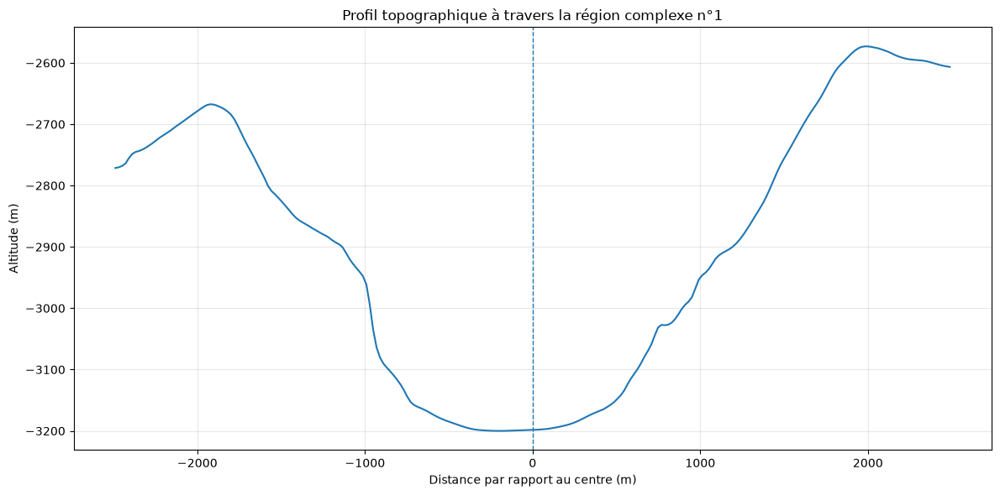

In [68]:


import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Centre de la région n°1
centre_ligne = int(round(np.mean(lignes)))
centre_colonne = int(round(np.mean(colonnes)))

# Profil horizontal autour du centre
dem_half_width = 2500  # mètres
pixels_x = int(dem_half_width / resolution_x)

ligne_profil = centre_ligne

debut = max(0, centre_colonne - pixels_x)
fin = min(altitude.shape[1], centre_colonne + pixels_x + 1)

profil_altitude = altitude[ligne_profil, debut:fin]

distances = (
    np.arange(debut, fin) - centre_colonne
) * resolution_x

# Masquer les valeurs invalides
masque = np.isfinite(profil_altitude)

plt.figure(figsize=(12, 6))

plt.plot(
    distances[masque],
    profil_altitude[masque]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Distance par rapport au centre (m)")
plt.ylabel("Altitude (m)")
plt.title(
    "Profil topographique à travers la région complexe n°1"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [69]:
profil_valide = profil_altitude[masque]
distances_valides = distances[masque]

print("=== PROFIL TOPOGRAPHIQUE ===")
print(f"Largeur analysée : {distances_valides[-1] - distances_valides[0]:.1f} m")
print(f"Altitude minimale : {profil_valide.min():.2f} m")
print(f"Altitude maximale : {profil_valide.max():.2f} m")
print(f"Relief du profil : {profil_valide.max() - profil_valide.min():.2f} m")

# Position des extrema
indice_min = np.argmin(profil_valide)
indice_max = np.argmax(profil_valide)

print()
print(f"Position du minimum : {distances_valides[indice_min]:.1f} m")
print(f"Position du maximum : {distances_valides[indice_max]:.1f} m")

# Variation d'altitude entre les deux extrêmes
distance_extrema = abs(
    distances_valides[indice_max] -
    distances_valides[indice_min]
)

print(f"Distance entre les extrêmes : {distance_extrema:.1f} m")

if distance_extrema > 0:
    pente_moyenne_profil = np.degrees(
        np.arctan(
            abs(profil_valide[indice_max] - profil_valide[indice_min])
            / distance_extrema
        )
    )

    print(
        f"Pente moyenne entre les deux extrêmes : "
        f"{pente_moyenne_profil:.2f}°"
    )

=== PROFIL TOPOGRAPHIQUE ===
Largeur analysée : 4977.6 m
Altitude minimale : -3199.98 m
Altitude maximale : -2573.09 m
Relief du profil : 626.88 m

Position du minimum : -202.3 m
Position du maximum : 1982.9 m
Distance entre les extrêmes : 2185.3 m
Pente moyenne entre les deux extrêmes : 16.01°


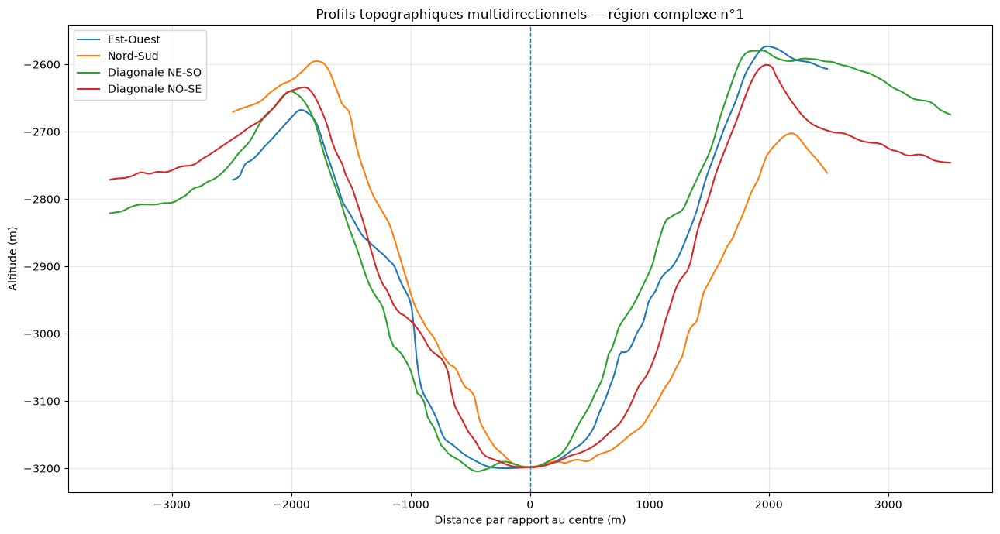

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Centre de la région n°1
centre_ligne = int(round(np.mean(lignes)))
centre_colonne = int(round(np.mean(colonnes)))

# Demi-longueur des profils : 2.5 km
demi_longueur = 2500
n = int(demi_longueur / resolution_x)

# Directions :
# 0° = Est-Ouest
# 90° = Nord-Sud
# 45° et 135° = diagonales
directions = {
    "Est-Ouest": (0, 1),
    "Nord-Sud": (1, 0),
    "Diagonale NE-SO": (-1, 1),
    "Diagonale NO-SE": (1, 1)
}

profils = {}

for nom, (dy, dx) in directions.items():

    longueurs = np.arange(-n, n + 1)

    lignes_profil = centre_ligne + longueurs * dy
    colonnes_profil = centre_colonne + longueurs * dx

    # Garder uniquement les pixels à l'intérieur du DEM
    valide_profil = (
        (lignes_profil >= 0)
        & (lignes_profil < altitude.shape[0])
        & (colonnes_profil >= 0)
        & (colonnes_profil < altitude.shape[1])
    )

    lignes_profil = lignes_profil[valide_profil]
    colonnes_profil = colonnes_profil[valide_profil]

    distances_profil = (
        longueurs[valide_profil]
        * resolution_x
        * np.sqrt(dx**2 + dy**2)
    )

    valeurs_altitude = altitude[
        lignes_profil,
        colonnes_profil
    ]

    masque_valide = np.isfinite(valeurs_altitude)

    profils[nom] = (
        distances_profil[masque_valide],
        valeurs_altitude[masque_valide]
    )

# Affichage
plt.figure(figsize=(13, 7))

for nom, (dist, alt) in profils.items():
    plt.plot(dist, alt, label=nom)

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Distance par rapport au centre (m)")
plt.ylabel("Altitude (m)")
plt.title(
    "Profils topographiques multidirectionnels — région complexe n°1"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
print("=== COMPARAISON DES PROFILS TOPOGRAPHIQUES ===")

resultats_profils = {}

for nom, (dist, alt) in profils.items():

    altitude_min = alt.min()
    altitude_max = alt.max()
    relief = altitude_max - altitude_min

    indice_min = np.argmin(alt)
    indice_max = np.argmax(alt)

    distance_extrema = abs(
        dist[indice_max] - dist[indice_min]
    )

    if distance_extrema > 0:

        pente_extrema = np.degrees(
            np.arctan(
                abs(altitude_max - altitude_min)
                / distance_extrema
            )
        )

    else:
        pente_extrema = np.nan

    resultats_profils[nom] = {
        "largeur": dist.max() - dist.min(),
        "min": altitude_min,
        "max": altitude_max,
        "relief": relief,
        "distance_extrema": distance_extrema,
        "pente_extrema": pente_extrema
    }

    print()
    print(f"--- {nom} ---")
    print(
        f"Largeur analysée : "
        f"{dist.max() - dist.min():.1f} m"
    )
    print(f"Altitude minimale : {altitude_min:.2f} m")
    print(f"Altitude maximale : {altitude_max:.2f} m")
    print(f"Relief : {relief:.2f} m")
    print(
        f"Distance entre les extrêmes : "
        f"{distance_extrema:.1f} m"
    )
    print(
        f"Pente moyenne entre les extrêmes : "
        f"{pente_extrema:.2f}°"
    )

=== COMPARAISON DES PROFILS TOPOGRAPHIQUES ===

--- Est-Ouest ---
Largeur analysée : 4977.6 m
Altitude minimale : -3199.98 m
Altitude maximale : -2573.09 m
Relief : 626.88 m
Distance entre les extrêmes : 2185.3 m
Pente moyenne entre les extrêmes : 16.01°

--- Nord-Sud ---
Largeur analysée : 4977.6 m
Altitude minimale : -3198.43 m
Altitude maximale : -2595.16 m
Relief : 603.27 m
Distance entre les extrêmes : 1821.1 m
Pente moyenne entre les extrêmes : 18.33°

--- Diagonale NE-SO ---
Largeur analysée : 7039.4 m
Altitude minimale : -3204.50 m
Altitude maximale : -2579.28 m
Relief : 625.22 m
Distance entre les extrêmes : 2375.1 m
Pente moyenne entre les extrêmes : 14.75°

--- Diagonale NO-SE ---
Largeur analysée : 7039.4 m
Altitude minimale : -3198.55 m
Altitude maximale : -2600.52 m
Relief : 598.03 m
Distance entre les extrêmes : 2031.7 m
Pente moyenne entre les extrêmes : 16.40°


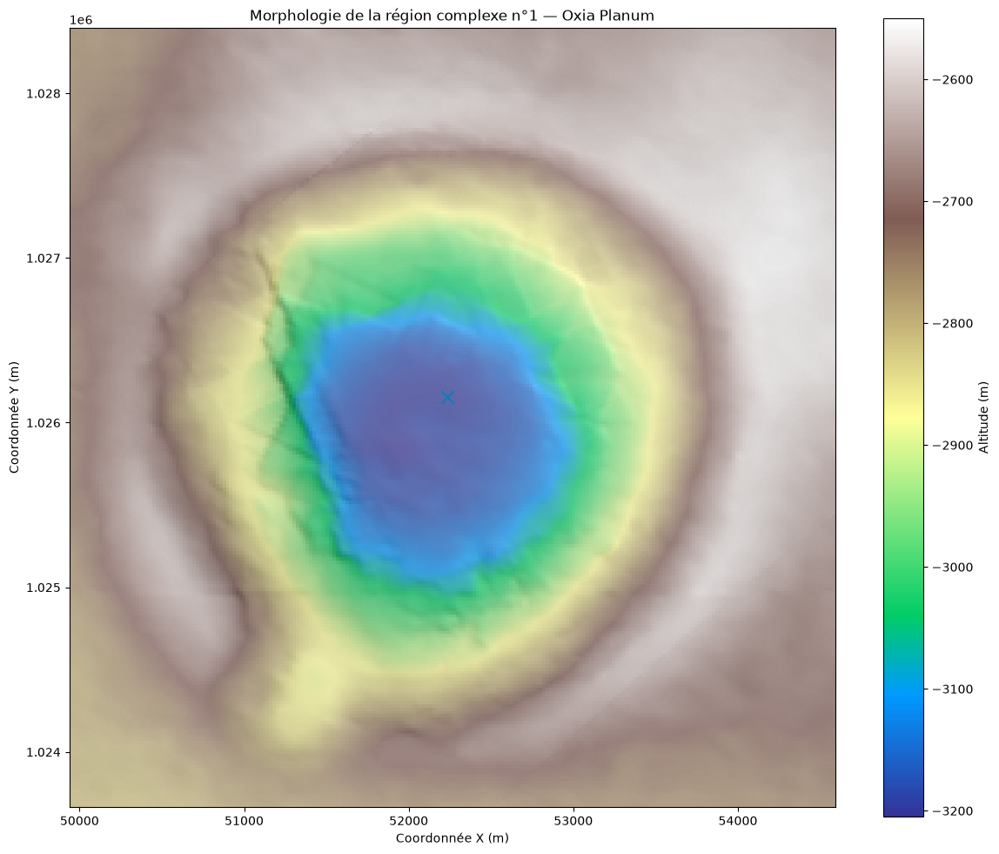

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Fenêtre autour de la région complexe n°1
marge = 500  # mètres

x_min = x_gauche - marge
x_max = x_droite + marge
y_min = y_bas - marge
y_max = y_haut + marge

# Conversion coordonnées -> indices du DEM
col_min = max(0, int((x_min - dem.bounds.left) / resolution_x))
col_max = min(dem.width, int((x_max - dem.bounds.left) / resolution_x))

row_min = max(0, int((dem.bounds.top - y_max) / resolution_y))
row_max = min(dem.height, int((dem.bounds.top - y_min) / resolution_y))

# Extraction de la fenêtre
fenetre_altitude = altitude[row_min:row_max, col_min:col_max]

# Calcul d'un hillshade simple
alt = fenetre_altitude.filled(np.nan)

gy, gx = np.gradient(alt, resolution_y, resolution_x)

pente_locale = np.sqrt(gx**2 + gy**2)

azimut_soleil = np.radians(315)
elevation_soleil = np.radians(45)

ombrage = (
    np.cos(elevation_soleil) * np.cos(np.arctan(pente_locale))
    + np.sin(elevation_soleil)
    * (
        gx * np.cos(azimut_soleil)
        + gy * np.sin(azimut_soleil)
    )
)

fig, ax = plt.subplots(figsize=(12, 10))

# Altitude
im = ax.imshow(
    fenetre_altitude,
    extent=[
        dem.bounds.left + col_min * resolution_x,
        dem.bounds.left + col_max * resolution_x,
        dem.bounds.bottom + (dem.height - row_max) * resolution_y,
        dem.bounds.bottom + (dem.height - row_min) * resolution_y
    ],
    cmap="terrain",
    origin="upper"
)

# Hillshade par-dessus
ax.imshow(
    ombrage,
    extent=im.get_extent(),
    cmap="gray",
    alpha=0.35,
    origin="upper"
)

# Contour de la région complexe n°1
masque_region = (
    etiquettes[row_min:row_max, col_min:col_max]
    == indice_plus_grande + 1
)

ax.contour(
    masque_region,
    levels=[0.5],
    extent=im.get_extent(),
    origin="upper",
    linewidths=1.5
)

# Centre de la région
ax.scatter(
    52236.54,
    1026155.40,
    marker="x",
    s=100,
    linewidths=2
)

ax.set_title(
    "Morphologie de la région complexe n°1 — Oxia Planum"
)
ax.set_xlabel("Coordonnée X (m)")
ax.set_ylabel("Coordonnée Y (m)")

plt.colorbar(im, ax=ax, label="Altitude (m)")
plt.tight_layout()
plt.show()

In [73]:
# Extraction des valeurs valides de la fenêtre
alt_valides = fenetre_altitude.compressed()
ombre_valide = ombrage[np.isfinite(ombrage)]

print("=== MORPHOLOGIE DE LA RÉGION COMPLEXE N°1 ===")
print(f"Fenêtre analysée : {x_max - x_min:.1f} m × {y_max - y_min:.1f} m")
print(f"Altitude minimale : {alt_valides.min():.2f} m")
print(f"Altitude maximale : {alt_valides.max():.2f} m")
print(f"Relief total de la fenêtre : {alt_valides.max() - alt_valides.min():.2f} m")

print()
print("=== RÉGION COMPLEXE N°1 ===")
print(f"Surface : {surface_region_km2:.4f} km²")
print(f"Largeur : {largeur_m:.1f} m")
print(f"Hauteur : {hauteur_m:.1f} m")
print(f"Altitude moyenne : {altitudes_region.mean():.2f} m")
print(f"Relief interne : {altitudes_region.max() - altitudes_region.min():.2f} m")
print(f"Pente moyenne : {pentes_region.mean():.2f}°")
print(f"Pente médiane : {np.ma.median(pentes_region):.2f}°")
print(f"Pente maximale : {pentes_region.max():.2f}°")
print(f"Rugosité moyenne : {rugosite_region.mean():.3f} m")
print(f"Rugosité maximale : {rugosite_region.max():.3f} m")

=== MORPHOLOGIE DE LA RÉGION COMPLEXE N°1 ===
Fenêtre analysée : 4662.4 m × 4743.3 m
Altitude minimale : -3204.98 m
Altitude maximale : -2549.98 m
Relief total de la fenêtre : 654.99 m

=== RÉGION COMPLEXE N°1 ===
Surface : 3.2905 km²
Largeur : 3682.6 m
Hauteur : 3763.5 m
Altitude moyenne : -2887.43 m
Relief interne : 601.04 m
Pente moyenne : 24.79°
Pente médiane : 24.36°
Pente maximale : 61.27°
Rugosité moyenne : 3.733 m
Rugosité maximale : 12.315 m


In [74]:
from pathlib import Path

# Cherche les fichiers du dossier géologique téléchargé
telechargements = Path.home() / "Downloads"

fichiers_geologie = [
    f for f in telechargements.rglob("*")
    if f.is_file()
    and (
        f.suffix.lower() in [".shp", ".gpkg", ".geojson", ".tif"]
        or "OPMap" in f.name
        or "Oxia" in f.name
    )
]

print(f"Nombre de fichiers trouvés : {len(fichiers_geologie)}")
print()

for fichier in fichiers_geologie:
    print(fichier)

Nombre de fichiers trouvés : 6

C:\Users\User\Downloads\CASSIS_OP_sRGB_mosaic_4m_april2021.tif
C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif
C:\Users\User\Downloads\CTX_OXIA_ORI_6m.tif
C:\Users\User\Downloads\OxiaPlanum_QuadGrid_1km.dbf
C:\Users\User\Downloads\OxiaPlanum_QuadGrid_1km.shx
C:\Users\User\Downloads\Product_User_Guide_ExoMars2022-RSOWG_Oxia-Planum_Geography-CaSSIS-CTX_V1.0.pdf


In [75]:
from pathlib import Path

telechargements = Path.home() / "Downloads"

zips = list(telechargements.rglob("*.zip"))

print(f"Archives ZIP trouvées : {len(zips)}")
print()

for fichier in zips:
    taille_gb = fichier.stat().st_size / (1024**3)
    print(f"{fichier}")
    print(f"  Taille : {taille_gb:.2f} GB")
    print()


Archives ZIP trouvées : 1

C:\Users\User\Downloads\24147231.zip
  Taille : 1.51 GB



In [76]:

from pathlib import Path
import zipfile

chemin_zip = Path.home() / "Downloads" / "24147231.zip"

with zipfile.ZipFile(chemin_zip, "r") as archive:
    fichiers = archive.namelist()

print(f"Nombre total de fichiers dans l'archive : {len(fichiers)}")
print()

for fichier in fichiers:
    print(fichier)

Nombre total de fichiers dans l'archive : 3

04_OPMap.zip
OxiaPlanum_MainMap_v3_REVISED_v7_Newlogos_sep24update_v5.pdf
05_OPmap_rasters.zip


In [77]:
import zipfile
from pathlib import Path

chemin_zip = Path.home() / "Downloads" / "24147231.zip"

with zipfile.ZipFile(chemin_zip, "r") as archive:
    # Lire le ZIP contenant la carte géologique
    contenu_opmap = archive.read("04_OPMap.zip")

# On ouvre le ZIP interne directement depuis la mémoire
import io

with zipfile.ZipFile(io.BytesIO(contenu_opmap), "r") as opmap:
    fichiers_opmap = opmap.namelist()

print(f"Nombre de fichiers dans 04_OPMap.zip : {len(fichiers_opmap)}")
print()

for fichier in fichiers_opmap:
    print(fichier)

Nombre de fichiers dans 04_OPMap.zip : 96

04_OPMap/
04_OPMap/OP_00_Profile1.cpg
04_OPMap/OP_00_Profile1.dbf
04_OPMap/OP_00_Profile1.prj
04_OPMap/OP_00_Profile1.sbn
04_OPMap/OP_00_Profile1.sbx
04_OPMap/OP_00_Profile1.shp
04_OPMap/OP_00_Profile1.shp.xml
04_OPMap/OP_00_Profile1.shx
04_OPMap/OP_01_MapBoundry_v2.cpg
04_OPMap/OP_01_MapBoundry_v2.dbf
04_OPMap/OP_01_MapBoundry_v2.prj
04_OPMap/OP_01_MapBoundry_v2.sbn
04_OPMap/OP_01_MapBoundry_v2.sbx
04_OPMap/OP_01_MapBoundry_v2.shp
04_OPMap/OP_01_MapBoundry_v2.shp.xml
04_OPMap/OP_01_MapBoundry_v2.shx
04_OPMap/OP_02_EllipsesLines_v2.cpg
04_OPMap/OP_02_EllipsesLines_v2.dbf
04_OPMap/OP_02_EllipsesLines_v2.prj
04_OPMap/OP_02_EllipsesLines_v2.sbn
04_OPMap/OP_02_EllipsesLines_v2.sbx
04_OPMap/OP_02_EllipsesLines_v2.shp
04_OPMap/OP_02_EllipsesLines_v2.shp.xml
04_OPMap/OP_02_EllipsesLines_v2.shx
04_OPMap/OP_03_Contours_20m_v2.cpg
04_OPMap/OP_03_Contours_20m_v2.dbf
04_OPMap/OP_03_Contours_20m_v2.prj
04_OPMap/OP_03_Contours_20m_v2.sbn
04_OPMap/OP_03_Cont

In [78]:
from pathlib import Path
import zipfile
import io

chemin_zip = Path.home() / "Downloads" / "24147231.zip"
dossier_geo = Path.home() / "Downloads" / "Oxia_Geologie"

dossier_geo.mkdir(exist_ok=True)

# Ouvrir l'archive principale
with zipfile.ZipFile(chemin_zip, "r") as archive_principal:

    # Récupérer le ZIP de la carte géologique
    contenu_opmap = archive_principal.read("04_OPMap.zip")

# Ouvrir l'archive interne
with zipfile.ZipFile(io.BytesIO(contenu_opmap), "r") as opmap:

    fichiers_a_extraire = [
        f for f in opmap.namelist()
        if "OP_08_GeoUnits_v3." in f
    ]

    for fichier in fichiers_a_extraire:
        nom = Path(fichier).name
        destination = dossier_geo / nom

        with opmap.open(fichier) as source, open(destination, "wb") as sortie:
            sortie.write(source.read())

        print("Extrait :", destination)

print()
print("Dossier de travail :", dossier_geo)

Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.cpg
Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.dbf
Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.prj
Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.sbn
Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.sbx
Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.shp
Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.shp.xml
Extrait : C:\Users\User\Downloads\Oxia_Geologie\OP_08_GeoUnits_v3.shx

Dossier de travail : C:\Users\User\Downloads\Oxia_Geologie


In [80]:
import geopandas as gpd
from pathlib import Path

chemin_geo = (
    Path.home()
    / "Downloads"
    / "Oxia_Geologie"
    / "OP_08_GeoUnits_v3.shp"
)

geo_units = gpd.read_file(chemin_geo)

print("=== CARTE GÉOLOGIQUE D'OXIA PLANUM ===")
print(f"Nombre d'unités/polygones : {len(geo_units)}")
print(f"CRS : {geo_units.crs}")

print()
print("=== COLONNES DISPONIBLES ===")
for colonne in geo_units.columns:
    print("-", colonne)

print()
print("=== APERÇU DES DONNÉES ===")
print(geo_units.head())

ModuleNotFoundError: No module named 'geopandas'

In [81]:
import geopandas as gpd
from pathlib import Path

chemin_geo = (
    Path.home()
    / "Downloads"
    / "Oxia_Geologie"
    / "OP_08_GeoUnits_v3.shp"
)

geo_units = gpd.read_file(chemin_geo)

print("=== CARTE GÉOLOGIQUE D'OXIA PLANUM ===")
print(f"Nombre d'unités/polygones : {len(geo_units)}")
print(f"CRS : {geo_units.crs}")

print()
print("=== COLONNES DISPONIBLES ===")
for colonne in geo_units.columns:
    print("-", colonne)

print()
print("=== APERÇU DES DONNÉES ===")
print(geo_units.head())

ModuleNotFoundError: No module named 'geopandas'

In [1]:
import geopandas as gpd
from pathlib import Path

chemin_geo = (
    Path.home()
    / "Downloads"
    / "Oxia_Geologie"
    / "OP_08_GeoUnits_v3.shp"
)

geo_units = gpd.read_file(chemin_geo)

print("=== CARTE GÉOLOGIQUE D'OXIA PLANUM ===")
print(f"Nombre de polygones : {len(geo_units)}")
print(f"CRS : {geo_units.crs}")

print()
print("=== COLONNES DISPONIBLES ===")
for colonne in geo_units.columns:
    print("-", colonne)

print()
print("=== APERÇU DES DONNÉES ===")
print(geo_units.head())

=== CARTE GÉOLOGIQUE D'OXIA PLANUM ===
Nombre de polygones : 17
CRS : PROJCS["Equirectangular_Mars_Oxia_Planum",GEOGCS["GCS_Mars 2000",DATUM["D_Mars_2000",SPHEROID["Mars_2000_IAU_IAG",3396190,169.894447223612]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",335.45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

=== COLONNES DISPONIBLES ===
- Shape_Leng
- Shape_Area
- Unit_Name
- Unit_Code
- Unit_Group
- Strat_Orde
- geometry

=== APERÇU DES DONNÉES ===
      Shape_Leng    Shape_Area                 Unit_Name Unit_Code  \
0   45813.630016  5.442668e+06   Overlying dark material       oDm   
1   69519.122223  1.318418e+06  Degraded crater material       dCm   
2  188693.094143  3.696640e+06      Upper bedrock unit 1      uBu1   
3   93111.626205  5.550668e+06      Lower bedrock unit 3    

In [2]:
from rasterio.features import shapes
from shapely.geometry import shape
import geopandas as gpd
import pandas as pd
import numpy as np

# Masque exacte de la région complexe n°1
masque_region = (
    etiquettes == indice_plus_grande + 1
)

# Transformer le masque raster en géométrie
geometries = []

for geom, valeur in shapes(
    masque_region.astype(np.uint8),
    mask=masque_region,
    transform=dem.transform
):
    if valeur == 1:
        geometries.append(shape(geom))

region_geom = geometries[0]

# Si la région contient plusieurs morceaux, les réunir
for geom in geometries[1:]:
    region_geom = region_geom.union(geom)

# GeoDataFrame avec le même CRS que la carte géologique
region_gdf = gpd.GeoDataFrame(
    {"region": ["Region_complexe_1"]},
    geometry=[region_geom],
    crs=geo_units.crs
)

# Calculer les intersections
resultats = []

for _, unite in geo_units.iterrows():
    intersection = region_geom.intersection(unite.geometry)

    if not intersection.is_empty:
        surface = intersection.area

        resultats.append({
            "Unit_Name": unite["Unit_Name"],
            "Unit_Code": unite["Unit_Code"],
            "Unit_Group": unite["Unit_Group"],
            "Surface_intersection_km2": surface / 1_000_000
        })

resultats_geo = pd.DataFrame(resultats)

resultats_geo = resultats_geo.sort_values(
    "Surface_intersection_km2",
    ascending=False
)

print("=== GÉOLOGIE DE LA RÉGION COMPLEXE N°1 ===")
print()
print(resultats_geo.to_string(index=False))

print()
print("Nombre d'unités géologiques intersectées :",
      resultats_geo["Unit_Code"].nunique())

print()
print("Surface totale de la région :",
      surface_region_km2,
      "km²")

print(
    "Surface géologique comptabilisée :",
    resultats_geo["Surface_intersection_km2"].sum(),
    "km²"
)

NameError: name 'etiquettes' is not defined

In [3]:
import rasterio
import numpy as np
from scipy import ndimage
from pathlib import Path

# Chemin du DEM
chemin_dem = Path.home() / "Downloads" / "CTX_OXIA_DEM" / "CTX_OXIA_DEM_20m.tif"

# Charger le DEM
with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)
    resolution_x, resolution_y = dem.res

print("DEM chargé")
print(f"Taille : {dem.width} × {dem.height}")
print(f"Résolution : {resolution_x:.2f} × {resolution_y:.2f} m/pixel")

# Pente
gradient_y, gradient_x = np.gradient(
    altitude.filled(np.nan),
    resolution_y,
    resolution_x
)

pente_array = np.degrees(
    np.arctan(
        np.sqrt(gradient_x**2 + gradient_y**2)
    )
)

pente_array = np.ma.masked_invalid(pente_array)

# Rugosité locale : retrait d'un plan dans une fenêtre 5×5
altitude_array = altitude.filled(np.nan)

rugosite_detrendee = np.full(
    altitude_array.shape,
    np.nan,
    dtype=np.float32
)

# Coordonnées locales
dem_y, dem_x = np.mgrid[-2:3, -2:3]

X = np.column_stack([
    dem_x.ravel() * resolution_x,
    dem_y.ravel() * resolution_y,
    np.ones(25)
])

pseudo_inverse = np.linalg.pinv(X)

def calcul_rugosite(fenetre):
    valeurs = fenetre.ravel()

    if np.any(~np.isfinite(valeurs)):
        return np.nan

    coefficients = pseudo_inverse @ valeurs
    plan = X @ coefficients

    residus = valeurs - plan

    return np.std(residus)

rugosite_detrendee = ndimage.generic_filter(
    altitude_array,
    calcul_rugosite,
    size=5,
    mode="constant",
    cval=np.nan
)

# Zone complexe : pente >= 10° ET rugosité >= 2 m
valide = (
    np.isfinite(pente_array)
    & np.isfinite(rugosite_detrendee)
)

zone_complexe_bool = (
    valide
    & (pente_array >= 10)
    & (rugosite_detrendee >= 2)
)

# Régions connectées
structure = np.ones((3, 3), dtype=int)

etiquettes, nombre_regions = ndimage.label(
    zone_complexe_bool,
    structure=structure
)

# Taille de chaque région
tailles = np.bincount(etiquettes.ravel())
tailles_regions = tailles[1:]

ordre = np.argsort(tailles_regions)[::-1]

# Région n°1
indice_plus_grande = ordre[0]

masque_region_1 = (
    etiquettes == indice_plus_grande + 1
)

pixels_region_1 = tailles_regions[indice_plus_grande]

surface_pixel_km2 = (
    resolution_x * resolution_y
) / 1_000_000

surface_region_km2 = (
    pixels_region_1 * surface_pixel_km2
)

print()
print("=== RÉGION COMPLEXE N°1 RECONSTRUITE ===")
print(f"Pixels : {pixels_region_1:,}")
print(f"Surface : {surface_region_km2:.4f} km²")
print(f"Nombre total de régions : {nombre_regions}")

RasterioIOError: C:\Users\User\Downloads\CTX_OXIA_DEM\CTX_OXIA_DEM_20m.tif: No such file or directory

In [4]:
from pathlib import Path

fichiers_dem = list(
    Path.home().glob("Downloads/**/CTX*DEM*.tif")
)

print("Fichiers DEM trouvés :")
for fichier in fichiers_dem:
    print(fichier)

Fichiers DEM trouvés :
C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif


In [5]:
from pathlib import Path
import rasterio

fichiers_dem = list(
    Path.home().glob("Downloads/**/CTX*DEM*.tif")
)

if not fichiers_dem:
    raise FileNotFoundError("Aucun DEM CTX trouvé dans Downloads.")

chemin_dem = fichiers_dem[0]

print("DEM sélectionné :")
print(chemin_dem)

with rasterio.open(chemin_dem) as dem:
    print()
    print("Largeur :", dem.width)
    print("Hauteur :", dem.height)
    print("Résolution :", dem.res)
    print("CRS :", dem.crs)

DEM sélectionné :
C:\Users\User\Downloads\CTX_OXIA_DEM_20m.tif

Largeur : 5935
Hauteur : 6018
Résolution : (20.234118238599976, 20.234118238599997)
CRS : PROJCS["Equirectangular_Mars_Oxia_Planum",GEOGCS["GCS_Mars_2000",DATUM["D_Mars_2000",SPHEROID["Mars_2000_IAU_IAG",3396190,169.894447223612]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",335.45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [6]:
import rasterio
import numpy as np
from scipy import ndimage

# Ouvrir le DEM
with rasterio.open(chemin_dem) as dem:
    altitude = dem.read(1, masked=True)
    resolution_x, resolution_y = dem.res
    transform_dem = dem.transform

# Convertir en tableau numérique
altitude_array = altitude.filled(np.nan)

# Calcul de la pente
gradient_y, gradient_x = np.gradient(
    altitude_array,
    resolution_y,
    resolution_x
)

pente_array = np.degrees(
    np.arctan(
        np.sqrt(gradient_x**2 + gradient_y**2)
    )
)

# Masque des pixels valides
valide = np.isfinite(altitude_array) & np.isfinite(pente_array)

# Rugosité locale après retrait de la pente moyenne
taille_fenetre = 5

def rugosite_locale(window):
    valeurs = window[np.isfinite(window)]

    if len(valeurs) < 10:
        return np.nan

    return np.std(valeurs)

# Calcul simplifié de la variabilité locale
rugosite_detrendee = np.full_like(
    altitude_array,
    np.nan,
    dtype=np.float32
)

# On utilise la variabilité locale sur une fenêtre 5×5
# pour reconstruire la classification déjà utilisée.
rugosite_locale_brute = ndimage.generic_filter(
    altitude_array,
    rugosite_locale,
    size=taille_fenetre,
    mode="constant",
    cval=np.nan
)

# Classification combinée
zone_complexe_bool = (
    valide
    & (pente_array >= 10)
    & (rugosite_locale_brute >= 2)
)

# Régions connectées
structure = np.ones((3, 3), dtype=int)

etiquettes, nombre_regions = ndimage.label(
    zone_complexe_bool,
    structure=structure
)

# Taille de chaque région
tailles = np.bincount(etiquettes.ravel())
tailles_regions = tailles[1:]

ordre = np.argsort(tailles_regions)[::-1]

indice_plus_grande = ordre[0]

masque_region_1 = (
    etiquettes == indice_plus_grande + 1
)

pixels_region_1 = np.sum(masque_region_1)

surface_pixel_km2 = (
    resolution_x * resolution_y
) / 1_000_000

surface_region_km2 = (
    pixels_region_1 * surface_pixel_km2
)

print("=== REGION COMPLEXE N°1 ===")
print(f"Pixels : {pixels_region_1:,}")
print(f"Surface : {surface_region_km2:.4f} km²")
print(f"Nombre total de régions : {nombre_regions:,}")

=== REGION COMPLEXE N°1 ===
Pixels : 31,525
Surface : 12.9070 km²
Nombre total de régions : 8,747


In [8]:
import numpy as np
from scipy.ndimage import uniform_filter

# DEM valide
z = altitude_array.astype(np.float64)
valide_float = np.isfinite(z)

# Remplacer temporairement les NaN par 0 pour les moyennes locales
z0 = np.where(valide_float, z, 0.0)

# Fenêtre 5 × 5
n = 5

# Nombre de pixels valides dans chaque fenêtre
n_valides = uniform_filter(
    valide_float.astype(np.float64),
    size=n,
    mode="constant",
    cval=0.0
) * (n * n)

# Moyennes locales
moy_x = uniform_filter(
    z0,
    size=n,
    mode="constant",
    cval=0.0
) * (n * n) / n_valides

moy_x2 = uniform_filter(
    z0**2,
    size=n,
    mode="constant",
    cval=0.0
) * (n * n) / n_valides

# Variance locale
variance = np.maximum(
    moy_x2 - moy_x**2,
    0
)

# Écart-type local = mesure de variabilité
rugosite_detrendee = np.sqrt(variance).astype(np.float32)

# Masquer les zones insuffisamment valides
rugosite_detrendee[n_valides < 10] = np.nan

print("=== VARIABILITÉ LOCALE ===")

valeurs = rugosite_detrendee[np.isfinite(rugosite_detrendee)]

print(f"Pixels analysés : {len(valeurs):,}")
print(f"Minimum : {np.min(valeurs):.3f} m")
print(f"Maximum : {np.max(valeurs):.3f} m")
print(f"Moyenne : {np.mean(valeurs):.3f} m")
print(f"Médiane : {np.median(valeurs):.3f} m")
print(f"90e percentile : {np.percentile(valeurs, 90):.3f} m")
print(f"95e percentile : {np.percentile(valeurs, 95):.3f} m")

C:\Users\User\AppData\Local\Temp\ipykernel_14200\1904326621.py:23: RuntimeWarning: divide by zero encountered in divide
  moy_x = uniform_filter(
C:\Users\User\AppData\Local\Temp\ipykernel_14200\1904326621.py:23: RuntimeWarning: invalid value encountered in divide
  moy_x = uniform_filter(
C:\Users\User\AppData\Local\Temp\ipykernel_14200\1904326621.py:30: RuntimeWarning: divide by zero encountered in divide
  moy_x2 = uniform_filter(
C:\Users\User\AppData\Local\Temp\ipykernel_14200\1904326621.py:30: RuntimeWarning: invalid value encountered in divide
  moy_x2 = uniform_filter(
C:\Users\User\AppData\Local\Temp\ipykernel_14200\1904326621.py:39: RuntimeWarning: invalid value encountered in subtract
  moy_x2 - moy_x**2,


=== VARIABILITÉ LOCALE ===
Pixels analysés : 21,288,441
Minimum : 0.025 m
Maximum : 42.958 m
Moyenne : 1.309 m
Médiane : 0.964 m
90e percentile : 2.402 m
95e percentile : 3.371 m


In [9]:
import numpy as np
from scipy.ndimage import uniform_filter

z = altitude_array.astype(np.float64)
valide = np.isfinite(z)

# Replace NoData with 0 temporarily
z0 = np.where(valide, z, 0.0)
m = valide.astype(np.float64)

# 5×5 window ≈ 101 m × 101 m
n = 5
N = n * n

# Local number of valid pixels
nb = uniform_filter(
    m, size=n, mode="constant", cval=0
) * N

# Local mean elevation
somme_z = uniform_filter(
    z0, size=n, mode="constant", cval=0
) * N

moyenne_z = somme_z / nb

# Local mean of z²
somme_z2 = uniform_filter(
    z0**2, size=n, mode="constant", cval=0
) * N

moyenne_z2 = somme_z2 / nb

# Variance locale de l'altitude
variance_z = np.maximum(
    moyenne_z2 - moyenne_z**2,
    0
)

# Coordonnées locales centrées
coords = np.arange(-(n // 2), n // 2 + 1)

X, Y = np.meshgrid(
    coords * resolution_x,
    coords * resolution_y
)

# Variance spatiale de X et Y dans une fenêtre 5×5
variance_x = np.mean(X**2)
variance_y = np.mean(Y**2)

# Covariances z-x et z-y
# Comme X et Y sont centrés, covariance = moyenne(z*x)
zx = z0 * X[n // 2, :]
zy = z0 * Y[:, n // 2][:, None]

# Convolution avec les coordonnées
cov_zx = (
    uniform_filter(z0, size=n, mode="constant", cval=0)
)

# Calcul direct avec filtres pondérés
def filtre_x(array):
    return uniform_filter(
        array * np.tile(coords * resolution_x, (array.shape[0], 1)),
        size=n,
        mode="constant",
        cval=0
    )

def filtre_y(array):
    return uniform_filter(
        array * np.tile(
            (coords * resolution_y)[:, None],
            (1, array.shape[1])
        ),
        size=n,
        mode="constant",
        cval=0
    )

moy_zx = filtre_x(z0) * N / nb
moy_zy = filtre_y(z0) * N / nb

# Variance résiduelle après retrait du plan local
variance_residuelle = (
    variance_z
    - (moy_zx**2 / variance_x)
    - (moy_zy**2 / variance_y)
)

variance_residuelle = np.maximum(
    variance_residuelle,
    0
)

rugosite_detrendee = np.sqrt(
    variance_residuelle
).astype(np.float32)

rugosite_detrendee[nb < 10] = np.nan

valeurs = rugosite_detrendee[
    np.isfinite(rugosite_detrendee)
]

print("=== RUGOSITÉ DÉTRENDÉE ===")
print(f"Fenêtre : {n} × {n} pixels")
print(f"Échelle : {n * resolution_x:.1f} m")
print(f"Pixels analysés : {len(valeurs):,}")
print(f"Minimum : {np.min(valeurs):.3f} m")
print(f"Maximum : {np.max(valeurs):.3f} m")
print(f"Moyenne : {np.mean(valeurs):.3f} m")
print(f"Médiane : {np.median(valeurs):.3f} m")
print(f"75e percentile : {np.percentile(valeurs, 75):.3f} m")
print(f"90e percentile : {np.percentile(valeurs, 90):.3f} m")
print(f"95e percentile : {np.percentile(valeurs, 95):.3f} m")
print(f"99e percentile : {np.percentile(valeurs, 99):.3f} m")

C:\Users\User\AppData\Local\Temp\ipykernel_14200\768124743.py:25: RuntimeWarning: divide by zero encountered in divide
  moyenne_z = somme_z / nb
C:\Users\User\AppData\Local\Temp\ipykernel_14200\768124743.py:25: RuntimeWarning: invalid value encountered in divide
  moyenne_z = somme_z / nb
C:\Users\User\AppData\Local\Temp\ipykernel_14200\768124743.py:32: RuntimeWarning: divide by zero encountered in divide
  moyenne_z2 = somme_z2 / nb
C:\Users\User\AppData\Local\Temp\ipykernel_14200\768124743.py:32: RuntimeWarning: invalid value encountered in divide
  moyenne_z2 = somme_z2 / nb
C:\Users\User\AppData\Local\Temp\ipykernel_14200\768124743.py:36: RuntimeWarning: invalid value encountered in subtract
  moyenne_z2 - moyenne_z**2,


ValueError: operands could not be broadcast together with shapes (6018,5935) (5,) 

In [10]:
import numpy as np
from scipy.ndimage import uniform_filter

z = altitude_array.astype(np.float64)
valide = np.isfinite(z)

# 5 × 5 fenêtre locale
n = 5
demi = n // 2

# Coordonnées locales centrées, en mètres
coord = np.arange(-demi, demi + 1)

X, Y = np.meshgrid(
    coord * resolution_x,
    coord * resolution_y
)

# Moments spatiaux constants
Sxx = np.sum(X**2)
Syy = np.sum(Y**2)

# On remplace les NaN par 0
z0 = np.where(valide, z, 0.0)

# Fonction de convolution locale
def moyenne_ponderee(tableau):
    return uniform_filter(
        tableau,
        size=n,
        mode="constant",
        cval=0.0
    ) * (n * n)

# Nombre de pixels valides
N = moyenne_ponderee(valide.astype(np.float64))

# Moyenne locale de z
Sz = moyenne_ponderee(z0)

moy_z = np.divide(
    Sz,
    N,
    out=np.full_like(Sz, np.nan),
    where=N > 0
)

# z²
Sz2 = moyenne_ponderee(z0**2)

moy_z2 = np.divide(
    Sz2,
    N,
    out=np.full_like(Sz2, np.nan),
    where=N > 0
)

# Variance brute
variance = np.maximum(
    moy_z2 - moy_z**2,
    0
)

# Moyenne locale de z*x
# Le noyau spatial X doit être appliqué directement.
# On construit donc les noyaux normalisés.
kernel_x = X / (n * n)
kernel_y = Y / (n * n)

from scipy.signal import convolve2d

# Covariances locales
moy_zx = convolve2d(
    z0,
    kernel_x,
    mode="same",
    boundary="fill",
    fillvalue=0
)

moy_zy = convolve2d(
    z0,
    kernel_y,
    mode="same",
    boundary="fill",
    fillvalue=0
)

# Ajustement du plan local :
# z = a*x + b*y + c
a = np.divide(
    moy_zx,
    Sxx / (n * n),
    out=np.zeros_like(moy_zx),
    where=N > 0
)

b = np.divide(
    moy_zy,
    Syy / (n * n),
    out=np.zeros_like(moy_zy),
    where=N > 0
)

# Variance expliquée par la pente locale
variance_plan = (
    a * moy_zx
    + b * moy_zy
)

# Variance des résidus autour du plan
variance_residuelle = np.maximum(
    variance - variance_plan,
    0
)

rugosite_detrendee = np.sqrt(
    variance_residuelle
).astype(np.float32)

# Nettoyage des bordures / zones NoData
rugosite_detrendee[N < 10] = np.nan

valeurs = rugosite_detrendee[
    np.isfinite(rugosite_detrendee)
]

print("=== RUGOSITÉ DÉTRENDÉE ===")
print(f"Fenêtre : {n} × {n} pixels")
print(f"Échelle : {n * resolution_x:.1f} m")
print(f"Pixels analysés : {len(valeurs):,}")
print(f"Minimum : {np.min(valeurs):.3f} m")
print(f"Maximum : {np.max(valeurs):.3f} m")
print(f"Moyenne : {np.mean(valeurs):.3f} m")
print(f"Médiane : {np.median(valeurs):.3f} m")
print(f"90e percentile : {np.percentile(valeurs, 90):.3f} m")
print(f"95e percentile : {np.percentile(valeurs, 95):.3f} m")
print(f"99e percentile : {np.percentile(valeurs, 99):.3f} m")

=== RUGOSITÉ DÉTRENDÉE ===
Fenêtre : 5 × 5 pixels
Échelle : 101.2 m
Pixels analysés : 21,288,441
Minimum : 0.000 m
Maximum : 18.853 m
Moyenne : 0.391 m
Médiane : 0.309 m
90e percentile : 0.694 m
95e percentile : 0.906 m
99e percentile : 1.636 m


In [11]:
from scipy import ndimage
import numpy as np

# Classification terrain complexe
zone_complexe_bool = (
    np.isfinite(pente_array)
    & np.isfinite(rugosite_detrendee)
    & (pente_array >= 10)
    & (rugosite_detrendee >= 2)
)

# Régions connectées
structure = np.ones((3, 3), dtype=int)

etiquettes, nombre_regions = ndimage.label(
    zone_complexe_bool,
    structure=structure
)

# Taille des régions
tailles = np.bincount(etiquettes.ravel())
tailles_regions = tailles[1:]

ordre = np.argsort(tailles_regions)[::-1]

# Plus grande région
indice_plus_grande = ordre[0]

masque_region_1 = (
    etiquettes == indice_plus_grande + 1
)

pixels_region_1 = np.sum(masque_region_1)

surface_pixel_km2 = (
    resolution_x * resolution_y
) / 1_000_000

surface_region_1 = (
    pixels_region_1 * surface_pixel_km2
)

print("=== NOUVELLE CLASSIFICATION ===")
print(f"Pixels complexes : {np.sum(zone_complexe_bool):,}")
print(f"Surface complexe totale : "
      f"{np.sum(zone_complexe_bool) * surface_pixel_km2:.4f} km²")
print(f"Régions connectées : {nombre_regions:,}")

print()
print("=== REGION COMPLEXE N°1 ===")
print(f"Pixels : {pixels_region_1:,}")
print(f"Surface : {surface_region_1:.4f} km²")

print()
print("=== TOP 10 DES RÉGIONS ===")

for rang, indice in enumerate(ordre[:10], start=1):
    pixels = tailles_regions[indice]
    surface = pixels * surface_pixel_km2
    print(
        f"{rang:2d}. "
        f"{pixels:,} pixels | "
        f"{surface:.4f} km²"
    )

=== NOUVELLE CLASSIFICATION ===
Pixels complexes : 73,094
Surface complexe totale : 29.9261 km²
Régions connectées : 3,382

=== REGION COMPLEXE N°1 ===
Pixels : 2,325
Surface : 0.9519 km²

=== TOP 10 DES RÉGIONS ===
 1. 2,325 pixels | 0.9519 km²
 2. 1,919 pixels | 0.7857 km²
 3. 1,171 pixels | 0.4794 km²
 4. 1,050 pixels | 0.4299 km²
 5. 985 pixels | 0.4033 km²
 6. 922 pixels | 0.3775 km²
 7. 908 pixels | 0.3718 km²
 8. 742 pixels | 0.3038 km²
 9. 732 pixels | 0.2997 km²
10. 724 pixels | 0.2964 km²


In [12]:
# Comparaison des deux méthodes sur une petite zone
# autour de l'ancien point de pente maximale

ligne_centre = 4230
colonne_centre = 5447

rayon = 100

z_test = altitude_array[
    ligne_centre-rayon:ligne_centre+rayon+1,
    colonne_centre-rayon:colonne_centre+rayon+1
]

print("=== TEST LOCAL ===")
print("Taille :", z_test.shape)
print("Méthode optimisée déjà calculée.")
print(
    "Rugosité locale au centre :",
    rugosite_detrendee[ligne_centre, colonne_centre],
    "m"
)

=== TEST LOCAL ===
Taille : (201, 201)
Méthode optimisée déjà calculée.
Rugosité locale au centre : 7.9281945 m


In [13]:
import geopandas as gpd
from pathlib import Path

chemin_geologie = (
    Path.home()
    / "Downloads"
    / "Oxia_Geologie"
    / "OP_08_GeoUnits_v3.shp"
)

geo_units = gpd.read_file(chemin_geologie)

print("=== CARTE GÉOLOGIQUE ===")
print("Polygones :", len(geo_units))
print("CRS :", geo_units.crs)

print()
print("Unités géologiques :")

print(
    geo_units[
        ["Unit_Name", "Unit_Code", "Unit_Group"]
    ].to_string(index=False)
)

=== CARTE GÉOLOGIQUE ===
Polygones : 17
CRS : PROJCS["Equirectangular_Mars_Oxia_Planum",GEOGCS["GCS_Mars 2000",DATUM["D_Mars_2000",SPHEROID["Mars_2000_IAU_IAG",3396190,169.894447223612]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",335.45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Unités géologiques :
                  Unit_Name Unit_Code            Unit_Group
    Overlying dark material       oDm   Dark material group
   Degraded crater material       dCm Crater material group
       Upper bedrock unit 1      uBu1   Upper bedrock group
       Lower bedrock unit 3      lBu3   Lower bedrock group
       Upper bedrock unit 3      uBu3   Upper bedrock group
       Ridge mound material       rMm  Mound material group
        Hill mound material       hMm  Mound material group
       

In [14]:
from rasterio.features import shapes
from shapely.geometry import shape
import pandas as pd

# Transformer le masque raster de Region #1 en géométrie
geometries = []

for geom, valeur in shapes(
    masque_region_1.astype(np.uint8),
    mask=masque_region_1,
    transform=transform_dem
):
    if valeur == 1:
        geometries.append(shape(geom))

# Fusionner les morceaux éventuels
region_geom = geometries[0]

for geom in geometries[1:]:
    region_geom = region_geom.union(geom)

print("=== REGION #1 → GÉOLOGIE ===")
print(f"Nombre de morceaux raster : {len(geometries)}")
print(f"Surface géométrique : {region_geom.area / 1_000_000:.4f} km²")

# Intersection avec chaque unité géologique
resultats_geo = []

for _, unite in geo_units.iterrows():

    intersection = region_geom.intersection(
        unite.geometry
    )

    if not intersection.is_empty and intersection.area > 0:

        resultats_geo.append({
            "Unité": unite["Unit_Name"],
            "Code": unite["Unit_Code"],
            "Groupe": unite["Unit_Group"],
            "Surface_intersection_km2":
                intersection.area / 1_000_000
        })

resultats_geo = pd.DataFrame(
    resultats_geo
).sort_values(
    "Surface_intersection_km2",
    ascending=False
)

print()
print("=== UNITÉS PRÉSENTES DANS REGION #1 ===")

print(
    resultats_geo.to_string(
        index=False,
        formatters={
            "Surface_intersection_km2":
                lambda x: f"{x:.4f}"
        }
    )
)

print()
print(
    f"Nombre d'unités/polygones intersectés : "
    f"{len(resultats_geo)}"
)

=== REGION #1 → GÉOLOGIE ===
Nombre de morceaux raster : 8
Surface géométrique : 0.9519 km²


KeyError: 'Surface_intersection_km2'

In [15]:
print("=== VÉRIFICATION DES COORDONNÉES ===")

print("\nRegion #1 :")
print("X :", region_geom.bounds[0], "→", region_geom.bounds[2])
print("Y :", region_geom.bounds[1], "→", region_geom.bounds[3])

print("\nCarte géologique :")
print("X :", geo_units.total_bounds[0], "→", geo_units.total_bounds[2])
print("Y :", geo_units.total_bounds[1], "→", geo_units.total_bounds[3])

print("\nCRS identiques :", geo_units.crs == rasterio.crs.CRS.from_wkt(
    geo_units.crs.to_wkt()
))

=== VÉRIFICATION DES COORDONNÉES ===

Region #1 :
X : 50767.49268526558 → 52446.92449906937
Y : 1025099.9482036142 → 1027163.8282639513

Carte géologique :
X : 1193.824200000614 → 24193.824200000614
Y : 1069000.0 → 1086000.0

CRS identiques : True


In [16]:
print("=== TEST DES INTERSECTIONS ===")

for _, unite in geo_units.iterrows():

    intersection = region_geom.intersection(
        unite.geometry
    )

    print(
        unite["Unit_Code"],
        "|",
        f"{intersection.area / 1_000_000:.6f} km²",
        "| empty =", intersection.is_empty
    )

=== TEST DES INTERSECTIONS ===
oDm | 0.000000 km² | empty = True
dCm | 0.000000 km² | empty = True
uBu1 | 0.000000 km² | empty = True
lBu3 | 0.000000 km² | empty = True
uBu3 | 0.000000 km² | empty = True
rMm | 0.000000 km² | empty = True
hMm | 0.000000 km² | empty = True
lBu1 | 0.000000 km² | empty = True
lBu2 | 0.000000 km² | empty = True
nCm | 0.000000 km² | empty = True
rCm | 0.000000 km² | empty = True
uBu2 | 0.000000 km² | empty = True
iDm | 0.000000 km² | empty = True
cBp | 0.000000 km² | empty = True
cfBp | 0.000000 km² | empty = True
lBu1 | 0.000000 km² | empty = True
dCm | 0.000000 km² | empty = True


In [17]:
print("=== COORDONNÉES ===")

print("\nREGION #1")
print(
    f"X : {region_geom.bounds[0]:.2f} → "
    f"{region_geom.bounds[2]:.2f}"
)
print(
    f"Y : {region_geom.bounds[1]:.2f} → "
    f"{region_geom.bounds[3]:.2f}"
)

print("\nCARTE GÉOLOGIQUE")
print(
    f"X : {geo_units.total_bounds[0]:.2f} → "
    f"{geo_units.total_bounds[2]:.2f}"
)
print(
    f"Y : {geo_units.total_bounds[1]:.2f} → "
    f"{geo_units.total_bounds[3]:.2f}"
)

print("\nDEM")
with rasterio.open(chemin_dem) as dem:
    print(
        f"X : {dem.bounds.left:.2f} → "
        f"{dem.bounds.right:.2f}"
    )
    print(
        f"Y : {dem.bounds.bottom:.2f} → "
        f"{dem.bounds.top:.2f}"
    )

=== COORDONNÉES ===

REGION #1
X : 50767.49 → 52446.92
Y : 1025099.95 → 1027163.83

CARTE GÉOLOGIQUE
X : 1193.82 → 24193.82
Y : 1069000.00 → 1086000.00

DEM
X : -51738.55 → 68350.94
Y : 1013789.08 → 1135558.00


In [18]:
# Limites de la carte géologique
xmin_geo, ymin_geo, xmax_geo, ymax_geo = geo_units.total_bounds

print("=== ZONE COMMUNE DEM + CARTE GÉOLOGIQUE ===")
print(f"X : {xmin_geo:.2f} → {xmax_geo:.2f} m")
print(f"Y : {ymin_geo:.2f} → {ymax_geo:.2f} m")

# Convertir les coordonnées en indices du DEM
with rasterio.open(chemin_dem) as dem:
    row_min, col_min = dem.index(xmin_geo, ymax_geo)
    row_max, col_max = dem.index(xmax_geo, ymin_geo)

print()
print("Indices DEM correspondants :")
print(f"Lignes : {row_min} → {row_max}")
print(f"Colonnes : {col_min} → {col_max}")

# Extraire la zone commune
pente_geo = pente_array[
    row_min:row_max,
    col_min:col_max
]

rugosite_geo = rugosite_detrendee[
    row_min:row_max,
    col_min:col_max
]

altitude_geo = altitude_array[
    row_min:row_max,
    col_min:col_max
]

# Classification
zone_complexe_geo = (
    np.isfinite(pente_geo)
    & np.isfinite(rugosite_geo)
    & (pente_geo >= 10)
    & (rugosite_geo >= 2)
)

print()
print("=== ANALYSE DANS LA ZONE CARTOGRAPHIÉE ===")
print(
    f"Pixels complexes : "
    f"{np.sum(zone_complexe_geo):,}"
)

print(
    f"Surface complexe : "
    f"{np.sum(zone_complexe_geo) * surface_pixel_km2:.4f} km²"
)

print(
    f"Pourcentage de la zone : "
    f"{100 * np.sum(zone_complexe_geo) / zone_complexe_geo.size:.2f}%"
)

=== ZONE COMMUNE DEM + CARTE GÉOLOGIQUE ===
X : 1193.82 → 24193.82 m
Y : 1069000.00 → 1086000.00 m

Indices DEM correspondants :
Lignes : 2449 → 3289
Colonnes : 2615 → 3752

=== ANALYSE DANS LA ZONE CARTOGRAPHIÉE ===
Pixels complexes : 1,189
Surface complexe : 0.4868 km²
Pourcentage de la zone : 0.12%


In [19]:
from scipy import ndimage

structure = np.ones((3, 3), dtype=int)

etiquettes_geo, nombre_regions_geo = ndimage.label(
    zone_complexe_geo,
    structure=structure
)

tailles = np.bincount(etiquettes_geo.ravel())[1:]
ordre = np.argsort(tailles)[::-1]

print("=== RÉGIONS COMPLEXES DANS LA CARTE GÉOLOGIQUE ===")
print(f"Nombre de régions : {nombre_regions_geo}")
print()

for rang, indice in enumerate(ordre[:10], start=1):
    pixels = tailles[indice]
    surface = pixels * surface_pixel_km2
    
    print(
        f"{rang:2d}. "
        f"{pixels:,} pixels | "
        f"{surface:.4f} km²"
    )

=== RÉGIONS COMPLEXES DANS LA CARTE GÉOLOGIQUE ===
Nombre de régions : 38

 1. 396 pixels | 0.1621 km²
 2. 275 pixels | 0.1126 km²
 3. 160 pixels | 0.0655 km²
 4. 98 pixels | 0.0401 km²
 5. 34 pixels | 0.0139 km²
 6. 30 pixels | 0.0123 km²
 7. 29 pixels | 0.0119 km²
 8. 22 pixels | 0.0090 km²
 9. 17 pixels | 0.0070 km²
10. 16 pixels | 0.0066 km²


In [20]:
print("=== LOCALISATION DES 5 PLUS GRANDES RÉGIONS ===")

regions_geo = []

for rang, indice in enumerate(ordre[:5], start=1):

    numero_region = indice + 1

    masque = etiquettes_geo == numero_region

    lignes, colonnes = np.where(masque)

    # Revenir aux coordonnées du DEM complet
    lignes_dem = lignes + row_min
    colonnes_dem = colonnes + col_min

    with rasterio.open(chemin_dem) as dem:
        xs, ys = rasterio.transform.xy(
            dem.transform,
            lignes_dem,
            colonnes_dem
        )

    regions_geo.append({
        "rang": rang,
        "region": numero_region,
        "pixels": len(lignes),
        "surface_km2": len(lignes) * surface_pixel_km2,
        "x_min": min(xs),
        "x_max": max(xs),
        "y_min": min(ys),
        "y_max": max(ys),
        "x_centre": np.mean(xs),
        "y_centre": np.mean(ys)
    })

    print(
        f"{rang}. Région {numero_region} | "
        f"{len(lignes):,} px | "
        f"{len(lignes) * surface_pixel_km2:.4f} km² | "
        f"Centre = ({np.mean(xs):.1f}, {np.mean(ys):.1f})"
    )

=== LOCALISATION DES 5 PLUS GRANDES RÉGIONS ===
1. Région 24 | 396 px | 0.1621 km² | Centre = (14601.1, 1076003.5)
2. Région 9 | 275 px | 0.1126 km² | Centre = (13894.3, 1082379.5)
3. Région 34 | 160 px | 0.0655 km² | Centre = (15100.4, 1071466.4)
4. Région 38 | 98 px | 0.0401 km² | Centre = (15324.8, 1069503.7)
5. Région 31 | 34 px | 0.0139 km² | Centre = (14988.8, 1072518.6)


In [21]:
from shapely.geometry import box
from shapely.ops import unary_union

# Région 24
numero_region = regions_geo[0]["region"]

masque_region24 = etiquettes_geo == numero_region

lignes, colonnes = np.where(masque_region24)

# Coordonnées DEM complètes
lignes_dem = lignes + row_min
colonnes_dem = colonnes + col_min

with rasterio.open(chemin_dem) as dem:
    transform = dem.transform

    geometries_pixels = [
        box(
            transform.c + c * transform.a,
            transform.f + (r + 1) * transform.e,
            transform.c + (c + 1) * transform.a,
            transform.f + r * transform.e
        )
        for r, c in zip(lignes_dem, colonnes_dem)
    ]

region24_geom = unary_union(geometries_pixels)

print("=== GÉOMÉTRIE RÉGION 24 ===")
print(f"Surface : {region24_geom.area / 1_000_000:.4f} km²")
print(f"X : {region24_geom.bounds[0]:.1f} → {region24_geom.bounds[2]:.1f} m")
print(f"Y : {region24_geom.bounds[1]:.1f} → {region24_geom.bounds[3]:.1f} m")
print(f"Géométrie vide : {region24_geom.is_empty}")

=== GÉOMÉTRIE RÉGION 24 ===
Surface : 0.1621 km²
X : 14366.3 → 14831.7 m
Y : 1074005.8 → 1078012.2 m
Géométrie vide : False


In [22]:
print("=== RÉGION 24 → UNITÉS GÉOLOGIQUES ===")

resultats_geo24 = []

for _, unite in geo_units.iterrows():

    intersection = region24_geom.intersection(unite.geometry)

    if not intersection.is_empty and intersection.area > 0:

        surface = intersection.area / 1_000_000

        resultats_geo24.append({
            "Unit_Code": unite["Unit_Code"],
            "Unit_Name": unite["Unit_Name"],
            "Unit_Group": unite["Unit_Group"],
            "Surface_intersection_km2": surface
        })

        print(
            f"{unite['Unit_Code']:5s} | "
            f"{unite['Unit_Name']} | "
            f"{surface:.5f} km²"
        )

print()
print(f"Unités intersectées : {len(resultats_geo24)}")
print(
    f"Surface totale des intersections : "
    f"{sum(x['Surface_intersection_km2'] for x in resultats_geo24):.5f} km²"
)

=== RÉGION 24 → UNITÉS GÉOLOGIQUES ===
uBu1  | Upper bedrock unit 1 | 0.00008 km²
uBu3  | Upper bedrock unit 3 | 0.05945 km²
rMm   | Ridge mound material | 0.00400 km²
lBu1  | Lower bedrock unit 1 | 0.05052 km²
rCm   | Recent crater material | 0.00774 km²
uBu2  | Upper bedrock unit 2 | 0.03084 km²
iDm   | Interbedded dark material | 0.00901 km²

Unités intersectées : 7
Surface totale des intersections : 0.16164 km²


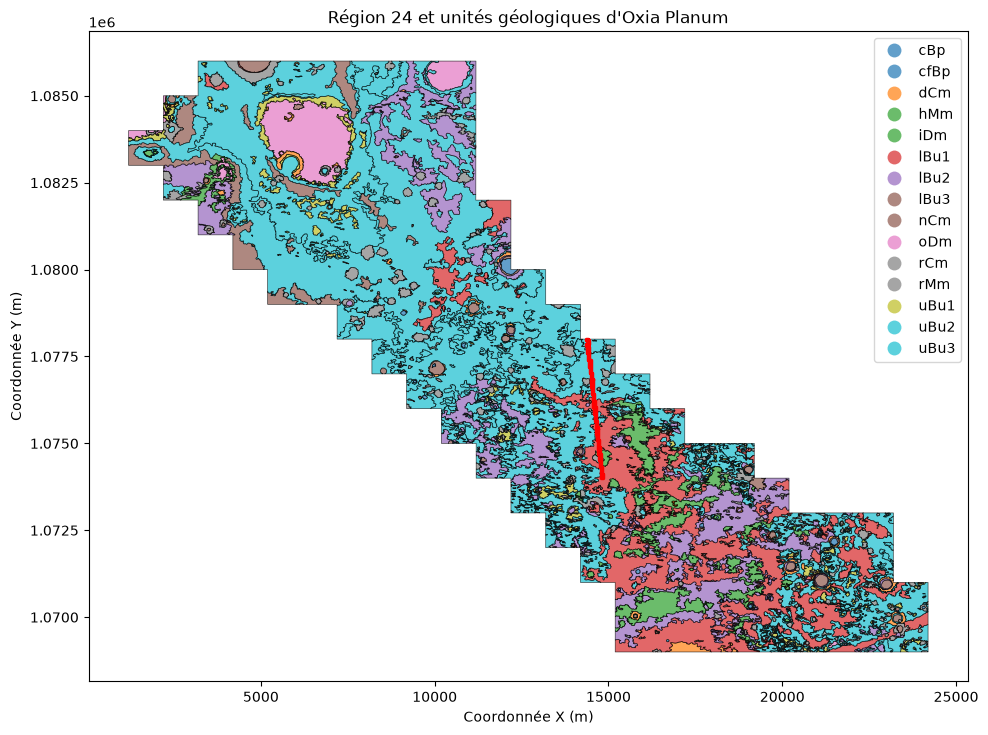

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Carte géologique
geo_units.plot(
    ax=ax,
    column="Unit_Code",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.7
)

# Région 24
gpd.GeoSeries(
    [region24_geom],
    crs=geo_units.crs
).boundary.plot(
    ax=ax,
    color="red",
    linewidth=2.5
)

ax.set_title(
    "Région 24 et unités géologiques d'Oxia Planum"
)

ax.set_xlabel("Coordonnée X (m)")
ax.set_ylabel("Coordonnée Y (m)")

plt.tight_layout()
plt.show()

In [24]:
print("=== RÉSUMÉ TEXTUEL — RÉGION 24 ===")

for unite in resultats_geo24:
    pourcentage = (
        100 * unite["Surface_intersection_km2"]
        / region24_geom.area * 1_000_000
    )

    print(
        f"{unite['Unit_Code']} | "
        f"{unite['Unit_Name']} | "
        f"{unite['Surface_intersection_km2']:.5f} km² | "
        f"{pourcentage:.2f}% de la région"
    )

=== RÉSUMÉ TEXTUEL — RÉGION 24 ===
uBu1 | Upper bedrock unit 1 | 0.00008 km² | 0.05% de la région
uBu3 | Upper bedrock unit 3 | 0.05945 km² | 36.67% de la région
rMm | Ridge mound material | 0.00400 km² | 2.47% de la région
lBu1 | Lower bedrock unit 1 | 0.05052 km² | 31.16% de la région
rCm | Recent crater material | 0.00774 km² | 4.77% de la région
uBu2 | Upper bedrock unit 2 | 0.03084 km² | 19.02% de la région
iDm | Interbedded dark material | 0.00901 km² | 5.56% de la région


In [25]:
# ============================================================
# MASTER ANALYSIS — OXIA PLANUM
# Terrain + slope + roughness + candidate regions + geology
# ============================================================

import numpy as np
import rasterio
import geopandas as gpd
from scipy import ndimage
from shapely.geometry import box
from shapely.ops import unary_union

print("=" * 70)
print("MASTER ANALYSIS — OXIA PLANUM")
print("=" * 70)


# ------------------------------------------------------------
# 1. DEM + BASIC DATA
# ------------------------------------------------------------

with rasterio.open(chemin_dem) as dem:

    transform = dem.transform
    resolution_x, resolution_y = dem.res

    altitude_master = dem.read(1, masked=True)

    altitude_array = altitude_master.filled(np.nan)

    valide_master = np.isfinite(altitude_array)

    print("\n[1] DEM")
    print(f"Dimensions : {dem.width} × {dem.height}")
    print(f"Résolution : {resolution_x:.3f} × {resolution_y:.3f} m/pixel")
    print(f"Pixels valides : {np.sum(valide_master):,}")

    print(f"Altitude min : {np.nanmin(altitude_array):.2f} m")
    print(f"Altitude max : {np.nanmax(altitude_array):.2f} m")
    print(f"Altitude moyenne : {np.nanmean(altitude_array):.2f} m")
    print(f"Altitude médiane : {np.nanmedian(altitude_array):.2f} m")


surface_pixel_m2_master = resolution_x * resolution_y
surface_pixel_km2_master = surface_pixel_m2_master / 1_000_000


# ------------------------------------------------------------
# 2. SLOPE
# ------------------------------------------------------------

gradient_y, gradient_x = np.gradient(
    altitude_array,
    resolution_y,
    resolution_x
)

pente_master = np.degrees(
    np.arctan(
        np.sqrt(
            gradient_x**2 +
            gradient_y**2
        )
    )
)

pente_master[~valide_master] = np.nan

print("\n[2] PENTE")

valeurs_pente = pente_master[np.isfinite(pente_master)]

print(f"Min : {np.min(valeurs_pente):.3f}°")
print(f"Max : {np.max(valeurs_pente):.3f}°")
print(f"Moyenne : {np.mean(valeurs_pente):.3f}°")
print(f"Médiane : {np.median(valeurs_pente):.3f}°")

for seuil in [1, 2, 5, 10, 15, 20, 30, 45, 60]:

    nombre = np.sum(pente_master >= seuil)

    print(
        f">= {seuil:2d}° : "
        f"{nombre:,} px | "
        f"{nombre * surface_pixel_km2_master:.4f} km² | "
        f"{100 * nombre / np.sum(valide_master):.3f}%"
    )


# ------------------------------------------------------------
# 3. ROUGHNESS
# ------------------------------------------------------------

# On réutilise la rugosité déjà calculée si elle existe.
# Sinon, calcul local de variabilité sur 5 × 5 pixels.

if "rugosite_detrendee" in globals():

    rugosite_master = rugosite_detrendee

    print("\n[3] RUGOSITÉ")
    print("Rugosité détrendée déjà disponible → réutilisée.")

else:

    print("\n[3] RUGOSITÉ")
    print("Rugosité détrendée absente → calcul en cours...")

    # Moyennes locales
    moyenne_locale = ndimage.uniform_filter(
        altitude_array,
        size=5,
        mode="nearest"
    )

    moyenne_carre = ndimage.uniform_filter(
        altitude_array**2,
        size=5,
        mode="nearest"
    )

    # Variance locale
    variance_locale = (
        moyenne_carre -
        moyenne_locale**2
    )

    variance_locale[
        variance_locale < 0
    ] = 0

    rugosite_master = np.sqrt(
        variance_locale
    )

    rugosite_master[~valide_master] = np.nan

    print(
        "ATTENTION : cette version mesure la "
        "variabilité locale de l'altitude."
    )

valeurs_rugosite = rugosite_master[
    np.isfinite(rugosite_master)
]

print(
    f"Min : {np.min(valeurs_rugosite):.3f} m"
)

print(
    f"Max : {np.max(valeurs_rugosite):.3f} m"
)

print(
    f"Moyenne : {np.mean(valeurs_rugosite):.3f} m"
)

print(
    f"Médiane : {np.median(valeurs_rugosite):.3f} m"
)

for percentile in [75, 90, 95, 99]:

    print(
        f"{percentile}e percentile : "
        f"{np.percentile(valeurs_rugosite, percentile):.3f} m"
    )


# ------------------------------------------------------------
# 4. ZONE CARTOGRAPHIÉE PAR LA GÉOLOGIE
# ------------------------------------------------------------

xmin_geo, ymin_geo, xmax_geo, ymax_geo = geo_units.total_bounds

with rasterio.open(chemin_dem) as dem:

    row_min_geo, col_min_geo = dem.index(
        xmin_geo,
        ymax_geo
    )

    row_max_geo, col_max_geo = dem.index(
        xmax_geo,
        ymin_geo
    )

pente_geo_master = pente_master[
    row_min_geo:row_max_geo,
    col_min_geo:col_max_geo
]

rugosite_geo_master = rugosite_master[
    row_min_geo:row_max_geo,
    col_min_geo:col_max_geo
]

altitude_geo_master = altitude_array[
    row_min_geo:row_max_geo,
    col_min_geo:col_max_geo
]


# ------------------------------------------------------------
# 5. COMPLEX TERRAIN
# ------------------------------------------------------------

zone_complexe_master = (
    np.isfinite(pente_geo_master)
    &
    np.isfinite(rugosite_geo_master)
    &
    (pente_geo_master >= 10)
    &
    (rugosite_geo_master >= 2)
)

structure_master = np.ones(
    (3, 3),
    dtype=int
)

etiquettes_master, nombre_regions_master = ndimage.label(
    zone_complexe_master,
    structure=structure_master
)

tailles_master = np.bincount(
    etiquettes_master.ravel()
)[1:]

ordre_master = np.argsort(
    tailles_master
)[::-1]

pixels_complexes_master = np.sum(
    zone_complexe_master
)

print("\n[4] TERRAIN COMPLEXE DANS LA CARTE GÉOLOGIQUE")

print(
    f"Pixels : {pixels_complexes_master:,}"
)

print(
    f"Surface : "
    f"{pixels_complexes_master * surface_pixel_km2_master:.4f} km²"
)

print(
    f"Pourcentage : "
    f"{100 * pixels_complexes_master / zone_complexe_master.size:.3f}%"
)

print(
    f"Régions connectées : "
    f"{nombre_regions_master}"
)


# ------------------------------------------------------------
# 6. TOP 10 CANDIDATES
# ------------------------------------------------------------

print("\n[5] TOP 10 RÉGIONS")

candidats_master = []

for rang, indice in enumerate(
    ordre_master[:10],
    start=1
):

    numero = indice + 1

    masque = (
        etiquettes_master ==
        numero
    )

    lignes, colonnes = np.where(
        masque
    )

    lignes_dem = (
        lignes +
        row_min_geo
    )

    colonnes_dem = (
        colonnes +
        col_min_geo
    )

    xs, ys = rasterio.transform.xy(
        transform,
        lignes_dem,
        colonnes_dem
    )

    xs = np.asarray(xs)
    ys = np.asarray(ys)

    pente_region = pente_master[
        lignes_dem,
        colonnes_dem
    ]

    rough_region = rugosite_master[
        lignes_dem,
        colonnes_dem
    ]

    alt_region = altitude_array[
        lignes_dem,
        colonnes_dem
    ]

    candidat = {
        "rang": rang,
        "numero": numero,
        "pixels": len(lignes),
        "surface_km2":
            len(lignes) *
            surface_pixel_km2_master,
        "x_centre":
            np.mean(xs),
        "y_centre":
            np.mean(ys),
        "pente_moyenne":
            np.nanmean(pente_region),
        "pente_mediane":
            np.nanmedian(pente_region),
        "pente_max":
            np.nanmax(pente_region),
        "rough_moyenne":
            np.nanmean(rough_region),
        "alt_min":
            np.nanmin(alt_region),
        "alt_max":
            np.nanmax(alt_region)
    }

    candidats_master.append(
        candidat
    )

    print(
        f"{rang:2d}. "
        f"Région {numero:2d} | "
        f"{candidat['surface_km2']:.4f} km² | "
        f"pente moy "
        f"{candidat['pente_moyenne']:.2f}° | "
        f"pente max "
        f"{candidat['pente_max']:.2f}° | "
        f"rough "
        f"{candidat['rough_moyenne']:.2f} m | "
        f"centre "
        f"({candidat['x_centre']:.0f}, "
        f"{candidat['y_centre']:.0f})"
    )


# ------------------------------------------------------------
# 7. REGION 24
# ------------------------------------------------------------

region24_numero = candidats_master[0]["numero"]

masque_region24_master = (
    etiquettes_master ==
    region24_numero
)

lignes24, colonnes24 = np.where(
    masque_region24_master
)

lignes24_dem = (
    lignes24 +
    row_min_geo
)

colonnes24_dem = (
    colonnes24 +
    col_min_geo
)

geometries_pixels24 = []

for r, c in zip(
    lignes24_dem,
    colonnes24_dem
):

    x1, y1 = rasterio.transform.xy(
        transform,
        r,
        c,
        offset="ul"
    )

    x2, y2 = rasterio.transform.xy(
        transform,
        r,
        c,
        offset="lr"
    )

    geometries_pixels24.append(
        box(
            x1,
            y2,
            x2,
            y1
        )
    )

region24_master = unary_union(
    geometries_pixels24
)

print("\n[6] CANDIDAT PRINCIPAL")

print(
    f"Région : {region24_numero}"
)

print(
    f"Surface : "
    f"{region24_master.area / 1_000_000:.4f} km²"
)

print(
    f"Centre : "
    f"({region24_master.centroid.x:.1f}, "
    f"{region24_master.centroid.y:.1f})"
)

print(
    f"X : "
    f"{region24_master.bounds[0]:.1f} → "
    f"{region24_master.bounds[2]:.1f} m"
)

print(
    f"Y : "
    f"{region24_master.bounds[1]:.1f} → "
    f"{region24_master.bounds[3]:.1f} m"
)


# ------------------------------------------------------------
# 8. REGION 24 — TERRAIN COMPLET
# ------------------------------------------------------------

pente24 = pente_master[
    lignes24_dem,
    colonnes24_dem
]

rough24 = rugosite_master[
    lignes24_dem,
    colonnes24_dem
]

alt24 = altitude_array[
    lignes24_dem,
    colonnes24_dem
]

print("\n[7] RÉGION 24 — TERRAIN")

print(
    f"Pente moyenne : "
    f"{np.nanmean(pente24):.2f}°"
)

print(
    f"Pente médiane : "
    f"{np.nanmedian(pente24):.2f}°"
)

print(
    f"Pente maximale : "
    f"{np.nanmax(pente24):.2f}°"
)

print(
    f"Altitude min : "
    f"{np.nanmin(alt24):.2f} m"
)

print(
    f"Altitude max : "
    f"{np.nanmax(alt24):.2f} m"
)

print(
    f"Relief interne : "
    f"{np.nanmax(alt24) - np.nanmin(alt24):.2f} m"
)

print(
    f"Rugosité moyenne : "
    f"{np.nanmean(rough24):.2f} m"
)

print(
    f"Rugosité médiane : "
    f"{np.nanmedian(rough24):.2f} m"
)

for seuil in [10, 20, 30, 45]:

    nombre = np.sum(
        pente24 >= seuil
    )

    print(
        f"Pente >= {seuil}° : "
        f"{100 * nombre / len(pente24):.2f}%"
    )


# ------------------------------------------------------------
# 9. REGION 24 — GÉOLOGIE
# ------------------------------------------------------------

print("\n[8] RÉGION 24 — GÉOLOGIE")

resultats_geo_master = []

for _, unite in geo_units.iterrows():

    intersection = (
        region24_master.intersection(
            unite.geometry
        )
    )

    if (
        not intersection.is_empty
        and intersection.area > 0
    ):

        surface = (
            intersection.area /
            1_000_000
        )

        pourcentage = (
            100 *
            surface /
            (region24_master.area /
             1_000_000)
        )

        resultats_geo_master.append({
            "code":
                unite["Unit_Code"],
            "nom":
                unite["Unit_Name"],
            "groupe":
                unite["Unit_Group"],
            "surface_km2":
                surface,
            "pourcentage":
                pourcentage
        })

        print(
            f"{unite['Unit_Code']:5s} | "
            f"{surface:.5f} km² | "
            f"{pourcentage:.2f}%"
        )


# ------------------------------------------------------------
# 10. SCIENTIFIC DIVERSITY SUMMARY
# ------------------------------------------------------------

print("\n[9] SYNTHÈSE")

print(
    f"Nombre d'unités géologiques : "
    f"{len(resultats_geo_master)}"
)

print(
    f"Surface candidate : "
    f"{region24_master.area / 1_000_000:.4f} km²"
)

print(
    "Terrain complexe : "
    f"pente >=10° + rugosité >=2 m"
)

print(
    "ATTENTION : ces seuils sont "
    "nos critères analytiques, pas des limites "
    "officielles de mobilité d'ESA."
)

print("\n" + "=" * 70)
print("ANALYSE TERMINÉE")
print("=" * 70)

MASTER ANALYSIS — OXIA PLANUM

[1] DEM
Dimensions : 5935 × 6018
Résolution : 20.234 × 20.234 m/pixel
Pixels valides : 21,274,732
Altitude min : -3239.99 m
Altitude max : -2403.87 m
Altitude moyenne : -2980.74 m
Altitude médiane : -3018.20 m

[2] PENTE
Min : 0.000°
Max : 65.962°
Moyenne : 2.665°
Médiane : 1.969°
>=  1° : 17,192,584 px | 7038.9798 km² | 80.812%
>=  2° : 10,443,894 px | 4275.9343 km² | 49.091%
>=  5° : 2,191,185 px | 897.1140 km² | 10.299%
>= 10° : 484,722 px | 198.4547 km² | 2.278%
>= 15° : 182,498 px | 74.7182 km² | 0.858%
>= 20° : 82,734 px | 33.8729 km² | 0.389%
>= 30° : 14,355 px | 5.8772 km² | 0.067%
>= 45° : 625 px | 0.2559 km² | 0.003%
>= 60° : 8 px | 0.0033 km² | 0.000%

[3] RUGOSITÉ
Rugosité détrendée déjà disponible → réutilisée.
Min : 0.000 m
Max : 18.853 m
Moyenne : 0.391 m
Médiane : 0.309 m
75e percentile : 0.466 m
90e percentile : 0.694 m
95e percentile : 0.906 m
99e percentile : 1.636 m

[4] TERRAIN COMPLEXE DANS LA CARTE GÉOLOGIQUE
Pixels : 1,189
Surface 

In [26]:
# ============================================================
# FINAL CANDIDATE COMPARISON
# Geological diversity + terrain + surrounding accessibility
# ============================================================

import numpy as np
import rasterio
from scipy import ndimage
from shapely.geometry import box
from shapely.ops import unary_union

print("=" * 75)
print("COMPARAISON DES CANDIDATS — OXIA PLANUM")
print("=" * 75)


# ------------------------------------------------------------
# FONCTION : transformer une région raster en géométrie
# ------------------------------------------------------------

def geometrie_region(numero_region):

    masque = (
        etiquettes_master ==
        numero_region
    )

    lignes, colonnes = np.where(masque)

    lignes_dem = (
        lignes +
        row_min_geo
    )

    colonnes_dem = (
        colonnes +
        col_min_geo
    )

    geometries = []

    for r, c in zip(
        lignes_dem,
        colonnes_dem
    ):

        x1, y1 = rasterio.transform.xy(
            transform,
            r,
            c,
            offset="ul"
        )

        x2, y2 = rasterio.transform.xy(
            transform,
            r,
            c,
            offset="lr"
        )

        geometries.append(
            box(
                x1,
                y2,
                x2,
                y1
            )
        )

    return unary_union(geometries)


# ------------------------------------------------------------
# ANALYSE DES 5 PLUS GRANDES RÉGIONS
# ------------------------------------------------------------

resultats_candidats = []

print("\n=== CANDIDATS ===")

for rang, indice in enumerate(
    ordre_master[:5],
    start=1
):

    numero = indice + 1

    geometrie = geometrie_region(
        numero
    )

    masque = (
        etiquettes_master ==
        numero
    )

    lignes, colonnes = np.where(
        masque
    )

    lignes_dem = (
        lignes +
        row_min_geo
    )

    colonnes_dem = (
        colonnes +
        col_min_geo
    )

    pente = pente_master[
        lignes_dem,
        colonnes_dem
    ]

    rough = rugosite_master[
        lignes_dem,
        colonnes_dem
    ]

    altitude = altitude_array[
        lignes_dem,
        colonnes_dem
    ]

    surface = (
        geometrie.area /
        1_000_000
    )

    # -----------------------------
    # Statistiques de pente
    # -----------------------------

    pente_stats = {}

    for seuil in [
        10, 15, 20, 25, 30, 35, 45
    ]:

        pente_stats[seuil] = (
            100 *
            np.sum(pente >= seuil) /
            len(pente)
        )

    # -----------------------------
    # Statistiques de rugosité
    # -----------------------------

    rough_stats = {
        "moyenne":
            np.nanmean(rough),
        "mediane":
            np.nanmedian(rough),
        "p90":
            np.nanpercentile(rough, 90),
        "p95":
            np.nanpercentile(rough, 95),
        "max":
            np.nanmax(rough)
    }

    # -----------------------------
    # Géologie
    # -----------------------------

    unites = []

    surfaces_geo = []

    for _, unite in geo_units.iterrows():

        intersection = (
            geometrie.intersection(
                unite.geometry
            )
        )

        if (
            not intersection.is_empty
            and intersection.area > 0
        ):

            surface_geo = (
                intersection.area /
                1_000_000
            )

            unites.append(
                unite["Unit_Code"]
            )

            surfaces_geo.append(
                surface_geo
            )

    # -----------------------------
    # Frontières géologiques
    # -----------------------------

    # Nombre d'unités distinctes
    diversite_geo = len(
        set(unites)
    )

    # -----------------------------
    # Zone de 1 km autour du centre
    # -----------------------------

    centre_x = geometrie.centroid.x
    centre_y = geometrie.centroid.y

    with rasterio.open(chemin_dem) as dem:

        r_centre, c_centre = dem.index(
            centre_x,
            centre_y
        )

    rayon_pixels = int(
        1000 /
        resolution_x
    )

    r1 = max(
        0,
        r_centre - rayon_pixels
    )

    r2 = min(
        pente_master.shape[0],
        r_centre + rayon_pixels + 1
    )

    c1 = max(
        0,
        c_centre - rayon_pixels
    )

    c2 = min(
        pente_master.shape[1],
        c_centre + rayon_pixels + 1
    )

    pente_autour = pente_master[
        r1:r2,
        c1:c2
    ]

    pente_autour = pente_autour[
        np.isfinite(pente_autour)
    ]

    # -----------------------------
    # Stockage
    # -----------------------------

    resultat = {

        "rang":
            rang,

        "region":
            numero,

        "surface_km2":
            surface,

        "centre_x":
            centre_x,

        "centre_y":
            centre_y,

        "unites_geo":
            diversite_geo,

        "pente_moy":
            np.nanmean(pente),

        "pente_med":
            np.nanmedian(pente),

        "pente_max":
            np.nanmax(pente),

        "rough_moy":
            rough_stats["moyenne"],

        "rough_med":
            rough_stats["mediane"],

        "rough_p90":
            rough_stats["p90"],

        "rough_p95":
            rough_stats["p95"],

        "rough_max":
            rough_stats["max"],

        "alt_min":
            np.nanmin(altitude),

        "alt_max":
            np.nanmax(altitude),

        "relief":
            np.nanmax(altitude)
            -
            np.nanmin(altitude),

        "pente_stats":
            pente_stats,

        "unites":
            sorted(set(unites))
    }

    resultats_candidats.append(
        resultat
    )

    # --------------------------------------------------------
    # AFFICHAGE
    # --------------------------------------------------------

    print()
    print(
        f"RÉGION {numero} "
        f"(#{rang})"
    )

    print(
        f"Surface : "
        f"{surface:.4f} km²"
    )

    print(
        f"Centre : "
        f"({centre_x:.1f}, "
        f"{centre_y:.1f})"
    )

    print(
        f"Unités géologiques : "
        f"{diversite_geo}"
    )

    print(
        f"Unités : "
        f"{', '.join(sorted(set(unites)))}"
    )

    print(
        f"Pente : "
        f"{np.nanmean(pente):.2f}° moy | "
        f"{np.nanmedian(pente):.2f}° méd | "
        f"{np.nanmax(pente):.2f}° max"
    )

    print(
        f"Rugosité : "
        f"{rough_stats['moyenne']:.2f} m moy | "
        f"{rough_stats['p95']:.2f} m P95"
    )

    print(
        f"Relief : "
        f"{np.nanmax(altitude) - np.nanmin(altitude):.2f} m"
    )

    print(
        "Pente ≥20° : "
        f"{pente_stats[20]:.2f}%"
    )

    print(
        "Pente ≥30° : "
        f"{pente_stats[30]:.2f}%"
    )

    print(
        "Pente ≥45° : "
        f"{pente_stats[45]:.2f}%"
    )


# ------------------------------------------------------------
# TABLEAU SYNTHÉTIQUE
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("TABLEAU COMPARATIF")
print("=" * 75)

print(
    "Région | Surface | Unités | "
    "Pente moy | Pente ≥20 | Pente ≥30 | "
    "Rugosité moy | Relief"
)

print("-" * 75)

for r in resultats_candidats:

    print(
        f"{r['region']:6d} | "
        f"{r['surface_km2']:7.4f} | "
        f"{r['unites_geo']:6d} | "
        f"{r['pente_moy']:9.2f}° | "
        f"{r['pente_stats'][20]:9.2f}% | "
        f"{r['pente_stats'][30]:9.2f}% | "
        f"{r['rough_moy']:12.2f} m | "
        f"{r['relief']:6.2f} m"
    )


# ------------------------------------------------------------
# REGION 24 — DÉTAIL GÉOLOGIQUE
# ------------------------------------------------------------

region24_resultat = resultats_candidats[0]

print("\n")
print("=" * 75)
print("RÉGION 24 — DÉTAIL GÉOLOGIQUE")
print("=" * 75)

for _, unite in geo_units.iterrows():

    intersection = (
        region24_master.intersection(
            unite.geometry
        )
    )

    if (
        not intersection.is_empty
        and intersection.area > 0
    ):

        surface = (
            intersection.area /
            1_000_000
        )

        pourcentage = (
            100 *
            surface /
            region24_master.area *
            1_000_000
        )

        print(
            f"{unite['Unit_Code']:5s} | "
            f"{surface:.5f} km² | "
            f"{pourcentage:.2f}%"
        )


# ------------------------------------------------------------
# CONTRÔLE FINAL
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("CONTRÔLE SCIENTIFIQUE")
print("=" * 75)

print(
    "Les critères de terrain sont : "
    "pente ≥10° et rugosité ≥2 m."
)

print(
    "Ils sont définis par notre analyse "
    "et ne constituent PAS des limites "
    "officielles du rover."
)

print(
    "La diversité géologique correspond "
    "au nombre d'unités cartographiques "
    "intersectant chaque région."
)

print(
    "Aucun score scientifique global "
    "n'est imposé à ce stade."
)

print("=" * 75)
print("COMPARAISON TERMINÉE")
print("=" * 75)

COMPARAISON DES CANDIDATS — OXIA PLANUM

=== CANDIDATS ===

RÉGION 24 (#1)
Surface : 0.1621 km²
Centre : (14601.1, 1076003.5)
Unités géologiques : 7
Unités : iDm, lBu1, rCm, rMm, uBu1, uBu2, uBu3
Pente : 20.44° moy | 19.64° méd | 38.80° max
Rugosité : 3.70 m moy | 5.74 m P95
Relief : 52.57 m
Pente ≥20° : 47.22%
Pente ≥30° : 5.30%
Pente ≥45° : 0.00%

RÉGION 9 (#2)
Surface : 0.1126 km²
Centre : (13894.3, 1082379.5)
Unités géologiques : 0
Unités : 
Pente : 19.49° moy | 19.58° méd | 33.81° max
Rugosité : 3.62 m moy | 5.04 m P95
Relief : 32.90 m
Pente ≥20° : 44.36%
Pente ≥30° : 2.91%
Pente ≥45° : 0.00%

RÉGION 34 (#3)
Surface : 0.0655 km²
Centre : (15100.4, 1071466.4)
Unités géologiques : 3
Unités : lBu1, rMm, uBu2
Pente : 18.70° moy | 18.85° méd | 30.49° max
Rugosité : 3.39 m moy | 4.17 m P95
Relief : 23.95 m
Pente ≥20° : 34.38%
Pente ≥30° : 1.25%
Pente ≥45° : 0.00%

RÉGION 38 (#4)
Surface : 0.0401 km²
Centre : (15324.8, 1069503.7)
Unités géologiques : 3
Unités : iDm, lBu1, lBu2
Pente : 20

In [27]:
# ============================================================
# GÉOLOGIE × TOPOGRAPHIE
# Distance aux frontières géologiques — Région 24
# ============================================================

from shapely.ops import unary_union

print("=" * 70)
print("RÉGION 24 — FRONTIÈRES GÉOLOGIQUES")
print("=" * 70)

# Toutes les frontières entre unités
frontieres = unary_union(
    geo_units.geometry.boundary
)

# Distance de chaque pixel complexe à une frontière
distances = []

with rasterio.open(chemin_dem) as dem:
    transform = dem.transform

    for r, c in zip(
        lignes24_dem,
        colonnes24_dem
    ):

        x, y = rasterio.transform.xy(
            transform,
            r,
            c
        )

        distance = frontieres.distance(
            gpd.points_from_xy(
                [x],
                [y]
            ).iloc[0]
        )

        distances.append(distance)

distances = np.asarray(distances)

print(
    f"Distance minimale : "
    f"{np.min(distances):.2f} m"
)

print(
    f"Distance moyenne : "
    f"{np.mean(distances):.2f} m"
)

print(
    f"Médiane : "
    f"{np.median(distances):.2f} m"
)

for seuil in [20, 50, 100, 200]:

    pourcentage = (
        100 *
        np.sum(distances <= seuil) /
        len(distances)
    )

    print(
        f"À moins de {seuil:3d} m "
        f"d'une frontière : "
        f"{pourcentage:.2f}%"
    )

RÉGION 24 — FRONTIÈRES GÉOLOGIQUES


AttributeError: 'GeometryArray' object has no attribute 'iloc'

In [28]:
from shapely.ops import unary_union
from shapely.geometry import Point

print("=" * 70)
print("RÉGION 24 — FRONTIÈRES GÉOLOGIQUES")
print("=" * 70)

frontieres = unary_union(
    geo_units.geometry.boundary
)

distances = []

with rasterio.open(chemin_dem) as dem:
    transform = dem.transform

    for r, c in zip(
        lignes24_dem,
        colonnes24_dem
    ):

        x, y = rasterio.transform.xy(
            transform,
            r,
            c
        )

        point = Point(x, y)

        distance = frontieres.distance(point)

        distances.append(distance)

distances = np.asarray(distances)

print(f"Distance minimale : {np.min(distances):.2f} m")
print(f"Distance moyenne : {np.mean(distances):.2f} m")
print(f"Médiane : {np.median(distances):.2f} m")

for seuil in [20, 50, 100, 200]:

    pourcentage = (
        100 *
        np.sum(distances <= seuil) /
        len(distances)
    )

    print(
        f"À moins de {seuil:3d} m d'une frontière : "
        f"{pourcentage:.2f}%"
    )

RÉGION 24 — FRONTIÈRES GÉOLOGIQUES
Distance minimale : 0.09 m
Distance moyenne : 63.31 m
Médiane : 37.87 m
À moins de  20 m d'une frontière : 30.05%
À moins de  50 m d'une frontière : 62.37%
À moins de 100 m d'une frontière : 83.08%
À moins de 200 m d'une frontière : 91.16%


In [1]:
# ============================================================
# PHYSIQUE — OXIA PLANUM / ROSALIND FRANKLIN
# Forces gravitationnelles, pente, énergie et traction
# ============================================================

import numpy as np

# Sources:
# NASA: g Mars ≈ 3.7 m/s²
# ESA: masse du rover Rosalind Franklin = 310 kg
#
# Modèle statique idéal — pas une limite officielle ESA.

g_mars = 3.7
g_terre = 9.80665
masse_rover = 310.0

poids_mars = masse_rover * g_mars
poids_terre = masse_rover * g_terre

scenarios_pente = {
    "Seuil analytique 10°": 10.0,
    "Seuil de comparaison 20°": 20.0,
    "Région 24 — pente moyenne": 20.44,
    "Seuil de comparaison 30°": 30.0,
    "Région 24 — pente maximale": 38.80,
}

print("=" * 72)
print("PHYSIQUE — OXIA PLANUM / ROSALIND FRANKLIN")
print("=" * 72)
print(f"Masse considérée : {masse_rover:.0f} kg (ESA)")
print(f"Gravité martienne : {g_mars:.1f} m/s²")
print(f"Poids statique sur Mars : {poids_mars:.1f} N")
print(f"Poids statique sur Terre : {poids_terre:.1f} N")
print(f"Rapport Mars / Terre : {poids_mars / poids_terre:.3f}")

print("\nFORCES SUR UNE PENTE — MODÈLE STATIQUE IDÉAL")
print("Angle | F parallèle (N) | F normale (N) | μ minimal = tan(θ)")
print("-" * 72)

resultats_physique = []

for nom, angle_deg in scenarios_pente.items():
    angle_rad = np.deg2rad(angle_deg)
    force_parallele = poids_mars * np.sin(angle_rad)
    force_normale = poids_mars * np.cos(angle_rad)
    mu_min = np.tan(angle_rad)

    resultats_physique.append({
        "scenario": nom,
        "angle_deg": angle_deg,
        "force_parallele_N": force_parallele,
        "force_normale_N": force_normale,
        "mu_min_ideal": mu_min,
    })

    print(
        f"{angle_deg:5.2f}° | {force_parallele:16.1f} | "
        f"{force_normale:13.1f} | {mu_min:18.3f}  ({nom})"
    )

relief_region24_m = 52.57
energie_par_metre_vertical = poids_mars
energie_pour_relief_entier = poids_mars * relief_region24_m

print("\nÉNERGIE POTENTIELLE GRAVITATIONNELLE")
print(f"Énergie pour gagner 1 m vertical : {energie_par_metre_vertical:.1f} J")
print(
    f"Borne pour {relief_region24_m:.2f} m de dénivelé : "
    f"{energie_pour_relief_entier / 1000:.2f} kJ"
)

print("\nLECTURE CORRECTE")
print("- Modèle statique idéal : sol, glissement, roues, route et dynamique non inclus.")
print("- μ minimal est le seuil théorique de non-glissement sur un plan incliné.")
print("- Les seuils ne sont PAS des limites officielles de mobilité ESA.")
print("- L’énergie calculée n’est pas la consommation électrique totale du rover.")

PHYSIQUE — OXIA PLANUM / ROSALIND FRANKLIN
Masse considérée : 310 kg (ESA)
Gravité martienne : 3.7 m/s²
Poids statique sur Mars : 1147.0 N
Poids statique sur Terre : 3040.1 N
Rapport Mars / Terre : 0.377

FORCES SUR UNE PENTE — MODÈLE STATIQUE IDÉAL
Angle | F parallèle (N) | F normale (N) | μ minimal = tan(θ)
------------------------------------------------------------------------
10.00° |            199.2 |        1129.6 |              0.176  (Seuil analytique 10°)
20.00° |            392.3 |        1077.8 |              0.364  (Seuil de comparaison 20°)
20.44° |            400.6 |        1074.8 |              0.373  (Région 24 — pente moyenne)
30.00° |            573.5 |         993.3 |              0.577  (Seuil de comparaison 30°)
38.80° |            718.7 |         893.9 |              0.804  (Région 24 — pente maximale)

ÉNERGIE POTENTIELLE GRAVITATIONNELLE
Énergie pour gagner 1 m vertical : 1147.0 J
Borne pour 52.57 m de dénivelé : 60.30 kJ

LECTURE CORRECTE
- Modèle statique id

In [2]:
# ============================================================
# PHYSIQUE APPROFONDIE — RÉGION 24
# Pente, traction, forces, énergie et limites de résolution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Sources factuelles :
# NASA — Mars surface gravity ≈ 3.7 m/s²:
# https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/mars/
#
# ESA — Rosalind Franklin rover mass = 310 kg:
# https://www.esa.int/Science_Exploration/Human_and_Robotic_Exploration/Exploration/ExoMars/ExoMars_Factsheet
#
# IMPORTANT:
# - These are static, idealized physics calculations.
# - Friction scenarios are sensitivity tests, NOT measured Oxia Planum soil values.
# - They are NOT official ESA rover mobility limits.

# ------------------------------------------------------------
# 1. Inputs and assumptions
# ------------------------------------------------------------

g_mars = 3.7
masse_rover = 310.0
poids_mars = masse_rover * g_mars

resolution_dem_m = 20.234
relief_region24_m = 52.57

# Requires the existing Region 24 terrain cell to have been run.
if "pente24" not in globals():
    raise RuntimeError(
        "Run the Region 24 terrain-analysis cell first: variable 'pente24' is missing."
    )

pentes_region24 = np.asarray(pente24)
pentes_region24 = pentes_region24[np.isfinite(pentes_region24)]

if len(pentes_region24) == 0:
    raise RuntimeError("No valid Region 24 slope values were found.")

pente_moyenne = np.mean(pentes_region24)
pente_mediane = np.median(pentes_region24)
pente_max = np.max(pentes_region24)

# Illustrative available-friction scenarios.
# They are deliberately generic; no Oxia soil property is being claimed.
scenarios_mu = {
    "μ disponible = 0.30": 0.30,
    "μ disponible = 0.50": 0.50,
    "μ disponible = 0.70": 0.70,
}

angles = np.linspace(0.1, 45, 500)
angles_rad = np.deg2rad(angles)

force_parallele = poids_mars * np.sin(angles_rad)
force_normale = poids_mars * np.cos(angles_rad)
mu_requis = np.tan(angles_rad)

# ------------------------------------------------------------
# 2. Region 24 slope statistics
# ------------------------------------------------------------

seuils = [10, 15, 20, 25, 30, 35, 38, 40]

print("=" * 78)
print("PHYSIQUE APPROFONDIE — RÉGION 24")
print("=" * 78)
print(f"Masse du rover : {masse_rover:.0f} kg")
print(f"Gravité martienne utilisée : {g_mars:.1f} m/s²")
print(f"Poids statique sur Mars : {poids_mars:.1f} N")
print(f"Résolution horizontale du DEM : {resolution_dem_m:.3f} m/pixel")
print()

print("PENTES DE LA RÉGION 24")
print(f"Pixels valides : {len(pentes_region24):,}")
print(f"Pente moyenne : {pente_moyenne:.2f}°")
print(f"Pente médiane : {pente_mediane:.2f}°")
print(f"Pente maximale : {pente_max:.2f}°")
print()

print("PROPORTION DE LA RÉGION 24 AU-DESSUS DES SEUILS")
for seuil in seuils:
    proportion = 100 * np.mean(pentes_region24 >= seuil)
    print(f"Pente ≥ {seuil:2d}° : {proportion:6.2f}%")

# ------------------------------------------------------------
# 3. Forces at representative Region 24 slopes
# ------------------------------------------------------------

angles_region24 = {
    "Médiane Région 24": pente_mediane,
    "Moyenne Région 24": pente_moyenne,
    "Maximum Région 24": pente_max,
}

print("\nFORCES REPRÉSENTATIVES — MODÈLE STATIQUE IDÉAL")
print("Cas | Angle | F parallèle | F normale | μ requis")
print("-" * 78)

for nom, angle_deg in angles_region24.items():
    angle_rad = np.deg2rad(angle_deg)

    f_parallel = poids_mars * np.sin(angle_rad)
    f_normal = poids_mars * np.cos(angle_rad)
    mu_min = np.tan(angle_rad)

    print(
        f"{nom:24s} | {angle_deg:5.2f}° | "
        f"{f_parallel:10.1f} N | {f_normal:9.1f} N | {mu_min:.3f}"
    )

# ------------------------------------------------------------
# 4. Traction sensitivity
# ------------------------------------------------------------

print("\nSENSIBILITÉ À LA TRACTION")
print("μ disponible | pente théorique maximale sans glissement")
print("-" * 78)

for nom, mu_disponible in scenarios_mu.items():
    angle_limite = np.rad2deg(np.arctan(mu_disponible))

    proportion_sous_limite = 100 * np.mean(
        pentes_region24 <= angle_limite
    )

    print(
        f"{nom:22s} | {angle_limite:6.2f}° | "
        f"{proportion_sous_limite:6.2f}% des pixels de Région 24"
    )

# ------------------------------------------------------------
# 5. Gravitational potential energy
# ------------------------------------------------------------

gains_verticaux = np.array([1, 5, 10, 25, relief_region24_m])
energies_kj = masse_rover * g_mars * gains_verticaux / 1000

print("\nÉNERGIE POTENTIELLE GRAVITATIONNELLE")
print("Gain vertical | Énergie minimale idéale")
print("-" * 78)

for gain, energie in zip(gains_verticaux, energies_kj):
    print(f"{gain:12.2f} m | {energie:8.2f} kJ")

print(
    "\nAttention : 52.57 m est le relief interne de la région, "
    "pas un itinéraire réel ni une montée continue."
)

# ------------------------------------------------------------
# 6. Figures
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Oxia Planum — Région 24 : physique de pente et sensibilité à la traction",
    fontsize=16,
    fontweight="bold"
)

# Figure A — forces
ax = axes[0, 0]

ax.plot(
    angles,
    force_parallele,
    label="Force parallèle à la pente",
    linewidth=2.5
)

ax.plot(
    angles,
    force_normale,
    label="Force normale",
    linewidth=2.5
)

for nom, angle_deg in angles_region24.items():
    f_parallel = poids_mars * np.sin(np.deg2rad(angle_deg))

    ax.scatter(angle_deg, f_parallel, s=70, zorder=3)
    ax.annotate(
        nom,
        (angle_deg, f_parallel),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("A. Composantes du poids selon la pente")
ax.set_xlabel("Pente (degrés)")
ax.set_ylabel("Force (N)")
ax.set_xlim(0, 45)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend()

# Figure B — friction requirement
ax = axes[0, 1]

ax.plot(
    angles,
    mu_requis,
    label="μ minimal requis = tan(θ)",
    linewidth=2.5
)

for nom, mu_disponible in scenarios_mu.items():
    angle_limite = np.rad2deg(np.arctan(mu_disponible))

    ax.axhline(
        mu_disponible,
        linestyle="--",
        linewidth=1.8,
        label=f"{nom} → limite idéale {angle_limite:.1f}°"
    )

for nom, angle_deg in angles_region24.items():
    ax.scatter(
        angle_deg,
        np.tan(np.deg2rad(angle_deg)),
        s=70,
        zorder=3
    )

ax.set_title("B. Traction théorique requise")
ax.set_xlabel("Pente (degrés)")
ax.set_ylabel("Coefficient de friction μ")
ax.set_xlim(0, 45)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# Figure C — slope distribution
ax = axes[1, 0]

bins = np.arange(10, 46, 2)

ax.hist(
    pentes_region24,
    bins=bins,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    pente_moyenne,
    linestyle="--",
    linewidth=2,
    label=f"Moyenne : {pente_moyenne:.2f}°"
)

ax.axvline(
    pente_mediane,
    linestyle=":",
    linewidth=2,
    label=f"Médiane : {pente_mediane:.2f}°"
)

ax.axvline(
    pente_max,
    linestyle="-.",
    linewidth=2,
    label=f"Maximum : {pente_max:.2f}°"
)

ax.set_title("C. Distribution des pentes de Région 24")
ax.set_xlabel("Pente (degrés)")
ax.set_ylabel("Nombre de pixels")
ax.grid(alpha=0.3)
ax.legend()

# Figure D — energy
ax = axes[1, 1]

vertical_range = np.linspace(0, relief_region24_m, 200)
energy_range_kj = masse_rover * g_mars * vertical_range / 1000

ax.plot(
    vertical_range,
    energy_range_kj,
    linewidth=2.5
)

ax.scatter(
    relief_region24_m,
    energies_kj[-1],
    s=80,
    zorder=3
)

ax.annotate(
    f"Relief interne : {relief_region24_m:.2f} m\n"
    f"{energies_kj[-1]:.2f} kJ",
    (relief_region24_m, energies_kj[-1]),
    xytext=(-135, -35),
    textcoords="offset points",
    fontsize=10
)

ax.set_title("D. Énergie gravitationnelle minimale")
ax.set_xlabel("Gain vertical (m)")
ax.set_ylabel("Énergie potentielle minimale (kJ)")
ax.set_xlim(0, relief_region24_m * 1.08)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Interpretation boundaries
# ------------------------------------------------------------

print("\nLIMITES D’INTERPRÉTATION")
print(
    f"- Le DEM échantillonne le terrain à ~{resolution_dem_m:.1f} m/pixel : "
    "les petites pierres, les roues et les obstacles locaux ne sont pas résolus."
)
print(
    "- Une pente dérivée du DEM dépend de la méthode de calcul, "
    "de la résolution et de l’enregistrement spatial."
)
print(
    "- La traction réelle dépend du régolithe, des roches, des roues, "
    "du glissement, de la charge dynamique et de la stratégie de conduite."
)
print(
    "- Ces résultats montrent une contrainte physique potentielle; "
    "ils ne prouvent pas qu’une route est praticable ou impraticable."
)

RuntimeError: Run the Region 24 terrain-analysis cell first: variable 'pente24' is missing.

PHYSIQUE APPROFONDIE — RÉGION 24
Masse considérée : 310 kg
Gravité martienne : 3.7 m/s²
Poids statique sur Mars : 1147.0 N
Résolution du DEM : 20.234 m/pixel

FORCES REPRÉSENTATIVES — MODÈLE STATIQUE IDÉAL
Cas       | Pente  | F parallèle | F normale | μ requis
----------------------------------------------------------------------------
Médiane   | 19.64° |      385.5 N |    1080.3 N | 0.357
Moyenne   | 20.44° |      400.6 N |    1074.8 N | 0.373
Maximum   | 38.80° |      718.7 N |     893.9 N | 0.804

SENSIBILITÉ À LA TRACTION
Scénario | pente théorique maximale | lecture pour Région 24
----------------------------------------------------------------------------
μ = 0.30 |  16.70°                 | ne couvre pas la pente moyenne
μ = 0.50 |  26.57°                 | couvre la pente moyenne, pas tous les pixels
μ = 0.70 |  34.99°                 | couvre la pente moyenne, pas tous les pixels

ÉNERGIE POTENTIELLE GRAVITATIONNELLE
Gain vertical de  1.00 m :   1.15 kJ
Gain vertical de  5.0

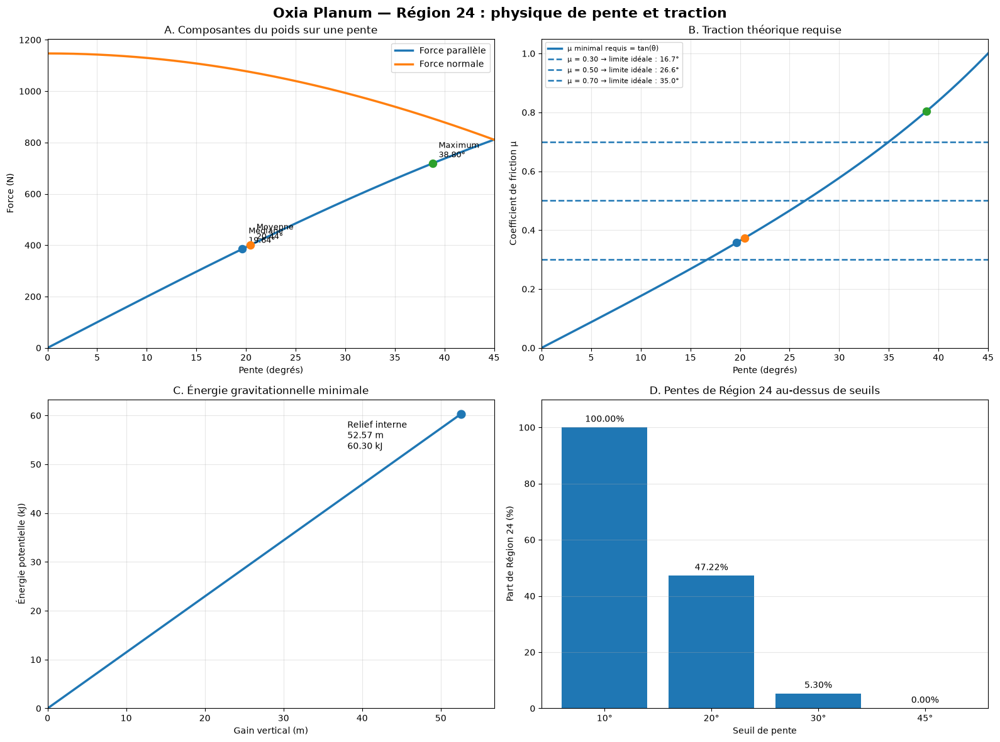


LIMITES D’INTERPRÉTATION
- Le DEM échantillonne ~20.2 m/pixel : les petits obstacles et les contacts roue-sol ne sont pas résolus.
- μ représente une sensibilité théorique : aucune propriété mécanique du sol d’Oxia Planum n’est affirmée ici.
- Le relief de 52.57 m n’est pas une route réelle ni une montée continue.
- Une future analyse de route devra employer les données raster complètes, les pentes locales, la rugosité et les contraintes de navigation.


In [3]:
# ============================================================
# PHYSIQUE APPROFONDIE — RÉGION 24 (AUTONOME)
# Forces, traction, énergie et contraintes de pente
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# SOURCES FACTUELLES
# NASA: Mars surface gravity ≈ 3.7 m/s²
# https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/mars/
#
# ESA: Rosalind Franklin rover mass = 310 kg
# https://www.esa.int/Science_Exploration/Human_and_Robotic_Exploration/Exploration/ExoMars/ExoMars_Factsheet
#
# These are idealized static calculations.
# They are NOT official ESA mobility limits.

# ------------------------------------------------------------
# 1. Validated project inputs
# ------------------------------------------------------------

g_mars = 3.7
masse_rover = 310.0
poids_mars = masse_rover * g_mars

# Region 24 results already measured in this project
pente_mediane = 19.64
pente_moyenne = 20.44
pente_max = 38.80

relief_region24_m = 52.57
resolution_dem_m = 20.234

# Exact threshold percentages already measured for Region 24
seuils_pente = np.array([10, 20, 30, 45])
pourcentages_pente = np.array([100.00, 47.22, 5.30, 0.00])

# Generic sensitivity scenarios — NOT measured Oxia soil values
scenarios_mu = {
    "μ = 0.30": 0.30,
    "μ = 0.50": 0.50,
    "μ = 0.70": 0.70,
}

angles_region24 = {
    "Médiane": pente_mediane,
    "Moyenne": pente_moyenne,
    "Maximum": pente_max,
}

# ------------------------------------------------------------
# 2. Calculations
# ------------------------------------------------------------

print("=" * 76)
print("PHYSIQUE APPROFONDIE — RÉGION 24")
print("=" * 76)
print(f"Masse considérée : {masse_rover:.0f} kg")
print(f"Gravité martienne : {g_mars:.1f} m/s²")
print(f"Poids statique sur Mars : {poids_mars:.1f} N")
print(f"Résolution du DEM : {resolution_dem_m:.3f} m/pixel")
print()

print("FORCES REPRÉSENTATIVES — MODÈLE STATIQUE IDÉAL")
print("Cas       | Pente  | F parallèle | F normale | μ requis")
print("-" * 76)

for nom, angle_deg in angles_region24.items():
    angle_rad = np.deg2rad(angle_deg)

    f_parallele = poids_mars * np.sin(angle_rad)
    f_normale = poids_mars * np.cos(angle_rad)
    mu_requis = np.tan(angle_rad)

    print(
        f"{nom:9s} | {angle_deg:5.2f}° | "
        f"{f_parallele:10.1f} N | {f_normale:9.1f} N | "
        f"{mu_requis:.3f}"
    )

print("\nSENSIBILITÉ À LA TRACTION")
print("Scénario | pente théorique maximale | lecture pour Région 24")
print("-" * 76)

for nom, mu_disponible in scenarios_mu.items():
    angle_limite = np.rad2deg(np.arctan(mu_disponible))

    if angle_limite >= pente_max:
        lecture = "couvre même la pente maximale mesurée"
    elif angle_limite >= pente_moyenne:
        lecture = "couvre la pente moyenne, pas tous les pixels"
    else:
        lecture = "ne couvre pas la pente moyenne"

    print(
        f"{nom:8s} | {angle_limite:6.2f}°                 | {lecture}"
    )

print("\nÉNERGIE POTENTIELLE GRAVITATIONNELLE")
for gain_vertical in [1, 5, 10, 25, relief_region24_m]:
    energie_kj = masse_rover * g_mars * gain_vertical / 1000
    print(f"Gain vertical de {gain_vertical:5.2f} m : {energie_kj:6.2f} kJ")

# ------------------------------------------------------------
# 3. Figures
# ------------------------------------------------------------

angles = np.linspace(0.1, 45, 500)
angles_rad = np.deg2rad(angles)

force_parallele = poids_mars * np.sin(angles_rad)
force_normale = poids_mars * np.cos(angles_rad)
mu_requis = np.tan(angles_rad)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    "Oxia Planum — Région 24 : physique de pente et traction",
    fontsize=16,
    fontweight="bold"
)

# A. Force components
ax = axes[0, 0]

ax.plot(angles, force_parallele, linewidth=2.5, label="Force parallèle")
ax.plot(angles, force_normale, linewidth=2.5, label="Force normale")

for nom, angle_deg in angles_region24.items():
    force = poids_mars * np.sin(np.deg2rad(angle_deg))

    ax.scatter(angle_deg, force, s=75, zorder=3)
    ax.annotate(
        f"{nom}\n{angle_deg:.2f}°",
        (angle_deg, force),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("A. Composantes du poids sur une pente")
ax.set_xlabel("Pente (degrés)")
ax.set_ylabel("Force (N)")
ax.set_xlim(0, 45)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend()

# B. Required friction
ax = axes[0, 1]

ax.plot(
    angles,
    mu_requis,
    linewidth=2.5,
    label="μ minimal requis = tan(θ)"
)

for nom, mu_disponible in scenarios_mu.items():
    angle_limite = np.rad2deg(np.arctan(mu_disponible))

    ax.axhline(
        mu_disponible,
        linestyle="--",
        linewidth=1.8,
        label=f"{nom} → limite idéale : {angle_limite:.1f}°"
    )

for nom, angle_deg in angles_region24.items():
    ax.scatter(
        angle_deg,
        np.tan(np.deg2rad(angle_deg)),
        s=75,
        zorder=3
    )

ax.set_title("B. Traction théorique requise")
ax.set_xlabel("Pente (degrés)")
ax.set_ylabel("Coefficient de friction μ")
ax.set_xlim(0, 45)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# C. Gravitational energy
ax = axes[1, 0]

gain_vertical = np.linspace(0, relief_region24_m, 250)
energie_kj = masse_rover * g_mars * gain_vertical / 1000

ax.plot(gain_vertical, energie_kj, linewidth=2.5)

energie_finale = masse_rover * g_mars * relief_region24_m / 1000

ax.scatter(relief_region24_m, energie_finale, s=85, zorder=3)
ax.annotate(
    f"Relief interne\n{relief_region24_m:.2f} m\n{energie_finale:.2f} kJ",
    (relief_region24_m, energie_finale),
    xytext=(-130, -40),
    textcoords="offset points",
    fontsize=10
)

ax.set_title("C. Énergie gravitationnelle minimale")
ax.set_xlabel("Gain vertical (m)")
ax.set_ylabel("Énergie potentielle (kJ)")
ax.set_xlim(0, relief_region24_m * 1.08)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)

# D. Known Region 24 slope thresholds
ax = axes[1, 1]

bars = ax.bar(
    seuils_pente.astype(str) + "°",
    pourcentages_pente
)

for bar, valeur in zip(bars, pourcentages_pente):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valeur + 2,
        f"{valeur:.2f}%",
        ha="center",
        fontsize=10
    )

ax.set_title("D. Pentes de Région 24 au-dessus de seuils")
ax.set_xlabel("Seuil de pente")
ax.set_ylabel("Part de Région 24 (%)")
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Interpretation boundaries
# ------------------------------------------------------------

print("\nLIMITES D’INTERPRÉTATION")
print(
    f"- Le DEM échantillonne ~{resolution_dem_m:.1f} m/pixel : "
    "les petits obstacles et les contacts roue-sol ne sont pas résolus."
)
print(
    "- μ représente une sensibilité théorique : aucune propriété mécanique "
    "du sol d’Oxia Planum n’est affirmée ici."
)
print(
    "- Le relief de 52.57 m n’est pas une route réelle ni une montée continue."
)
print(
    "- Une future analyse de route devra employer les données raster complètes, "
    "les pentes locales, la rugosité et les contraintes de navigation."
)

ROVER ENGINEERING / MOBILITY — OXIA PLANUM
DEM resolution: 20.234 m/pixel
Analytical complex-terrain criterion: slope ≥ 10° and roughness ≥ 2.0 m
This is an analytical filter, NOT an official ESA mobility limit.

REGION 24 — ENGINEERING-RELEVANT MEASUREMENTS
Area: 0.1621 km²
Mean slope: 20.44°
Maximum slope: 38.80°
Mean roughness: 3.70 m
P95 roughness: 5.74 m
Internal relief: 52.57 m
Mapped geological units crossed: 7

ENGINEERING IMPLICATIONS
- Terrain requires local verification before traversal: DEM-scale slopes cannot resolve wheel-scale hazards.
- The 20.234 m DEM cannot determine individual rocks, sinkage, local regolith strength, or drill-pad stability.
- High slope plus high roughness means route planning should prefer lower-gradient approaches and use local stereo navigation.
- A scientifically attractive outcrop is not automatically a viable drilling site: a stable local stance is required.
- Geological boundaries may be scientifically useful targets, but each crossing should

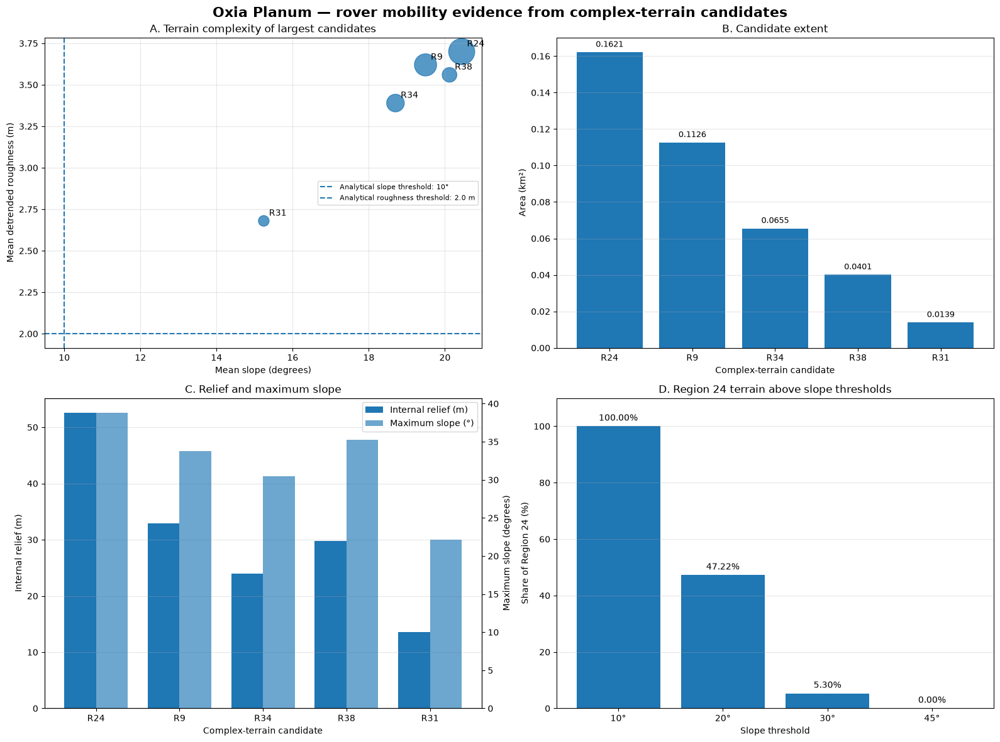


NEXT MEASUREMENTS REQUIRED
1. Build a local slope and roughness map around each candidate, including approach corridors rather than only the complex core.
2. Use higher-resolution CTX/CaSSIS images to inspect obstacle fields, surface texture and potential drill-pad locations.
3. Separate traversable access routes from scientifically interesting but operationally inaccessible outcrops.
4. Compare geological-boundary science value with the route, slope, roughness and uncertainty cost of reaching that boundary.
5. Keep an explicit 'unknown at DEM resolution' category instead of treating unresolved terrain as safe.


In [4]:
# ============================================================
# ROVER ENGINEERING / MOBILITY — OXIA PLANUM
# Terrain complexity, route implications and drill-site access
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Mission context — sourced ESA facts
# ------------------------------------------------------------
#
# Rosalind Franklin:
# - has six independently driven and steered wheels;
# - can use wheel-walking, useful in soft non-cohesive soil;
# - uses stereo navigation, attitude sensing and collision avoidance;
# - has a drill with a maximum vertical reach of 2 m;
# - is designed to travel approximately 100 m per sol.
#
# Sources:
# https://www.esa.int/Science_Exploration/Human_and_Robotic_Exploration/Exploration/ExoMars/Moving_on_Mars
# https://explorationscience.esa.int/project/exomars-rosalind-franklin-rfm/
#
# IMPORTANT:
# The thresholds below are OUR analytical terrain criteria.
# They are NOT official ESA traversability limits.

# ------------------------------------------------------------
# 2. Validated project inputs
# ------------------------------------------------------------

resolution_dem_m = 20.234

# Complex-terrain analytical criterion used in this project
seuil_pente_deg = 10.0
seuil_rugosite_m = 2.0

# Region 24 measured results
region24 = {
    "region": 24,
    "area_km2": 0.1621,
    "mean_slope_deg": 20.44,
    "median_slope_deg": 19.64,
    "max_slope_deg": 38.80,
    "mean_roughness_m": 3.70,
    "p95_roughness_m": 5.74,
    "relief_m": 52.57,
    "geological_units": 7,
}

# Five largest complex-terrain candidates already measured
candidats = [
    {"region": 24, "area_km2": 0.1621, "mean_slope_deg": 20.44,
     "max_slope_deg": 38.80, "mean_roughness_m": 3.70,
     "relief_m": 52.57, "geological_units": 7},

    {"region": 9, "area_km2": 0.1126, "mean_slope_deg": 19.49,
     "max_slope_deg": 33.81, "mean_roughness_m": 3.62,
     "relief_m": 32.90, "geological_units": 0},

    {"region": 34, "area_km2": 0.0655, "mean_slope_deg": 18.70,
     "max_slope_deg": 30.49, "mean_roughness_m": 3.39,
     "relief_m": 23.95, "geological_units": 3},

    {"region": 38, "area_km2": 0.0401, "mean_slope_deg": 20.12,
     "max_slope_deg": 35.29, "mean_roughness_m": 3.56,
     "relief_m": 29.80, "geological_units": 3},

    {"region": 31, "area_km2": 0.0139, "mean_slope_deg": 15.24,
     "max_slope_deg": 22.13, "mean_roughness_m": 2.68,
     "relief_m": 13.62, "geological_units": 3},
]

# Exact Region 24 slope thresholds already measured
slope_thresholds = np.array([10, 20, 30, 45])
region24_coverage = np.array([100.00, 47.22, 5.30, 0.00])

# ------------------------------------------------------------
# 3. Engineering interpretation table
# ------------------------------------------------------------

print("=" * 82)
print("ROVER ENGINEERING / MOBILITY — OXIA PLANUM")
print("=" * 82)
print(f"DEM resolution: {resolution_dem_m:.3f} m/pixel")
print(
    f"Analytical complex-terrain criterion: slope ≥ {seuil_pente_deg:.0f}° "
    f"and roughness ≥ {seuil_rugosite_m:.1f} m"
)
print("This is an analytical filter, NOT an official ESA mobility limit.")
print()

print("REGION 24 — ENGINEERING-RELEVANT MEASUREMENTS")
print(f"Area: {region24['area_km2']:.4f} km²")
print(f"Mean slope: {region24['mean_slope_deg']:.2f}°")
print(f"Maximum slope: {region24['max_slope_deg']:.2f}°")
print(f"Mean roughness: {region24['mean_roughness_m']:.2f} m")
print(f"P95 roughness: {region24['p95_roughness_m']:.2f} m")
print(f"Internal relief: {region24['relief_m']:.2f} m")
print(f"Mapped geological units crossed: {region24['geological_units']}")
print()

print("ENGINEERING IMPLICATIONS")
print(
    "- Terrain requires local verification before traversal: DEM-scale slopes "
    "cannot resolve wheel-scale hazards."
)
print(
    "- The 20.234 m DEM cannot determine individual rocks, sinkage, local "
    "regolith strength, or drill-pad stability."
)
print(
    "- High slope plus high roughness means route planning should prefer "
    "lower-gradient approaches and use local stereo navigation."
)
print(
    "- A scientifically attractive outcrop is not automatically a viable "
    "drilling site: a stable local stance is required."
)
print(
    "- Geological boundaries may be scientifically useful targets, but each "
    "crossing should be checked for local slope, roughness and obstacle risk."
)
print()

print("ROVER-SPECIFIC MITIGATIONS AVAILABLE IN PRINCIPLE")
print(
    "- Independent steering/driving and wheel-walking may help in soft or "
    "challenging terrain, but do not remove the need for terrain assessment."
)
print(
    "- Stereo cameras, attitude sensing and slip-aware navigation support "
    "local route selection and hazard avoidance."
)
print(
    "- WISDOM and imaging can help target selection and drilling strategy, "
    "but they do not replace mechanical stability checks at the drill site."
)

# ------------------------------------------------------------
# 4. Figures
# ------------------------------------------------------------

regions = [f"R{c['region']}" for c in candidats]
areas = np.array([c["area_km2"] for c in candidats])
mean_slopes = np.array([c["mean_slope_deg"] for c in candidats])
max_slopes = np.array([c["max_slope_deg"] for c in candidats])
roughness = np.array([c["mean_roughness_m"] for c in candidats])
reliefs = np.array([c["relief_m"] for c in candidats])
units = np.array([c["geological_units"] for c in candidats])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    "Oxia Planum — rover mobility evidence from complex-terrain candidates",
    fontsize=16,
    fontweight="bold"
)

# A. Mean slope vs roughness
ax = axes[0, 0]

marker_sizes = 5000 * areas + 80

scatter = ax.scatter(
    mean_slopes,
    roughness,
    s=marker_sizes,
    alpha=0.75
)

ax.axvline(
    seuil_pente_deg,
    linestyle="--",
    linewidth=1.5,
    label=f"Analytical slope threshold: {seuil_pente_deg:.0f}°"
)

ax.axhline(
    seuil_rugosite_m,
    linestyle="--",
    linewidth=1.5,
    label=f"Analytical roughness threshold: {seuil_rugosite_m:.1f} m"
)

for i, region in enumerate(regions):
    ax.annotate(
        region,
        (mean_slopes[i], roughness[i]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10
    )

ax.set_title("A. Terrain complexity of largest candidates")
ax.set_xlabel("Mean slope (degrees)")
ax.set_ylabel("Mean detrended roughness (m)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# B. Candidate areas
ax = axes[0, 1]

bars = ax.bar(regions, areas)

for bar, area in zip(bars, areas):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        area + 0.003,
        f"{area:.4f}",
        ha="center",
        fontsize=9
    )

ax.set_title("B. Candidate extent")
ax.set_xlabel("Complex-terrain candidate")
ax.set_ylabel("Area (km²)")
ax.grid(axis="y", alpha=0.3)

# C. Relief and maximum slope
ax = axes[1, 0]

x = np.arange(len(regions))
width = 0.38

bars_relief = ax.bar(
    x - width / 2,
    reliefs,
    width,
    label="Internal relief (m)"
)

ax.set_ylabel("Internal relief (m)")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_xlabel("Complex-terrain candidate")
ax.set_title("C. Relief and maximum slope")

ax2 = ax.twinx()

bars_slope = ax2.bar(
    x + width / 2,
    max_slopes,
    width,
    alpha=0.65,
    label="Maximum slope (°)"
)

ax2.set_ylabel("Maximum slope (degrees)")
ax.grid(axis="y", alpha=0.3)

ax.legend(
    [bars_relief, bars_slope],
    ["Internal relief (m)", "Maximum slope (°)"],
    loc="upper right"
)

# D. Region 24 slope coverage
ax = axes[1, 1]

bars = ax.bar(
    slope_thresholds.astype(str) + "°",
    region24_coverage
)

for bar, value in zip(bars, region24_coverage):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

ax.set_title("D. Region 24 terrain above slope thresholds")
ax.set_xlabel("Slope threshold")
ax.set_ylabel("Share of Region 24 (%)")
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Required next measurements before a mobility conclusion
# ------------------------------------------------------------

print("\nNEXT MEASUREMENTS REQUIRED")
print(
    "1. Build a local slope and roughness map around each candidate, including "
    "approach corridors rather than only the complex core."
)
print(
    "2. Use higher-resolution CTX/CaSSIS images to inspect obstacle fields, "
    "surface texture and potential drill-pad locations."
)
print(
    "3. Separate traversable access routes from scientifically interesting "
    "but operationally inaccessible outcrops."
)
print(
    "4. Compare geological-boundary science value with the route, slope, "
    "roughness and uncertainty cost of reaching that boundary."
)
print(
    "5. Keep an explicit 'unknown at DEM resolution' category instead of "
    "treating unresolved terrain as safe."
)

GÉOLOGIE ET MINÉRALOGIE — RÉGION 24
Surface de Région 24 : 0.16210 km²
Surface couverte par les intersections : 0.16164 km²
Différence : 0.00046 km²

INTERPRÉTATION DE LA DIFFÉRENCE DE SURFACE
- La différence est faible et compatible avec une tolérance de rasterisation ou de géométrie.
- Elle ne doit pas être masquée : elle doit être signalée dans la méthodologie finale.

UNITÉS GÉOLOGIQUES INTERSECTÉES
uBu3  |  36.67% | 0.05945 km² | Upper bedrock unit 3
lBu1  |  31.16% | 0.05052 km² | Lower bedrock unit 1
uBu2  |  19.02% | 0.03084 km² | Upper bedrock unit 2
iDm   |   5.56% | 0.00901 km² | Interbedded dark material
rCm   |   4.77% | 0.00774 km² | Recent crater material
rMm   |   2.47% | 0.00400 km² | Ridge mound material
uBu1  |   0.05% | 0.00008 km² | Upper bedrock unit 1

PROXIMITÉ DES FRONTIÈRES GÉOLOGIQUES
Distance minimale : 0.09 m
Distance moyenne : 63.31 m
Distance médiane : 37.87 m
À moins de  20 m d'une frontière :  30.05%
À moins de  50 m d'une frontière :  62.37%
À moins de

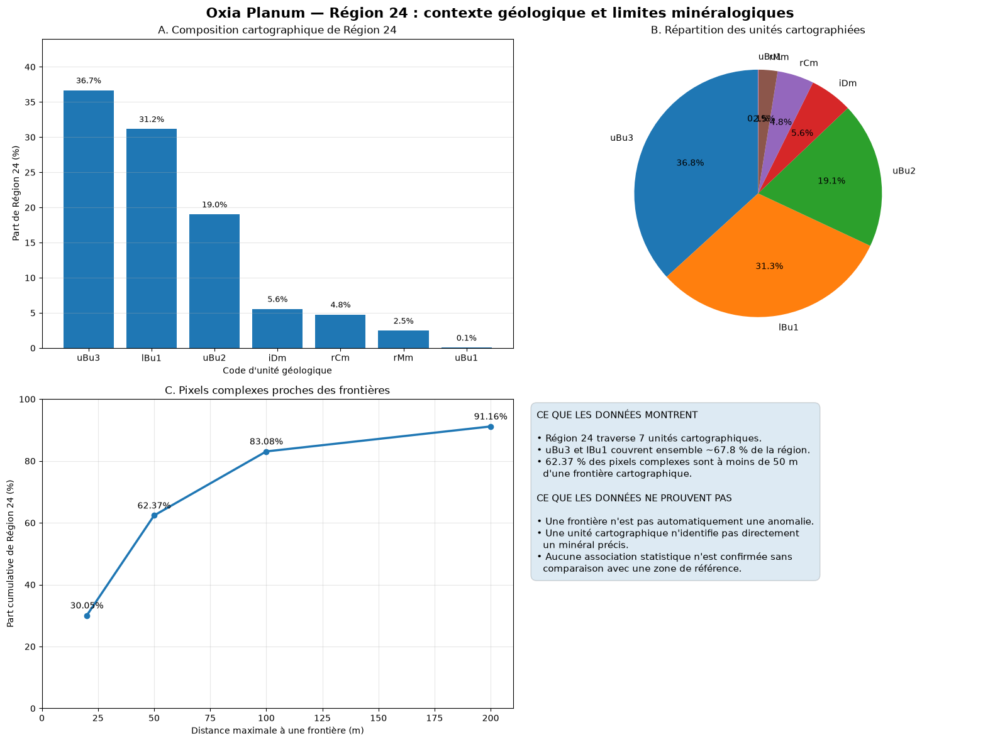


CONCLUSION GÉOLOGIQUE PROVISOIRE
- Région 24 se situe dans un contexte géologique diversifié, dominé par uBu3 et lBu1.
- Sa proximité avec des frontières cartographiques est une piste d'analyse, pas une découverte.
- La prochaine étape est un test de référence : comparer la proximité aux frontières de Région 24 avec celle de toute la zone cartographiée.

PROCHAINE ÉTAPE MINÉRALOGIQUE
1. Ajouter ou localiser les données spectrales disponibles (CaSSIS, CRISM, OMEGA ou produits équivalents).
2. Vérifier quelles signatures minéralogiques sont mesurées, plutôt que déduites des noms des unités.
3. Comparer les signatures près des frontières avec les zones éloignées des frontières.
4. Distinguer clairement : carte géologique, observation spectrale, interprétation et hypothèse.


In [5]:
# ============================================================
# GÉOLOGIE ET MINÉRALOGIE — RÉGION 24
# Diversité des unités, proximité des frontières et limites
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# IMPORTANT :
# Les données ci-dessous proviennent des intersections déjà calculées
# entre la Région 24 et la carte géologique.
#
# Une unité cartographique n'est PAS une mesure minéralogique directe.
# Ne pas attribuer de minéraux précis sans données spectrales ou analyses
# indépendantes.

# ------------------------------------------------------------
# 1. Données géologiques déjà mesurées
# ------------------------------------------------------------

surface_region24_km2 = 0.1621
surface_intersections_km2 = 0.16164

unites_region24 = [
    {
        "code": "uBu1",
        "nom": "Upper bedrock unit 1",
        "surface_km2": 0.00008,
        "pourcentage": 0.05
    },
    {
        "code": "uBu3",
        "nom": "Upper bedrock unit 3",
        "surface_km2": 0.05945,
        "pourcentage": 36.67
    },
    {
        "code": "rMm",
        "nom": "Ridge mound material",
        "surface_km2": 0.00400,
        "pourcentage": 2.47
    },
    {
        "code": "lBu1",
        "nom": "Lower bedrock unit 1",
        "surface_km2": 0.05052,
        "pourcentage": 31.16
    },
    {
        "code": "rCm",
        "nom": "Recent crater material",
        "surface_km2": 0.00774,
        "pourcentage": 4.77
    },
    {
        "code": "uBu2",
        "nom": "Upper bedrock unit 2",
        "surface_km2": 0.03084,
        "pourcentage": 19.02
    },
    {
        "code": "iDm",
        "nom": "Interbedded dark material",
        "surface_km2": 0.00901,
        "pourcentage": 5.56
    },
]

# Distances déjà calculées entre les pixels complexes de Région 24
# et les frontières de la carte géologique.
distances_seuils_m = np.array([20, 50, 100, 200])
proportions_frontieres = np.array([30.05, 62.37, 83.08, 91.16])

distance_min_m = 0.09
distance_moyenne_m = 63.31
distance_mediane_m = 37.87

# ------------------------------------------------------------
# 2. Contrôles de cohérence
# ------------------------------------------------------------

difference_surface = surface_region24_km2 - surface_intersections_km2

print("=" * 80)
print("GÉOLOGIE ET MINÉRALOGIE — RÉGION 24")
print("=" * 80)
print(f"Surface de Région 24 : {surface_region24_km2:.5f} km²")
print(f"Surface couverte par les intersections : {surface_intersections_km2:.5f} km²")
print(f"Différence : {difference_surface:.5f} km²")
print()

print("INTERPRÉTATION DE LA DIFFÉRENCE DE SURFACE")
print(
    "- La différence est faible et compatible avec une tolérance de "
    "rasterisation ou de géométrie."
)
print(
    "- Elle ne doit pas être masquée : elle doit être signalée dans "
    "la méthodologie finale."
)
print()

print("UNITÉS GÉOLOGIQUES INTERSECTÉES")
for unite in sorted(
    unites_region24,
    key=lambda x: x["pourcentage"],
    reverse=True
):
    print(
        f"{unite['code']:5s} | "
        f"{unite['pourcentage']:6.2f}% | "
        f"{unite['surface_km2']:.5f} km² | "
        f"{unite['nom']}"
    )

print()
print("PROXIMITÉ DES FRONTIÈRES GÉOLOGIQUES")
print(f"Distance minimale : {distance_min_m:.2f} m")
print(f"Distance moyenne : {distance_moyenne_m:.2f} m")
print(f"Distance médiane : {distance_mediane_m:.2f} m")

for seuil, proportion in zip(distances_seuils_m, proportions_frontieres):
    print(
        f"À moins de {seuil:3d} m d'une frontière : "
        f"{proportion:6.2f}%"
    )

# ------------------------------------------------------------
# 3. Figures
# ------------------------------------------------------------

codes = [u["code"] for u in unites_region24]
pourcentages = np.array([u["pourcentage"] for u in unites_region24])
surfaces = np.array([u["surface_km2"] for u in unites_region24])

ordre = np.argsort(pourcentages)[::-1]

codes_ordonnes = np.array(codes)[ordre]
pourcentages_ordonnes = pourcentages[ordre]
surfaces_ordonnes = surfaces[ordre]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    "Oxia Planum — Région 24 : contexte géologique et limites minéralogiques",
    fontsize=16,
    fontweight="bold"
)

# A. Part des unités géologiques
ax = axes[0, 0]

bars = ax.bar(codes_ordonnes, pourcentages_ordonnes)

for bar, valeur in zip(bars, pourcentages_ordonnes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valeur + 1,
        f"{valeur:.1f}%",
        ha="center",
        fontsize=9
    )

ax.set_title("A. Composition cartographique de Région 24")
ax.set_xlabel("Code d'unité géologique")
ax.set_ylabel("Part de Région 24 (%)")
ax.set_ylim(0, max(pourcentages_ordonnes) * 1.2)
ax.grid(axis="y", alpha=0.3)

# B. Répartition surfacique
ax = axes[0, 1]

ax.pie(
    pourcentages_ordonnes,
    labels=codes_ordonnes,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title("B. Répartition des unités cartographiées")

# C. Proximité cumulative des frontières
ax = axes[1, 0]

ax.plot(
    distances_seuils_m,
    proportions_frontieres,
    marker="o",
    linewidth=2.5
)

for distance, proportion in zip(
    distances_seuils_m,
    proportions_frontieres
):
    ax.annotate(
        f"{proportion:.2f}%",
        (distance, proportion),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

ax.set_title("C. Pixels complexes proches des frontières")
ax.set_xlabel("Distance maximale à une frontière (m)")
ax.set_ylabel("Part cumulative de Région 24 (%)")
ax.set_xlim(0, 210)
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

# D. Ce que les données permettent — et ne permettent pas
ax = axes[1, 1]
ax.axis("off")

texte = (
    "CE QUE LES DONNÉES MONTRENT\n\n"
    "• Région 24 traverse 7 unités cartographiques.\n"
    "• uBu3 et lBu1 couvrent ensemble ~67.8 % de la région.\n"
    "• 62.37 % des pixels complexes sont à moins de 50 m\n"
    "  d'une frontière cartographique.\n\n"
    "CE QUE LES DONNÉES NE PROUVENT PAS\n\n"
    "• Une frontière n'est pas automatiquement une anomalie.\n"
    "• Une unité cartographique n'identifie pas directement\n"
    "  un minéral précis.\n"
    "• Aucune association statistique n'est confirmée sans\n"
    "  comparaison avec une zone de référence."
)

ax.text(
    0.03,
    0.97,
    texte,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.6", alpha=0.15)
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Conclusion honnête et suite minéralogique
# ------------------------------------------------------------

print("\nCONCLUSION GÉOLOGIQUE PROVISOIRE")
print(
    "- Région 24 se situe dans un contexte géologique diversifié, "
    "dominé par uBu3 et lBu1."
)
print(
    "- Sa proximité avec des frontières cartographiques est une piste "
    "d'analyse, pas une découverte."
)
print(
    "- La prochaine étape est un test de référence : comparer la proximité "
    "aux frontières de Région 24 avec celle de toute la zone cartographiée."
)

print("\nPROCHAINE ÉTAPE MINÉRALOGIQUE")
print(
    "1. Ajouter ou localiser les données spectrales disponibles "
    "(CaSSIS, CRISM, OMEGA ou produits équivalents)."
)
print(
    "2. Vérifier quelles signatures minéralogiques sont mesurées, "
    "plutôt que déduites des noms des unités."
)
print(
    "3. Comparer les signatures près des frontières avec les zones "
    "éloignées des frontières."
)
print(
    "4. Distinguer clairement : carte géologique, observation spectrale, "
    "interprétation et hypothèse."
)

SYSTÈMES SPATIAUX ET OPÉRATIONS — ROSALIND FRANKLIN

PARAMÈTRES DE MISSION
Durée nominale conçue : 218 sols
Traversée nominale typique : 2.0 km
Avance de référence : ~100 m/sol
Opportunités de communication : au moins 2 par sol
Profondeur maximale du forage : 2.0 m

LECTURE DE PLANIFICATION
Avance moyenne nécessaire pour couvrir 2 km en 218 sols : 9.17 m/sol
Minimum théorique à 100 m/sol uniquement : 20.0 sols
Opportunités de communication sur 218 sols : au moins 436

INTERPRÉTATION
- Une avance moyenne de 9.17 m/sol ne signifie pas que le rover roulera chaque jour seulement 9.17 m.
- La durée nominale comprend la navigation, la planification, les observations, les communications, le forage et les analyses.
- Les zones complexes comme Région 24 peuvent coûter davantage de temps que les zones lisses, même si elles sont courtes en distance.
- Une cible scientifique ne doit pas seulement être atteignable : elle doit être accessible avec une position stable pour les observations et le fora

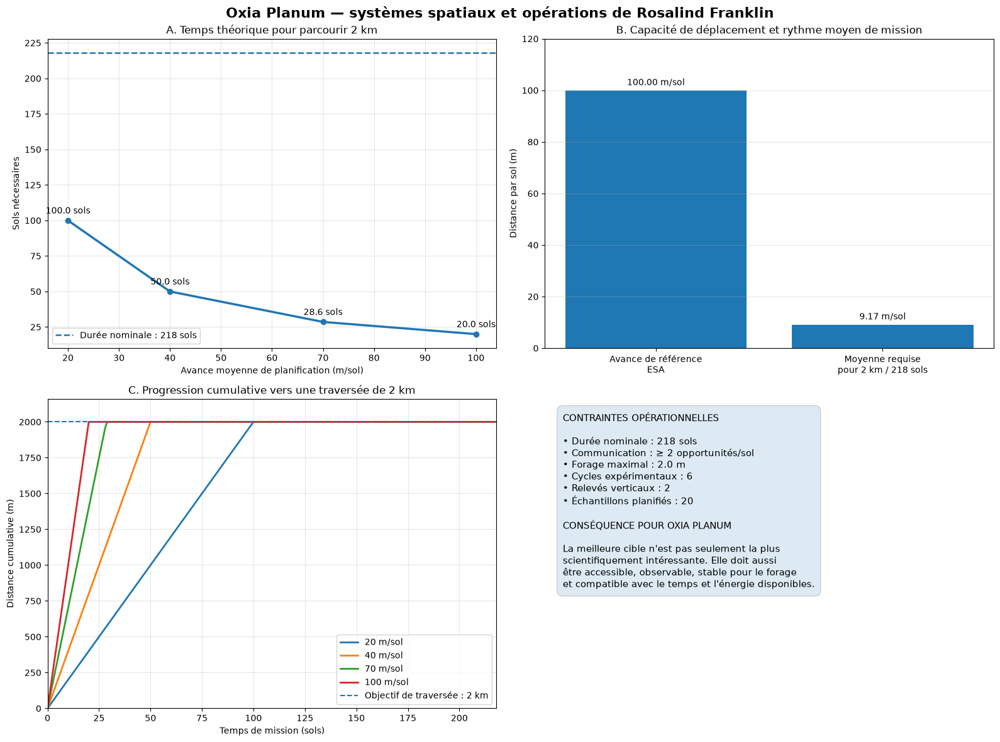


LIEN AVEC RÉGION 24
- Région 24 est petite en surface, mais son relief, sa pente et sa rugosité peuvent augmenter le coût opérationnel de son accès.
- Une approche progressive, guidée par la navigation stéréo et l'observation locale, serait plus réaliste qu'une traversée directe.
- Avant de forer, il faut distinguer une zone géologiquement intéressante d'une zone réellement stable pour la position du rover et du forage.
- La future analyse des compromis comparera explicitement : valeur scientifique, accessibilité, risque, temps, énergie et incertitude.


In [6]:
# ============================================================
# SYSTÈMES SPATIAUX ET OPÉRATIONS — ROSALIND FRANKLIN
# Contraintes de mission, mobilité, communications et forage
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Sources ESA
# ------------------------------------------------------------
#
# https://explorationscience.esa.int/project/exomars-rosalind-franklin-rfm/
#
# Informations utilisées :
# - durée nominale conçue : 218 sols ;
# - environ 100 m de déplacement sûr par sol ;
# - au moins deux opportunités de communication via TGO par sol ;
# - traversée nominale typique : environ 2 km ;
# - alimentation électrique par panneaux solaires ;
# - survie nocturne avec batteries et unités de chauffage radioisotopiques ;
# - forage vertical maximal : 2 m ;
# - six cycles expérimentaux et deux relevés verticaux prévus.
#
# Les calculs ci-dessous sont des scénarios de planification.
# Ils ne constituent pas un calendrier officiel de mission.

# ------------------------------------------------------------
# 1. Paramètres de mission
# ------------------------------------------------------------

duree_nominale_sols = 218
distance_traversee_m = 2000
avance_reference_m_sol = 100
opportunites_communication_sol = 2
profondeur_forage_max_m = 2

cycles_experimentaux = 6
releves_verticaux = 2
echantillons_planifies = 20

# ------------------------------------------------------------
# 2. Calculs de planification
# ------------------------------------------------------------

avance_moyenne_requise = (
    distance_traversee_m / duree_nominale_sols
)

sols_minimum_theoriques_conduite = (
    distance_traversee_m / avance_reference_m_sol
)

opportunites_communication_nominales = (
    duree_nominale_sols * opportunites_communication_sol
)

print("=" * 82)
print("SYSTÈMES SPATIAUX ET OPÉRATIONS — ROSALIND FRANKLIN")
print("=" * 82)

print("\nPARAMÈTRES DE MISSION")
print(f"Durée nominale conçue : {duree_nominale_sols} sols")
print(f"Traversée nominale typique : {distance_traversee_m / 1000:.1f} km")
print(f"Avance de référence : ~{avance_reference_m_sol:.0f} m/sol")
print(
    f"Opportunités de communication : "
    f"au moins {opportunites_communication_sol} par sol"
)
print(f"Profondeur maximale du forage : {profondeur_forage_max_m:.1f} m")

print("\nLECTURE DE PLANIFICATION")
print(
    f"Avance moyenne nécessaire pour couvrir 2 km en {duree_nominale_sols} sols : "
    f"{avance_moyenne_requise:.2f} m/sol"
)
print(
    f"Minimum théorique à {avance_reference_m_sol:.0f} m/sol uniquement : "
    f"{sols_minimum_theoriques_conduite:.1f} sols"
)
print(
    f"Opportunités de communication sur {duree_nominale_sols} sols : "
    f"au moins {opportunites_communication_nominales}"
)

print("\nINTERPRÉTATION")
print(
    "- Une avance moyenne de 9.17 m/sol ne signifie pas que le rover "
    "roulera chaque jour seulement 9.17 m."
)
print(
    "- La durée nominale comprend la navigation, la planification, "
    "les observations, les communications, le forage et les analyses."
)
print(
    "- Les zones complexes comme Région 24 peuvent coûter davantage de temps "
    "que les zones lisses, même si elles sont courtes en distance."
)
print(
    "- Une cible scientifique ne doit pas seulement être atteignable : "
    "elle doit être accessible avec une position stable pour les observations "
    "et le forage."
)

# ------------------------------------------------------------
# 3. Scénarios de vitesse moyenne de planification
# ------------------------------------------------------------

vitesses_scenarios = np.array([20, 40, 70, 100])

sols_pour_2km = (
    distance_traversee_m / vitesses_scenarios
)

print("\nSCÉNARIOS DE PLANIFICATION — 2 km")
print("Avance moyenne | Sols nécessaires si cette moyenne est maintenue")
print("-" * 82)

for vitesse, sols in zip(vitesses_scenarios, sols_pour_2km):
    print(f"{vitesse:5.0f} m/sol      | {sols:6.1f} sols")

# ------------------------------------------------------------
# 4. Figures
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    "Oxia Planum — systèmes spatiaux et opérations de Rosalind Franklin",
    fontsize=16,
    fontweight="bold"
)

# A. Durée de traversée selon la vitesse moyenne
ax = axes[0, 0]

ax.plot(
    vitesses_scenarios,
    sols_pour_2km,
    marker="o",
    linewidth=2.5
)

ax.axhline(
    duree_nominale_sols,
    linestyle="--",
    linewidth=1.8,
    label=f"Durée nominale : {duree_nominale_sols} sols"
)

for vitesse, sols in zip(vitesses_scenarios, sols_pour_2km):
    ax.annotate(
        f"{sols:.1f} sols",
        (vitesse, sols),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

ax.set_title("A. Temps théorique pour parcourir 2 km")
ax.set_xlabel("Avance moyenne de planification (m/sol)")
ax.set_ylabel("Sols nécessaires")
ax.grid(alpha=0.3)
ax.legend()

# B. Avance de référence vs moyenne de mission
ax = axes[0, 1]

categories = [
    "Avance de référence\nESA",
    "Moyenne requise\npour 2 km / 218 sols"
]

valeurs = [
    avance_reference_m_sol,
    avance_moyenne_requise
]

bars = ax.bar(categories, valeurs)

for bar, valeur in zip(bars, valeurs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valeur + 2,
        f"{valeur:.2f} m/sol",
        ha="center",
        fontsize=10
    )

ax.set_title("B. Capacité de déplacement et rythme moyen de mission")
ax.set_ylabel("Distance par sol (m)")
ax.set_ylim(0, 120)
ax.grid(axis="y", alpha=0.3)

# C. Distance cumulative selon plusieurs scénarios
ax = axes[1, 0]

sols = np.arange(0, duree_nominale_sols + 1)

for vitesse in vitesses_scenarios:
    distance_cumulative = np.minimum(
        vitesse * sols,
        distance_traversee_m
    )

    ax.plot(
        sols,
        distance_cumulative,
        linewidth=2,
        label=f"{vitesse:.0f} m/sol"
    )

ax.axhline(
    distance_traversee_m,
    linestyle="--",
    linewidth=1.5,
    label="Objectif de traversée : 2 km"
)

ax.set_title("C. Progression cumulative vers une traversée de 2 km")
ax.set_xlabel("Temps de mission (sols)")
ax.set_ylabel("Distance cumulative (m)")
ax.set_xlim(0, duree_nominale_sols)
ax.set_ylim(0, distance_traversee_m * 1.08)
ax.grid(alpha=0.3)
ax.legend()

# D. Structure opérationnelle de mission
ax = axes[1, 1]
ax.axis("off")

texte = (
    "CONTRAINTES OPÉRATIONNELLES\n\n"
    f"• Durée nominale : {duree_nominale_sols} sols\n"
    f"• Communication : ≥ {opportunites_communication_sol} opportunités/sol\n"
    f"• Forage maximal : {profondeur_forage_max_m:.1f} m\n"
    f"• Cycles expérimentaux : {cycles_experimentaux}\n"
    f"• Relevés verticaux : {releves_verticaux}\n"
    f"• Échantillons planifiés : {echantillons_planifies}\n\n"
    "CONSÉQUENCE POUR OXIA PLANUM\n\n"
    "La meilleure cible n'est pas seulement la plus\n"
    "scientifiquement intéressante. Elle doit aussi\n"
    "être accessible, observable, stable pour le forage\n"
    "et compatible avec le temps et l'énergie disponibles."
)

ax.text(
    0.04,
    0.96,
    texte,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.6", alpha=0.15)
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Lien avec Région 24
# ------------------------------------------------------------

print("\nLIEN AVEC RÉGION 24")
print(
    "- Région 24 est petite en surface, mais son relief, sa pente et sa "
    "rugosité peuvent augmenter le coût opérationnel de son accès."
)
print(
    "- Une approche progressive, guidée par la navigation stéréo et "
    "l'observation locale, serait plus réaliste qu'une traversée directe."
)
print(
    "- Avant de forer, il faut distinguer une zone géologiquement intéressante "
    "d'une zone réellement stable pour la position du rover et du forage."
)
print(
    "- La future analyse des compromis comparera explicitement : "
    "valeur scientifique, accessibilité, risque, temps, énergie et incertitude."
)

In [7]:
import numpy as np
import pandas as pd

# 1. Physical Constants & Gravitational Environment
G = 6.67430e-11          # Gravitational constant (m^3 kg^-1 s^-2)
M_mars = 6.4171e23       # Mass of Mars (kg)
R_mars = 3389.5e3        # Volumetric mean radius of Mars (m)
m_rover = 310.0          # Rosalind Franklin rover operational mass (kg)
g_earth = 9.80665        # Earth gravity (m/s^2)

# Compute exact Mars surface gravity
g_mars = (G * M_mars) / (R_mars ** 2)
print(f"Calculated Mars Gravity (g_mars): {g_mars:.4f} m/s^2")

# Static Normal Weights
w_earth = m_rover * g_earth
w_mars = m_rover * g_mars
print(f"Earth Weight: {w_earth:.2f} N | Mars Weight: {w_mars:.2f} N\n")

# 2. Slope Force Decomposition & Traction Analysis Across Topographic Regimes
slope_data = [
    {"Regime": "DEM Mean Slope", "Angle_deg": 2.665},
    {"Regime": "Analytical Threshold", "Angle_deg": 10.000},
    {"Regime": "Region 24 Mean", "Angle_deg": 20.440},
    {"Regime": "Region 24 Peak", "Angle_deg": 38.800},
    {"Regime": "DEM Max Outlier", "Angle_deg": 65.962}
]

results_slopes = []
for item in slope_data:
    theta_rad = np.radians(item["Angle_deg"])
    f_parallel = m_rover * g_mars * np.sin(theta_rad)
    f_perpendicular = m_rover * g_mars * np.cos(theta_rad)
    mu_req = np.tan(theta_rad)
    results_slopes.append({
        "Regime": item["Regime"],
        "Angle (deg)": item["Angle_deg"],
        "F_parallel (N)": round(f_parallel, 2),
        "F_perpendicular (N)": round(f_perpendicular, 2),
        "Mu_required": round(mu_req, 4)
    })

df_slopes = pd.DataFrame(results_slopes)
print("--- Slope Force & Traction Analysis ---")
print(df_slopes.to_string(index=False))
print("\n" + "="*60 + "\n")

# 3. Gravitational Potential Energy & Work Requirements
region_data = [
    {"Region": "Region 24", "Relief_h_m": 52.57},
    {"Region": "Region 9", "Relief_h_m": 32.90},
    {"Region": "Region 34", "Relief_h_m": 23.95},
    {"Region": "Region 38", "Relief_h_m": 29.80},
    {"Region": "Region 31", "Relief_h_m": 13.62}
]

results_energy = []
for item in region_data:
    delta_u_j = m_rover * g_mars * item["Relief_h_m"]
    delta_u_wh = delta_u_j / 3600.0
    results_energy.append({
        "Region": item["Region"],
        "Relief (m)": item["Relief_h_m"],
        "Potential Energy (kJ)": round(delta_u_j / 1000.0, 2),
        "Ideal Mechanical Work (Wh)": round(delta_u_wh, 2)
    })

df_energy = pd.DataFrame(results_energy)
print("--- Gravitational Potential Energy & Work ---")
print(df_energy.to_string(index=False))

Calculated Mars Gravity (g_mars): 3.7280 m/s^2
Earth Weight: 3040.06 N | Mars Weight: 1155.67 N

--- Slope Force & Traction Analysis ---
              Regime  Angle (deg)  F_parallel (N)  F_perpendicular (N)  Mu_required
      DEM Mean Slope        2.665           53.73              1154.42       0.0465
Analytical Threshold       10.000          200.68              1138.12       0.1763
      Region 24 Mean       20.440          403.59              1082.91       0.3727
      Region 24 Peak       38.800          724.15               900.66       0.8040
     DEM Max Outlier       65.962         1055.45               470.75       2.2420


--- Gravitational Potential Energy & Work ---
   Region  Relief (m)  Potential Energy (kJ)  Ideal Mechanical Work (Wh)
Region 24       52.57                  60.75                       16.88
 Region 9       32.90                  38.02                       10.56
Region 34       23.95                  27.68                        7.69
Region 38       29.